# Multi-Parameter Photon-by-photon Hidden Markov Modeling

## Please Cite:

Photon by photon hidden Markov modeling was initially developed by:
[Pirchi et. al. Journal of Physical Chemistry B, 2016, 120, 13065-13075](https://doi.org/10.1021/acs.jpcb.6b10726)

[H2MM_C](https://github.com/harripd/H2MMpythonlib) written by Paul David Harris, and can be cited here:
[![DOI](https://zenodo.org/badge/302447110.svg)](https://zenodo.org/badge/latestdoi/302447110)


<b>A <font color="magenta">Magenta Heading</font> indicates that this cell is where some key parameter/threshold is set, for instance minimum burst size etc.  This will allow for quick modification and access to these key values.</b>

<b>A <font color="blue">Blue Heading</font> indicates that the bellow cell contains a useful function definition, which might be useful to copy-paste into other notebooks</b>

## Analysis Steps
1. [Import Modules](#Importing-Necessary-Modules)
2. [Load into FRETBursts](#Load-file-into-FRETBursts)
3. [Background Analysis](#Background-Analysis)
4. [Burst Selection](#Burst-Selections)
    1. [Donor Active](#Donor-Active-burst-selection)
    2. [DCBS (FRET) selection](#FRET-selection-with-Dual-Channel-Burst-Search)
5. [BVA](#Burst-Variance-Analysis-(BVA))
    1. [Donor Active BVA](#Plot-the-BVA-of-the-Donor-Active-selection-(d_da-dbs/g_da))
    2. [DCBS BVA](#Plot-the-BVA-of-the-FRET-burst-selection-(d_fret-ddc/g_dcfret))
6. [H<sup>2</sup>MM](#H2MM-Analysis)
    1. [Donor Active analysis](#Donor-Active-H2MM-analysis)
        1. [spH<sup>2</sup>MM](#1-Parameter-Traditional-H2MM-of-Donor-Active-population)
        2. [mpH<sup>2</sup>MM](#2-Parameter-H2MM-of-Donor-Active-population)
    2. [DCBS analysis](#FRET-H2MM-analysis)
        1. [spH<sup>2</sup>MM](#1-Parameter-Traditional-H2MM-of-FRET-population)
        2. [mpH<sup>2</sup>MM](#2-Parameter-H2MM-of-FRET-population)
7. [Examining Results](#Examining-the-Results)
    1. [Donor Active Results](#Donor-Active-Burst-Selection)
        1. [ES analysis](#Plot-information-relevant-to-2D-E-S-plots-for-Donor-Active-burst-selection)
        2. [Lifetime Analysis](#Donor-Active-Assement-of-Quantum-Yield-through-the-Lifetime-data)
    2. [DCBS Results](#FRET-active-Burst-Selection)
        1. [ES analysis](#Plot-information-relevant-to-2D-E-S-plots-for-DCBS-burst-selection)
        2. [Lifetime Analysis](#DCBS-Assement-of-Quantum-Yield-through-the-Lifetime-data) 
8. [Saving to CSV](#Writing-the-results-to-.csv-file)
9. [E-$\tau$ Analysis](#E-$\tau$-Analysis)

Sections 1-4 are analysis with `pySMFS`, 5 demonstrates how to conduct BVA, and 6 how to use mpH<sup>2</sup>MM. 
All these sections (1-6) are written to be very general, and therefore easily adapted to other datasets. 

Section 7 does not try to be a tutorial, but rather to generate figures for displaying the data. 
These often show multiple pieces of data on top of each other, and involve a number of frames. 
The code is therefore much more specialized, and while someone could probably learn a lot from it, 
the purpose is to make plots to examine the data, not to teach someone how to use ``pySMFS`` or [H2MM_C](https://github.com/harripd/H2MMpythonlib)

<a id='importmodules'></a>
## Importing Necessary Modules

Before the features and functions of a module can be accessed, it must be imported. It is not necessary to import all modules at the beginning of a notebook, just so long as they are imported before they are used.

Genearlly, either all modules are imported in the beginning, or a module is imported right before it is first used. Python will give no error if a module is imported in the middle, but not used for a while, however, this makes for sloppy code, so doing such should be discouraged.

Importing all modules at the beginning has the advantage of letting the user know exaclty what they need from the start, while importing when needed makes a closer connection between the module and it's purpose.

In [1]:
# # standard scientific Python modules
# import time
# begin = time.perf_counter()
# import os
# import numpy as np
# import pandas as pd
# from matplotlib import pyplot as plt
# import matplotlib.gridspec as gridspec
# from matplotlib.lines import Line2D
# from matplotlib.collections import LineCollection
# from matplotlib.colors import ListedColormap
# import seaborn as sns
import time
begin = time.perf_counter()
import os
from itertools import chain, combinations, permutations

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from scipy.stats import gaussian_kde
import seaborn as sns

# FRETBursts and H2MM_C
# from fretbursts import *
# from fretbursts.phtools.phrates import *

import smfbursts as smf
import H2MMbursts as bhm

The `printtime` function is just useful for benchmarking- it finds the difference between two times given by `time.perf_counter` into a human readable hours-minutes-seconds format, the `preamble` kwarg lets us add message in front of the time output (so we can say if this is supposed to be the time for the whole notebook, an optimization etc).

In [2]:
def printtime(beg,fin,preamble=None):
    if preamble is None:
        preamble = ''
    print("%s %dh %dm %.4fs to run"%(preamble,(fin - beg)//3600,(fin - beg)//60,(fin - beg)%60))

In [3]:
sns.set_style('whitegrid')
plt.rcParams['image.cmap'] = "Spectral_r"

## Check that file exists

Now we load the file, you should place the path to the file on your system in the string following filename on the first line

<b><font color="magenta">Select .hdf5 format Data File</font></b>

In [4]:
filename = 'data/HP3_TE300_SPC630.hdf5'

This cell just checks to make sure you have a real file (so the notebook won't proceed if you made a ** gasp ** typo in your filename.

In [5]:
if os.path.isfile(filename):
    print('Perfect, I found the file!')
else:
    raise OSError('ERROR: file does not exist')

Perfect, I found the file!


<b><font color="magenta">Name of the dataset, will be printed in plots later</font></b>

In [6]:
plot_title = 'HP3 300mM NaCl' # main caption to put in the plots to identify the substrate

<b><font color="magenta">Set the minimum threshold for the $BIC'$ to be considered best fit, and set threshold for considering an optimization to have converged</font></b>

In [7]:
bicp_min = 0.005 # the threshold line for BIC', which was superceded by ICL, inlcuded for comparision
conv_min = 1e-7

Now that we have confirmed that you have the right filename, we can now load that file into the FRETbursts library, simply as the object `d`

<a id='loaddata'></a>
## Load file into FRETBursts

In [8]:
# d = loader.photon_hdf5(filename)
raw = smf.photonHDF5.load(filename)

Now let's see some basic statistics on our data:
first, the length of the observation (in seconds):

In [9]:
# d.time_max
raw.times[-1][-1]

np.int64(100187059037)

Now lets see the alternation histogram- make sure the assignment of donor and acceptor regions are assigned correctly

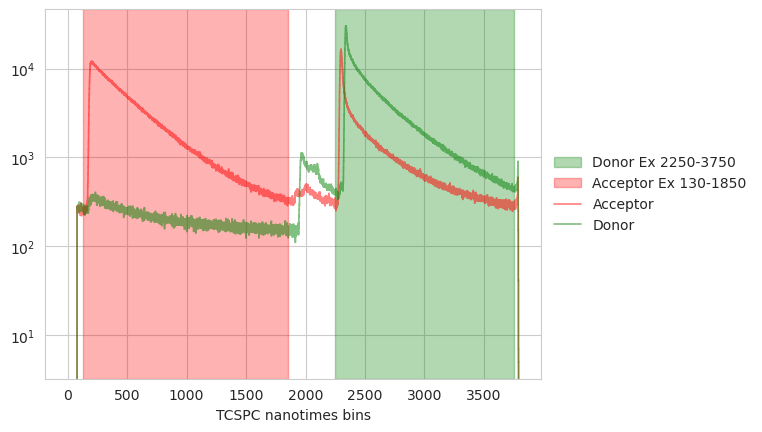

In [10]:
# bpl.plot_alternation_hist(d)
smf.plot.alternation_hist(raw)

Since the alternation histogram looks good, analysis can proceed by applying the ALEX period

In [11]:
# loader.alex_apply_period(d)
data = smf.photonHDF5.regularize_dets(raw)

With photons sorted into their respective streams (D<sub>ex</sub>D<sub>em</sub>, D<sub>ex</sub>A<sub>em</sub>, A<sub>ex</sub>D<sub>em</sub>, A<sub>ex</sub>A<sub>em</sub>) it is good to check if the data is of sufficient quality, a short section timetrace of photon count rate is plotted. Bursts (which appear as spikes in the plot) should be well separated from each other to avoid ensemble averaging. If they are not, the concentration of labeled molecule(s) is too high, and thus should be decreased.

([<matplotlib.lines.Line2D at 0x70d1aa369580>,
 [None, None, None],
 Text(0.5, 0, 'time (s)'),
 Text(0, 0.5, 'cnts'),
 <matplotlib.legend.Legend at 0x70d1b246b350>)

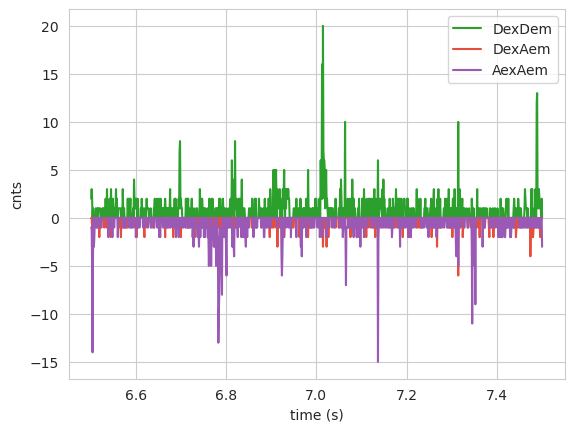

In [12]:
# dplot(d, timetrace)
smf.plot.timetrace(data, labels=smf.fretfactory.ALEXdefaults['stream_labels'][1:],
                   streams=smf.fretfactory.ALEXdefaults['streams'][1:], 
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors'][1:], 
                   direction=[1,-1,-1], tmin=6.5, tmax=7.5)

## Background Analysis

In [13]:
# d.calc_bg(fun=bg.exp_fit,time_s=30, tail_min_us='auto', F_bg=1.7)
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, F_bg=1.7)

Now various plots are presented to make sure there are no problems with the data.

The first is the histogram of the inter-photon delays, which are used to calculated the background.

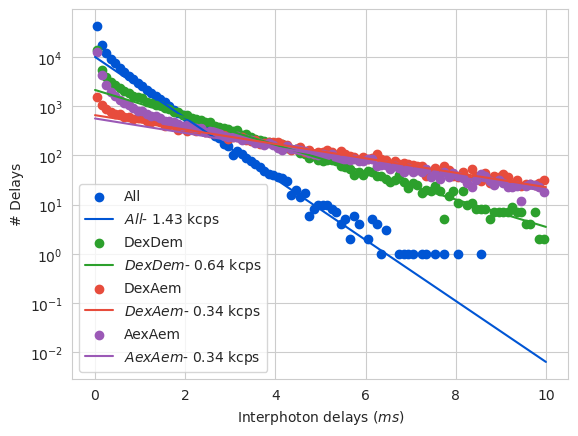

In [14]:
# dplot(d, hist_bg)
smf.plot.hist_interphoton(data, dbg['bg'], streams=smf.fretfactory.ALEXdefaults['streams'], 
                          labels=smf.fretfactory.ALEXdefaults['stream_labels'], 
                          streams_kwargs=smf.fretfactory.ALEXdefaults['stream_colors']);

It is also helpful to see how the background change with time. So the plot of the background rates for all time_s=30 second intervals of the 

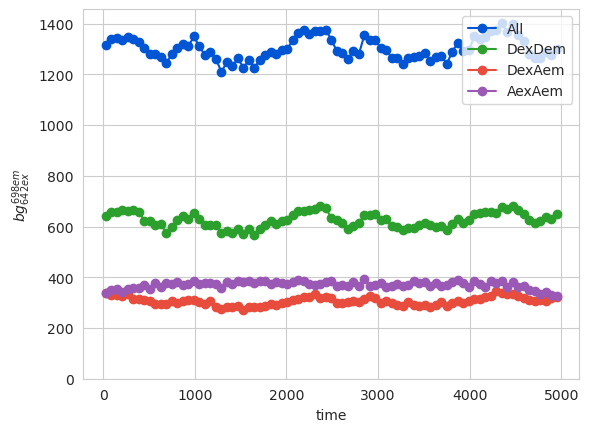

In [15]:
# dplot(d, timetrace_bg)
add_ylabel = True
for col, label, kws in zip((dbg['BgAll'], dbg['BgDD'], dbg['BgDA'], dbg['BgAA']),
                           smf.fretfactory.ALEXdefaults['stream_labels'],
                           smf.fretfactory.ALEXdefaults['stream_colors']):
    smf.plot.time_plot(data, col, marker='o', ylabel=None, label=label, **kws)
    add_ylabel = False
plt.ylim(0.0)
plt.legend();

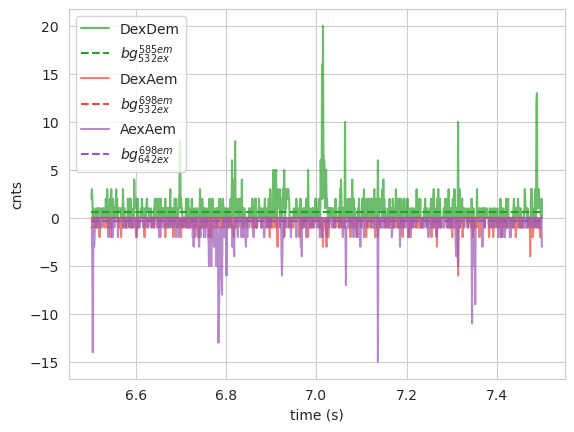

In [16]:
# dplot(d, timetrace)
smf.plot.timetrace(data, labels=smf.fretfactory.ALEXdefaults['stream_labels'][1:], bg=dbg['bg'],
                   bg_kwargs={'linestyle':'--'},
                   streams=smf.fretfactory.ALEXdefaults['streams'][1:], 
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors'][1:], 
                   direction=[1,-1,-1], tmin=6.5, tmax=7.5, alpha=0.7);

The burst search is performed, using the thresholds of m=10 consecutive photons, whose overall count rate is F=6 times higher than the background.

<b><font color="magenta">Size of the sliding window m and rate threshold to consider a burst F</font></b>

In [17]:
# d.burst_search(m=10, F=6)
dbs = smf.fretfactory.make_burst_search(dbg['bg'], m=10, F=6.0)

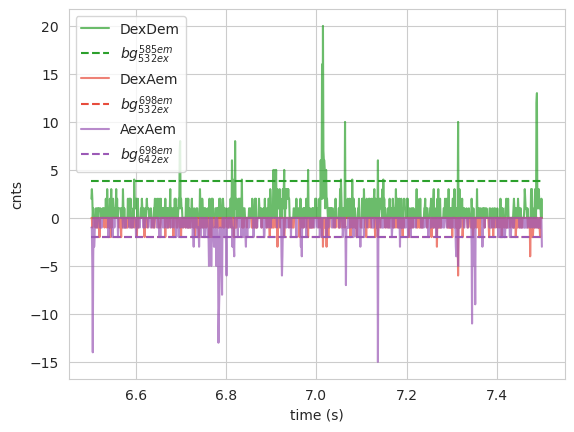

In [18]:
# In addition, the plot.timetrace function supports plotting background thresholds from burst search as well
smf.plot.timetrace(data, labels=smf.fretfactory.ALEXdefaults['stream_labels'][1:], bg=dbs['bursts'],
                   bg_kwargs={'linestyle':'--'},
                   streams=smf.fretfactory.ALEXdefaults['streams'][1:], 
                   stream_kwargs=smf.fretfactory.ALEXdefaults['stream_colors'][1:],
                   direction=[1,-1,-1], tmin=6.5, tmax=7.5, alpha=0.7);

In [19]:
# d.fuse_bursts(ms=0) # performed as part fo make_burst_search

<a id='burstselect'></a>
## Burst Selections
### Donor Active burst selection
Next, bursts are filtered/selected to have a sum of $\geq$ 30 photons in all channels. This d_all includes all bursts, including the Donor Only (DO) and Acceptor Only (AO) bursts, which can be used to calculate the leakage and direct excitation factors respectively.

The uncorrected E-S histogram is then plotted.

$E_{raw} = \frac{n^A_D}{n^A_D + n^D_D}$

$S_{raw} = \frac{n^A_D + n^D_D}{n^A_D + n^D_D + n^A_A}$

[Lee, N. K.; Kapanidis, A. N.; Wang, Y.; Michalet X.; Mukhopadhyay, J.; Ebright R. H.; Weiss, S. 2005. Accurate FRET Measurements within Single Diffusing Biomolecules Using Alternating-Laser Excitation. <i>Biophys J.</i> 88:2939-2953](https://doi.org/10.1529/biophysj.104.054114)

<a id='daburstselect'></a>
<b><font color="magenta">Theshold of bursts for all photons</font></b>

In [20]:
# d_all = Sel(d, select_bursts.size, add_naa=True, th1=50)
g_all = smf.make_geq_gate(dbs['NphActive_bg'], 50)

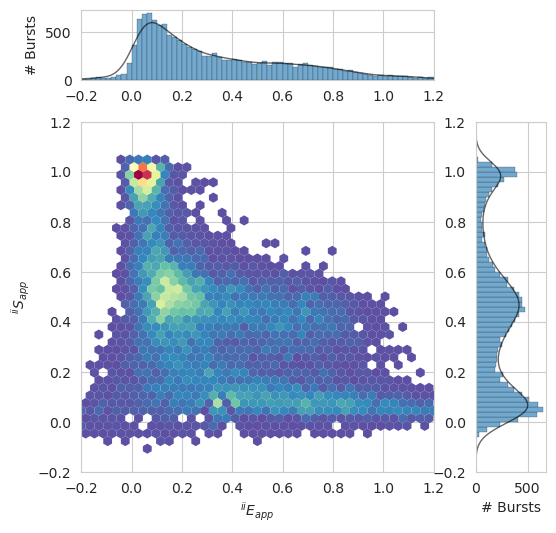

In [21]:
# alex_jointplot(d_all);
fig = plt.figure(figsize=(6,6))
ax, *_ = smf.plot.jointplot(data, dbs['E_bg'], dbs['S_bg'], gate=g_all,
                           cfunc=smf.plot.hexbin, hfunc=smf.plot.hist_kdeoverlay,
                           cplot_kwargs=smf.fretfactory.ALEXdefaults['hexbin'],
                           hplot_kwargs=smf.fretfactory.ALEXdefaults['kdeover', ('bins', 'ratio_bins')],
                           fig=fig)
ax[0].set_xlim([-0.2, 1.2])
ax[0].set_ylim([-0.2, 1.2]);

Now, bursts are selected for the same criterion, but excluding the A<sub>ex</sub>A<sub>em</sub> stream, thus selecting the bursts with an active donor, and are stored in `d_da` (DA for Donor Active)

<b><font color="magenta">Threshold for bursts in D<sub>ex</sub> channels</font></b>

In [22]:
# d_da = Sel(d_all, select_bursts.size, th1=30)
g_da = smf.make_geq_gate(dbs['NphDex_bg'], 30) & g_all

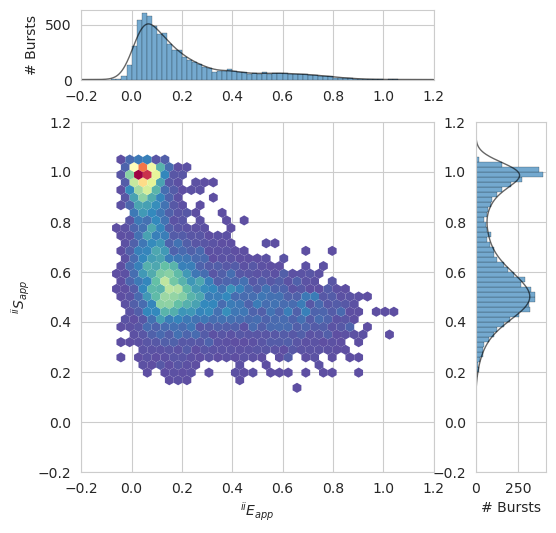

In [23]:
# alex_jointplot(d_da);
fig = plt.figure(figsize=(6,6))
ax, *_ = smf.plot.jointplot(data, dbs['E_bg'], dbs['S_bg'], gate=g_da, fig=fig,
                           cfunc=smf.plot.hexbin, hfunc=smf.plot.hist_kdeoverlay,
                           cplot_kwargs=smf.fretfactory.ALEXdefaults['hexbin'],
                           hplot_kwargs=smf.fretfactory.ALEXdefaults['kdeover', ('bins', 'ratio_bins')])
ax[0].set_xlim([-0.2, 1.2])
ax[0].set_ylim([-0.2, 1.2]);

<a id='fretburstselect'></a>
## FRET selection with Dual Channel Burst Search

There previous burst selection contains a large number of Acceptor inactive bursts. One method for removing these is to set a minimum threshold of A<sub>ex</sub>A<sub>em</sub> photons, or to select bursts only within a certian range of $S_{raw}$.

A third method also exists, which is less arbitrary: the Dual Channel Bursts Search (DCBS), which treats the photon rates in the Donor and Acceptor channels separately, and bursts are only considered when both channels are above the threshold.

We will use the DCBS to isolate the FRET population:

<b><font color="magenta">DCBS sliding window size m, and photon count rate F</font></b>

In [24]:
# d_dcbs = bext.burst_search_and_gate(d, m=10,F=6)
ddc = smf.fretfactory.make_burst_search(dbg['bg'], streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')), m=10, F=6.0)

<b><font color="magenta">Set minimum size of burst F</font></b>

In [25]:
# d_dcbs = Sel(d_dcbs, select_bursts.size, add_naa=True, th1=60)
g_dcall = smf.make_geq_gate(ddc['NphActive_bg'], 60)

(-0.2, 1.2)

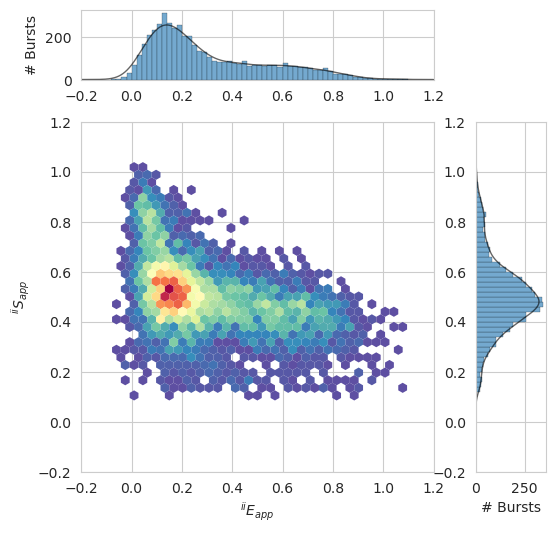

In [26]:
# alex_jointplot(d_dcbs)
fig = plt.figure(figsize=(6,6))
ax, *_ = smf.plot.jointplot(data, ddc['E_bg'], ddc['S_bg'], gate=g_dcall, fig=fig,
                           cfunc=smf.plot.hexbin, hfunc=smf.plot.hist_kdeoverlay,
                           cplot_kwargs=smf.fretfactory.ALEXdefaults['hexbin'],
                           hplot_kwargs=smf.fretfactory.ALEXdefaults['kdeover', ('bins', 'ratio_bins')])
ax[0].set_xlim([-0.2, 1.2])
ax[0].set_ylim([-0.2, 1.2])

<b><font color="magenta">Set minimum number of D<sub>ex</sub>  photons</font></b>

In [27]:
# d_fret = Sel(d_dcbs, select_bursts.size, add_naa=False, th1=30)
g_dcda = smf.make_geq_gate(ddc['NphDex_bg'], 30) & g_dcall

<b><font color="magenta">Set minimum number of A<sub>ex</sub>  photons</font></b>

In [28]:
# d_fret = Sel(d_fret, select_bursts.naa, th1=30)
g_dcfret = smf.make_geq_gate(ddc['NphAA_bg'], 30) & g_dcda

Now plot the results:

(-0.2, 1.2)

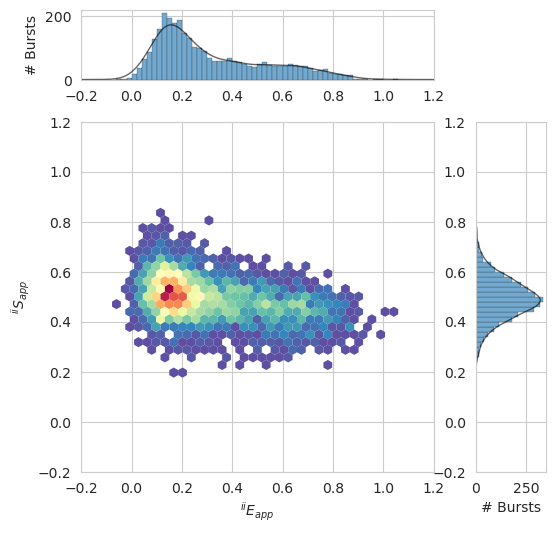

In [29]:
# alex_jointplot(d_fret);
fig = plt.figure(figsize=(6,6))
ax, *_ = smf.plot.jointplot(data, ddc['E_bg'], ddc['S_bg'], gate=g_dcfret, fig=fig,
                           cfunc=smf.plot.hexbin, hfunc=smf.plot.hist_kdeoverlay,
                           cplot_kwargs=smf.fretfactory.ALEXdefaults['hexbin'],
                           hplot_kwargs=smf.fretfactory.ALEXdefaults['kdeover', ('bins', 'ratio_bins')])
ax[0].set_xlim([-0.2, 1.2])
ax[0].set_ylim([-0.2, 1.2])

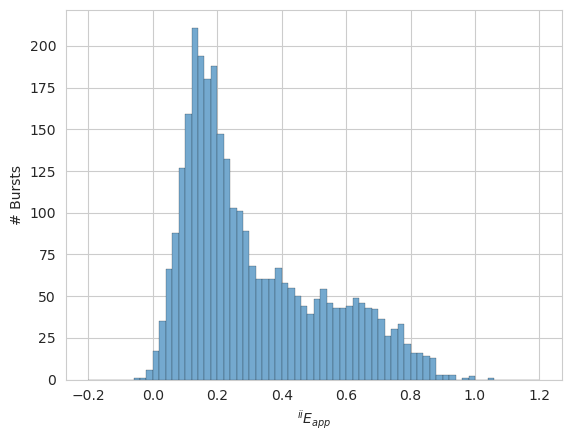

In [30]:
# dplot(d_fret, hist_fret,pdf=False)
smf.plot.hist_bar(data, ddc['E_bg'], gate=g_dcfret,
                  **smf.fretfactory.ALEXdefaults['histbar', ('bins', 'ratio_bins')]);

The above E histogram is indicative of high quality data on a system undergoing intermediate to fast dynamics, as 2 gaussians are easily seen in the E plot, but a significant number of bursts have an intermediate FRET between the two states. These bursts can be suspected of undergoing dynamics within the burst. It can therefore be expected that the DNA hairpin is undergoing some form of interconversion at a time scale comparable to that of the burst duration.

Now let's see how long it took to do the FRETBursts analysis:

In [31]:
fb_time = time.perf_counter()
printtime(begin,fb_time,'FRETBurst analysis took: ')

FRETBurst analysis took:  0h 0m 18.3496s to run


As a preliminary test, Burst Variance Analysis is performed as a more rigorous test of fast dynamics.

<a id='BVA'></a>
## Burst Variance Analysis (BVA)
This is a computationally inexpensive test for fast dynamics, if BVA shows evidence of fast dynamics, H<sup>2</sup>MM is a promising method to extract both E<sub>raw</sub> and rates of interconversion. On the other hand, if BVA shows no evidence of fast dynamics, H<sup>2</sup>MM is likely to be fruitless.

BVA assesses how much the $PR$ varies within the burst. Each burst is divided into "sub-bursts" of $N$ donor excited photons (D<sub>ex</sub>). For a given sub-burst $i$ the $E^{*}_{i}$ is defined as:

$E^{*}_{i} = \frac{n^{DA}_{i}}{n^{DA}_{i}+n^{DA}_{i}} = \frac{n^{DA}_{i}}{N}$ as $N = n^{DD}_{i} + n^{DA}_{i}$

The standard deviation of $E^{*}$ for sub-bursts within a single burst is given as $\sigma_{E_{raw}}$:

$\sigma_{E}^{*} = \sqrt{\frac{\sum^{M}_{i}{(E^{*}_{i}}-\bar{E_{raw}})^{2}}{M}}$ 

where $\bar{E_{raw}} = \frac{\sum^{M}_{i}{E^{*}_{i}}}{M}$, which is the mean $E_{raw}$ of all sub-bursts, and the $E_{raw}$ of the burst itself.

For a molecule not undergoing dynamcis, the stochastic nature of FRET means that:

$\sigma_{E_{raw}} = \sqrt{\frac{\bar{E_{raw}}(1-\bar{E_{raw}})}{N}}$

This creates a semicircle in the plot of $\sigma_{E_{raw}}$ against $E_{raw}$, and thus if a population of bursts exists along this semicircle, it can be assumed no FRET dynamics are taking place at the time scale of $N$ inter-photon times, while populations which lie above this semicircle can be expected to have FRET dynamics.

Bursts below the semicircle indicate a problem in data processing. The most likely problem is too few sub-bursts in each burst for adequate assesment, in which case the burst selection and/or $N$ needs to be modified, or, worse, the data itself is somehow faulty.

[Torella, J. P.; Holden, S. J.; Santoso, Y.; Hohlbein, J.; Kapandidis, A. N.; 2011. Identifying Molecular Dynamics in Single-Molecule FRET Experiments with Burst Variance Analysis. <i>Biophys.J.</i>, 100: 1568-1577](https://doi.org/10.1016/j.bpj.2011.01.066)

<b><font color="blue"><s>Define BVA function</s></font></b>\
<b>BVA now handled directly by `smfbursts`</b>

In [32]:
# def BVA(d, n, R, B_thr):
#     """
#     Perform BVA analysis on a given data set.
#     Calculates the std dev E in each burst, also returning binnded averages.
#     Parameters
#     ----------
#     d: FRETBursts data object
#         A FRETBursts data object, must have burst selection already performed.
#     n: int
#         Size of the sub-bursts to assess E
#     R: int
#         number of bins from 0.0 to 1.0 to subdivide when returning mean std. dev.
#     B_thr: int
#         Minimum number of bursts to return a value for mean std. dev.
#     Returns
#     -------
#     Std_small: 1D NUMPY array (float)
#         Standard deviation of E of each burst
#     Avg_small: 1D NUMPY array (float)
#         Uncorrected E of each burst
#     std_temp: 1D NUMPY array (float)
#         The mean standard deviation for the given range, as defined by bins defined
#         by R, if the number of bursts within that range is less than B_thr, then that
#         element will be -1.0
#     avg_temp: 1D NUMPY array (float)
        
#     """
#     bursts =d.mburst[0]
#     ph_d = d.get_ph_times(ph_sel=Ph_sel(Dex='DAem'))
#     AemDex_mask = d.get_ph_mask(ph_sel=Ph_sel(Dex='Aem')) 
#     Dex_mask = d.get_ph_mask(ph_sel=Ph_sel(Dex='DAem'))   
    
#     Std_small=[]
#     Avg_small=[]
#     bn = np.arange(0,1+(2/R),1/R)
#     avg_bin = [[] for i in range(bn.size-1)]
#     std_bin = [[] for i in range(bn.size-1)]
#     for burst in bursts:
#         E_small=[]
#         pos = burst.istart
#         while(pos < burst.istop+1-n): # outer while loop for chuncks of size n
#             DAcnt = 0 # count number of photons that are from Donor excitation
#             Acnt = 0 # count FRET photons
#             while(DAcnt < n):
#                 if Dex_mask[pos]:
#                     DAcnt += 1
#                     if AemDex_mask[pos]:
#                         Acnt += 1
#                 pos += 1
#             E = Acnt / DAcnt #calculate FRET of chunk
#             E_small.append(E)
#         std_temp = np.std(E_small)
#         avg_temp = np.mean(E_small)
#         Std_small.append(std_temp)
#         Avg_small.append(avg_temp)
#         E_burst = AemDex_mask[burst.istart:burst.istop+1].sum() / Dex_mask[burst.istart:burst.istop+1].sum()
#         loc = np.argwhere((bn[:-1] <= E_burst) & (bn[1:] > E_burst))[0][0]
#         #print(np.argwhere((bn[:-1] <= E_burst) & (bn[1:] > E_burst))[0][0])
#         std_bin[loc].append(np.std(E_small))
#         avg_bin[loc].append(np.mean(E_small))
#     std_temp = []
#     avg_temp = []
#     for std, avg in zip(std_bin, avg_bin):
#         if len(std) >= B_thr:
#             std_temp.append(np.mean(std))
#             avg_temp.append(np.mean(avg))
#         else:
#             std_temp.append(-1)
#             avg_temp.append(-1)
#     return (np.array(Std_small), np.array(Avg_small), np.array(std_temp), np.array(avg_temp)) #std_bin, avg_bin


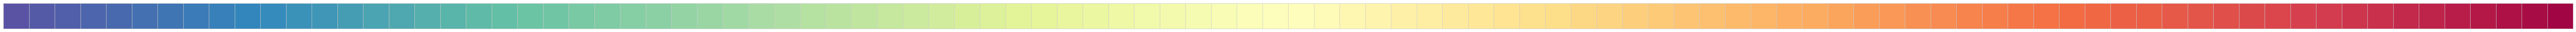

In [33]:
plot_levels = 100
sns.palplot(sns.color_palette('Spectral_r', plot_levels))
BLUE = sns.color_palette('Spectral_r', plot_levels)[0]

In [34]:
R = 20
n = 5
B_Thr = 40

<a id='bvada'></a>
### Plot the BVA of the Donor Active selection (<s>`d_da`</s> `dbs`/`g_da`)

Text(0.5, 1.0, 'Donor Active population')

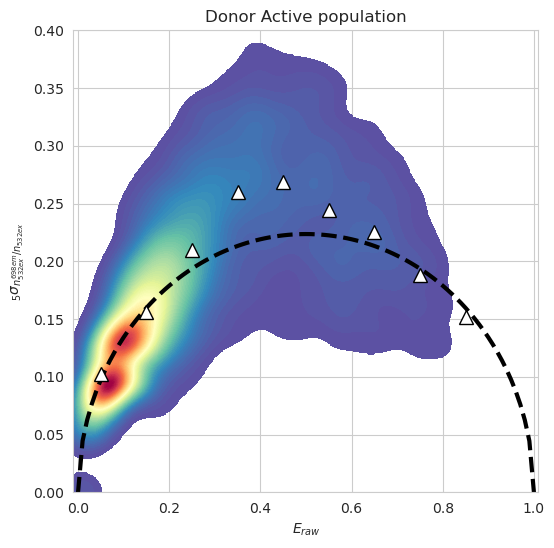

In [35]:
# std_da, avg_da, std_da1, bn_da = BVA(d_da, n, R, B_Thr)
dbs['BVA5'] = smf.Column(dbs['bursts'], 'bva', (smf.PhSel('0ex1em'), smf.PhSel('0ex'), n))

# sns.set_style(style='darkgrid')
# plt.figure(figsize=(6,6))
# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# plt.plot(x_T,y_T, lw=3, color='k', ls='--')
# plt.plot (bn_da , std_da1, marker="^", color='white', mew=1, mec='k', lw=0, ms=10, alpha=1)
plt.figure(figsize=(6,6))
x_T=np.arange(0,1.01,0.01)
y_T=np.sqrt((x_T*(1-x_T))/n)
plt.plot(x_T,y_T, lw=3, color='k', ls='--')

# plt.plot (bn_da , std_da1, marker="^", color='white', mew=1, mec='k', lw=0, ms=10, alpha=1)
smf.plot.plot_meaninterval(data, dbs['E_raw'], dbs['BVA5'], gate=g_da, marker='^', 
                           color='white', ms=10, mew=1, mec='k', lw=0, bins=np.linspace(0,1,11))

# im = sns.kdeplot(x=avg_da, y=std_da, shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100)
smf.plot.kdeplot(data, dbs['E_raw'], dbs['BVA5'], cmap='Spectral_r', gate=g_da, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels)

# plt.xlim(-0.01,1.01)
# plt.ylim(0,0.4)
plt.xlim(-0.01,1.01)
plt.ylim(0,0.4)

# plt.xlabel('$\mathbf{E_{raw}}$', fontsize=18)
# plt.ylabel('$\mathbf{\sigma_{E}^{*}}$', fontsize=18)
plt.title('Donor Active population')
# plt.savefig(full_fname , dpi=200, bbox_inches='tight')

Text(0.5, 1.0, 'Donor Active population')

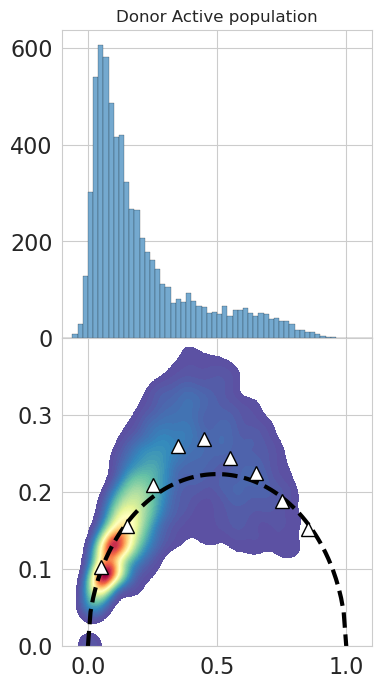

In [36]:
# hist_bar_style={'facecolor': BLUE, 'alpha': 1, 'edgecolor': 'white', 'linewidth':0.2}
hist_bar_style={'facecolor': BLUE, 'alpha': 1, 'edgecolor': 'white', 'linewidth':0.2}

# pnlsRows = 2
# pnlsCols = 1
# sns.set_style(style='whitegrid')
# fig, ax = plt.subplots(pnlsRows, pnlsCols, sharex=True, figsize=(4*pnlsCols, 4*pnlsRows))
# plt.subplots_adjust(hspace=0, wspace=0.2)
pnlsRows = 2
pnlsCols = 1
fig, ax = plt.subplots(pnlsRows, pnlsCols, sharex=True, figsize=(4*pnlsCols, 4*pnlsRows))
plt.subplots_adjust(hspace=0, wspace=0.2)

# dplot(d_da, hist_fret, pdf=False, weights = None, ax=ax[0], binwidth=0.025, hist_bar_style=hist_bar_style)
smf.plot.hist_bar(data, dbs['E_bg'], gate=g_da, ax=ax[0], 
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])

# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# ax[1].plot(x_T,y_T, lw=3, color='k', ls='--')
x_T=np.arange(0,1.01,0.01)
y_T=np.sqrt((x_T*(1-x_T))/n)
ax[1].plot(x_T,y_T, lw=3, color='k', ls='--')

# im = sns.kdeplot(x=avg_da, y=std_da, shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100, ax=ax[1])
smf.plot.kdeplot(data, dbs['E_raw'], dbs['BVA5'], cmap='Spectral_r', gate=g_da, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels, ax=ax[1])

# ax[1].plot (bn_da , std_da1, marker="^", color='white', mew=1, mec='k', lw=0, ms=10, alpha=1)
smf.plot.plot_meaninterval(data, dbs['E_raw'], dbs['BVA5'], gate=g_da, marker='^', ax=ax[1],
                           color='white', ms=10, mew=1, mec='k', lw=0, bins=np.linspace(0,1,11))

# ax[1].set_ylim(0,0.4)
# ax[1].set_yticks(np.arange(0, 0.4, 0.1))
# for a in ax.ravel():
#     a.set_xlabel('')
#     a.set_ylabel('')
#     a.set_title('')
#     a.set_xlim(-0.1,1.1)
#     a.tick_params(axis='both', which='major', labelsize=16)
#     a.tick_params(axis='both', which='minor', labelsize=14)
ax[1].set_ylim(0,0.4)
ax[1].set_yticks(np.arange(0, 0.4, 0.1))
for a in ax.ravel():
    a.set_xlabel('')
    a.set_ylabel('')
    a.set_title('')
    a.set_xlim(-0.1,1.1)
    a.tick_params(axis='both', which='major', labelsize=16)
    a.tick_params(axis='both', which='minor', labelsize=14)

# ax[0].set_ylabel('# Bursts', fontsize=18, fontweight='bold')
# ax[1].set_ylabel('$\mathbf{\sigma_{E}^{*}}$', fontsize=18)
# ax[1].set_xlabel('$\mathbf{E_{raw}}$', fontsize=18)
# ax[0].set_title('Donor Active population')
ax[0].set_title('Donor Active population')
# plt.savefig('HP3-300BVA.png', bbox_inches='tight')

<a id='bvafret'></a>
### Plot the BVA of the FRET burst selection (<s>`d_fret`</s> `ddc`/`g_dcfret`)

Text(0.5, 1.0, 'FRET population')

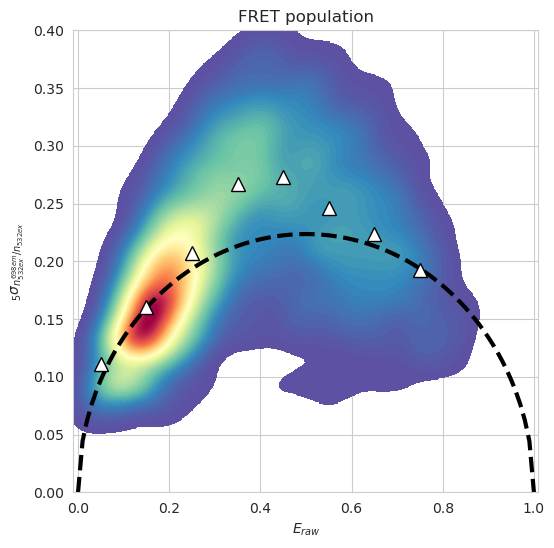

In [37]:
# std_fret, avg_fret, std_fret1, bn_fret = BVA(d_fret, n, R, B_Thr)
ddc['BVA5'] = smf.Column(ddc['bursts'], 'bva', (smf.PhSel('0ex1em'), smf.PhSel('0ex'), n))

# sns.set_style(style='darkgrid')
# plt.figure(figsize=(6,6))
# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# plt.plot(x_T,y_T, lw=3, color='k', ls='--')
plt.figure(figsize=(6,6))
x_T=np.arange(0,1.01,0.01)
y_T=np.sqrt((x_T*(1-x_T))/n)
plt.plot(x_T,y_T, lw=3, color='k', ls='--')

# plt.plot (bn_fret , std_fret1, marker="^", color='white', mew=1, mec='k', lw=0, ms=10, alpha=1)
smf.plot.plot_meaninterval(data, ddc['E_raw'], ddc['BVA5'], gate=g_dcfret, marker='^', 
                           color='white', ms=10, mew=1, mec='k', lw=0, bins=np.linspace(0,1,11))

# im = sns.kdeplot(x=avg_fret, y=std_fret, shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100)
smf.plot.kdeplot(data, ddc['E_raw'], ddc['BVA5'], cmap='Spectral_r', gate=g_dcfret, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels)

# plt.xlim(-0.01,1.01)
# plt.ylim(0,0.4)
plt.xlim(-0.01,1.01)
plt.ylim(0,0.4)

# plt.xlabel('$\mathbf{E_{raw}}$', fontsize=18)
# plt.ylabel('$\mathbf{\sigma_{E}^{*}}$', fontsize=18)
# plt.title('FRET population')
plt.title('FRET population')
# plt.savefig(full_fname , dpi=200, bbox_inches='tight')

Text(0.5, 1.0, 'FRET population')

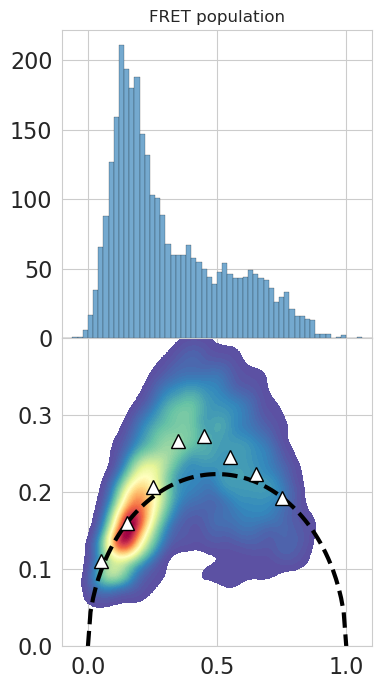

In [38]:
# hist_bar_style={'facecolor': BLUE, 'alpha': 1, 'edgecolor': 'white', 'linewidth':0.2}
hist_bar_style={'facecolor': BLUE, 'alpha': 1, 'edgecolor': 'white', 'linewidth':0.2}

# pnlsRows = 2
# pnlsCols = 1
# fig, ax = plt.subplots(pnlsRows, pnlsCols, sharex=True, figsize=(4*pnlsCols, 4*pnlsRows))
# plt.subplots_adjust(hspace=0, wspace=0.2)
pnlsRows = 2
pnlsCols = 1
fig, ax = plt.subplots(pnlsRows, pnlsCols, sharex=True, figsize=(4*pnlsCols, 4*pnlsRows))
plt.subplots_adjust(hspace=0, wspace=0.2)

# dplot(d_fret, hist_fret, pdf=False, weights = None, ax=ax[0], binwidth=0.025, hist_bar_style=hist_bar_style)
smf.plot.hist_bar(data, ddc['E_bg'], gate=g_dcfret, ax=ax[0], 
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])

# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# ax[1].plot(x_T,y_T, lw=3, color='k', ls='--')
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_T*(1-x_T))/n)
ax[1].plot(x_bva, y_bva, lw=3, color='k', ls='--')


# im = sns.kdeplot(x=avg_fret, y=std_fret, shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100, ax=ax[1])
smf.plot.kdeplot(data, ddc['E_raw'], ddc['BVA5'], cmap='Spectral_r', gate=g_dcfret, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels, ax=ax[1])

# ax[1].plot (bn_fret , std_fret1, marker="^", color='white', mew=1, mec='k', lw=0, ms=10, alpha=1)
smf.plot.plot_meaninterval(data, ddc['E_raw'], ddc['BVA5'], gate=g_dcfret, marker='^', ax=ax[1],
                           color='white', ms=10, mew=1, mec='k', lw=0, bins=np.linspace(0,1,11))

# ax[1].set_ylim(0,0.4)
# ax[1].set_yticks(np.arange(0, 0.4, 0.1))
# for a in ax.ravel():
#     a.set_xlabel('')
#     a.set_ylabel('')
#     a.set_title('')
#     a.set_xlim(-0.1,1.1)
#     a.tick_params(axis='both', which='major', labelsize=16)
#     a.tick_params(axis='both', which='minor', labelsize=14)
ax[1].set_ylim(0,0.4)
ax[1].set_yticks(np.arange(0, 0.4, 0.1))
for a in ax.ravel():
    a.set_xlabel('')
    a.set_ylabel('')
    a.set_title('')
    a.set_xlim(-0.1,1.1)
    a.tick_params(axis='both', which='major', labelsize=16)
    a.tick_params(axis='both', which='minor', labelsize=14)

# ax[0].set_ylabel('# Bursts', fontsize=18, fontweight='bold')
# ax[1].set_ylabel('$\mathbf{\sigma_{E}^{*}}$', fontsize=18)
# ax[1].set_xlabel('$\mathbf{E_{raw}}$', fontsize=18)
# ax[0].set_title('FRET population')
ax[0].set_title('FRET population')
# plt.savefig('HP3-300BVA.png', bbox_inches='tight')

The above BVA plot is indicative of fast dynamcis, due to the significant portion of the plot existing above the $\sigma_E^*$ expected for FRET resulting from a single state binomial process. It is therefore valid to use H<sup>2</sup>MM to extract E and interconversion rates

In [39]:
bva_time = time.perf_counter()
printtime(fb_time,bva_time,'BVA took: ')

BVA took:  0h 0m 51.7359s to run


<a id='h2mm'></a>
# H<sup>2</sup>MM Analysis

The following defines a function to make the data accessible to H<sup>2</sup>MM algorithm. H<sup>2</sup>MM requires a pair of lists of numpy arrays: one list of the burst arrival times, and the other of photon stream indices. The lists must be of equal length, and the numpy arrays of same position must also be the same size.
The arrays of photon streams are seen by the H<sup>2</sup>MM algorithm as indices- therefore each photon stream being used(ie D<sub>ex</sub>D<sub>em</sub>, D<sub>ex</sub>A<sub>em</sub>, and A<sub>ex</sub>A<sub>em</sub>) must be "assigned" an index, starting from 0, and incrementing by 1 (indices are integral values).
Traditional H<sup>2</sup>MM uses only the D<sub>ex</sub>D<sub>em</sub> and D<sub>ex</sub>A<sub>em</sub> streams, which are assigned indices 0 and 1 respectively, all other photon streams are discarded.
Multidimentional H<sup>2</sup>MM assigns additional photon streams to higher indices, but can still discard some photon streams. The below function is designed to be flexible, but with sensible defaults. By default D<sub>ex</sub>D<sub>em</sub> is assigned to index 0, D<sub>ex</sub>A<sub>em</sub> to 1, A<sub>ex</sub>A<sub>em</sub> to 2, and A<sub>ex</sub>D<sub>em</sub> to 3. It will then discard photons from streams with an index $\geq$ nchan, so by default nchan is set to 2, which means that A<sub>ex</sub>A<sub>em</sub> and A<sub>ex</sub>D<sub>em</sub> streams are discarded, and in the multidimensional H2MM we use nchan=3, so that the A<sub>ex</sub>A<sub>em</sub> is included, but A<sub>ex</sub>D<sub>em</sub>, which should be exclusively noise, is discarded.

<b><font color="blue"><s>Generate inputs for `EM_H2MM_C`</s></font></b>\
<b>This function is implemented H2MMbursts</b>

In [40]:
# def data_sort(data,nchan=3,Aex_stream=2,Aex_shift=None,**kwargs):
#     usALEX = hasattr(data,'alex_period')
#     if usALEX:
#         if Aex_shift not in [None, 'shift', 'rand', 'even']:
#             raise ValueError("Aex_shift must be 'shift', 'rand', or 'even'")
#     elif Aex_shift is not None:
#         raise ValueError("Aex_shift only valid for usALEX data")
#     if (len(kwargs) == 0):
#         chan_sel = [Ph_sel(Dex='Dem'), Ph_sel(Dex='Aem'), Ph_sel(Aex='Aem'), Ph_sel(Aex='Dem')]
#         n = 4
#     else:
#         n = 1
#         chan_sel = []
#         while kwargs.get('ph_sel' + str(n)) != None:
#             chan_sel.append(kwargs.get('ph_sel' + str(n)))
#             n += 1
#         n += -1
#     print('Sorting photon channels',end='...')
#     chans = np.array([data.get_ph_mask(ph_sel=chan_sel[i]) for i in range(0,len(chan_sel))])
#     mask = chans.sum(axis=0)
#     if np.any(mask != 1):
#         print('Photon assigned to multiple channels or none, check ph_sel selections')
#         return None
#     ph_chan = np.zeros(chans.shape[1],dtype=int)
#     for i in range(0,len(chan_sel)):
#         ph_chan += i*chans[i,:]
#     ph_times = data.ph_times_m[0]
#     if not usALEX:
#         ph_nanotime = data.nanotimes[0]
#         ArrivalNanotime = []
#     burst = data.mburst[0]
#     ArrivalColor = []
#     ArrivalTime = []
#     print('Slicing data into bursts',end='...')
#     for start, stop in zip(burst.istart, burst.istop + 1):
#         ArrivalColor.append(ph_chan[start:stop][ph_chan[start:stop]<nchan])
#         ArrivalTime.append(ph_times[start:stop][ph_chan[start:stop]<nchan])
#         if not usALEX:
#             ArrivalNanotime.append(ph_nanotime[start:stop][ph_chan[start:stop]<nchan])
#     # apply a shift to usALEX AexAem photons, and make sure to re-sort the photons
#     if Aex_shift == 'shift' and Aex_stream < nchan:
#         print("Shifting Aex photons",end='...')
#         alex_shift = data.D_ON[0] - data.A_ON[0]
#         for i, (color, time) in enumerate(zip(ArrivalColor,ArrivalTime)):
#             time[color==Aex_stream] += alex_shift
#             sort = np.argsort(time)
#             ArrivalColor[i] = color[sort]
#             ArrivalTime[i] = time[sort]
#     elif Aex_shift == 'rand' and Aex_stream < nchan:
#         print("Shift and randomizing Aex photons",end='...')
#         D_ON, D_OFF = data.D_ON[0], data.D_ON[1]
#         for i, (color, time) in enumerate(zip(ArrivalColor, ArrivalTime)):
#             time_temp = time.copy()
#             alex_mask = color == Aex_stream
#             alex_new = np.random.randint(D_ON,D_OFF,size=alex_mask.sum())
#             time_temp[alex_mask] = alex_new + (time[alex_mask] // data.alex_period)*data.alex_period
#             sort = np.argsort(time_temp)
#             ArrivalColor[i] = color[sort].astype('uint8')
#             ArrivalTime[i] = time_temp[sort]
#     elif Aex_shift == 'even' and Aex_stream < nchan:
#         print("Distributing Aex photons",end='...')
#         D_ON, D_OFF = data.D_ON[0], data.D_ON[1]
#         D_dur = D_OFF - D_ON
#         for i, (color, time) in enumerate(zip(ArrivalColor, ArrivalTime)):
#             Aex_mask = color == Aex_stream
#             tms, inverse, counts = np.unique(time[Aex_mask]//data.alex_period,return_counts=True,return_inverse=True)
#             newAex_times = np.empty(inverse.shape,dtype=time.dtype)
#             for j, (tm, count) in enumerate(zip(tms,counts)):
#                 t_beg = tm*data.alex_period + D_ON + D_dur/(count+1)
#                 t_end = tm*data.alex_period + D_OFF
#                 newAex_times[j==inverse] = np.arange(t_beg,t_end,D_dur/(count+1))[:count]
#             time_new = time.copy()
#             time_new[Aex_mask] = newAex_times
#             sort = np.argsort(time_new)
#             ArrivalColor[i] = color[sort].astype('uint8')
#             ArrivalTime[i] = time_new[sort]
#     print('Done')
#     if usALEX:
#         return ArrivalColor, ArrivalTime
#     else:
#         return ArrivalColor, ArrivalTime , ArrivalNanotime

## Adapting to other mpH<sup>2</sup>MM modes
<s>This function is specific to FRETBursts.
To adapt for multi-color FRET or polarization, new code must be written, as FRETBursts does not support multicolor FRET or polarization.
The method is simple, each stream, one for each fluorophore, each must be assigned an index, starting from 0, then 1, 2 ..., the same applies to other excitation photon streams, 1 stream, 1 index. Calculation of $PR_{i,j}$ will then be dependent on summing the appropriate streams to exclude streams from excitation irrelevant to that $PR$</s>

See the other `H2MMbursts` tutorials to understand the general means of adapting mpH<sup>2</sup>MM to any detector scheme.

## Model Choice, Error and Viterbi Analysis

H<sup>2</sup>MM fits however many states are given to the algorithm, 
and so multiple models of different states must be fit, and then assessed to find the ideal number of states, neither over or under fitting. 
The loglikelihood of each fitting is insufficient to discriminate between models, as it always improves the more states in the model. 
The Bayes Information Criterion is a common statistic used to decide between models.

$BIC = -2 \ln(\mathbf{p}(\mathbf{y} | m, \hat{\lambda_m})) + K \ln(n) = -2 \ln(L) + K \ln(n)$

Where $\mathbf{y}$ is the data, $m$ is the Markov model, and $\hat{\lambda_m}$ is the maximum likelihood estimator, $\ln(L)$ is the loglikelihood, $n$ is the number of data points, for H<sup>2</sup>MM, this is the number of photons analyzed, and $K$ is the number of free parameters in the model. $K$ for H<sup>2</sup>MM can be calculated as follows:

$K = q^2 + (r-1) q -1$

where $q$ is the number of states and $r$ is the number of photon streams (2 for spH<sup>2</sup>MM, 3 for 2c-ALEX based mpH<sup>2</sup>MM). 
For H<sup>2</sup>MM, however, the BIC still always improves with more states.

Here, the *Viterbi* algorithm comes to the rescue, the *Viterbi* algorithm uses the posterior probability to predict the most likely state path, $\hat{\mathbf{s}}$ through a given data set. 
Using this, a new penalized likelihood criteria can be defined, the Integrated Complete Likelihood (ICL):

$ICL = 2\ln(\mathbf{p}(\mathbf{y} , \hat{\mathbf{s}} | m, \hat{\lambda_m})) - K ln(n)$

The first term, $\ln(\mathbf{p}(\mathbf{y} , \hat{\mathbf{s}} | m, \hat{\lambda_m}))$ which replaces the loglikelihood, is the sum of the posterior probabilities. 
<s>The `viterbi_sort` function returns both the ICL as well as the posterior probabilities in different registers of its output.</s> 
`H2MMbursts` provides several methods for accessing the ICL, such as `bhm.plot.scatter_ICL()` and `bhm.StatePath.ILC()`.

The H<sup>2</sup>MM algorithm has no output to quantify the standard error of the model parameters, only the overall loglikelihood of the model. 
However, the Viterbi algorithm finds the most likely state path for the given H<sup>2</sup>MM model and photon trajectory. 
Using the most likely trajectory, photons can be sorted into dwells. 
Statistics can be derived for these dwells, the base statistics are the duration, 
the difference between the arrival times of the first and last photon in the dwell, and counts of photons in each stream. 
For spH<sup>2</sup>MM these are $n_{dwell}^{DD}$ and $n_{dwell}^{DA}$, while mpH<sup>2</sup>MM adds $n_{dwell}^{AA}$. 
From these basic values, statistics about the FRET behavior can be derived. 

<a id='h2mmerror'></a>
spH<sup>2</sup>MM allows for calculation of $E_{raw}$, while mpH<sup>2</sup>MM allows calculation of $E_{raw}$ and $S_{raw}$

$E_{raw,dwell} = \frac{n_{dwell}^{DA}}{n_{dwell}^{DA}+n_{dwell}^{DD}}$ and $S_{raw,dwell} = \frac{n_{dwell}^{DA}+n_{dwell}^{DD}}{n_{dwell}^{DA}+n_{dwell}^{DD}+n_{dwell}^{AA}} = \frac{n_{dwell}^{DA}+n_{dwell}^{DD}}{n_{dwell}^{total}}$

*Notice that for $E_{raw}$ the denominator is $n_{i}^{DA}+n_{i}^{DA}$, rather than $n_{i}^{total}$- for spH<sup>2</sup>MM, these two are identical, but not for mpH<sup>2</sup>MM. The same change propogates for the calculation of the weigthed average and standard error.*

Weigthed average viterbi values can be derived for these ratiometric values:

$\bar{^{S}E_{raw,w}} = \frac{\sum\limits_{i}^{S}{(n_{i}^{DD}+n_{i}^{DA})PR_{i}}}{\sum\limits_{i}^{S}{n_{i}^{DD}+n_{i}^{DA}}}$
and
$\bar{^{S}S_{raw,w}} = \frac{\sum\limits_{i}^{S}{n_{i}^{total}S_{i}}}{\sum\limits_{i}^{S}{n_{i}^{total}}}$

And their standard errors calculated in the same manner:

$SE(\bar{^{S}E_{raw,w}})= \sqrt{\frac{\sum\limits_{i}^{S}{(n_{i}^{DA}+n_{i}^{DD})(E_{i}-\bar{^{S}E_{w}})^{2}}}{\sum\limits_{i}^{S}{n_{i}^{DA}+n_{i}^{DD}}}}/\sqrt{l}$ 
and 
$SE(\bar{^{S}S_{raw,w}})= \sqrt{\frac{\sum\limits_{i}^{s}{n_{i}^{total}(S_{i}-\bar{^{S}S_{w}})^{2}}}{\sum\limits_{i}^{s}{n_{i}^{total}}}}/\sqrt{l}$

For calculation of the standard error in transition rates, attention must be focused on $t_{dwell}$. 
For this, dwells must be grouped by more than just the state of the dwell, $g$, but also the state of the subsequent dwell, $h$. 
It should also be noted that the first and last dwells will be discarded in error calculation, as these are truncated and will bias the result. 
Dwells which do not begin or end at the beginning or end of a burst are denoted as $t_{dwell, gh}$. From this we can define for each transition, a mean lifetime:

$\bar{t}_{dwell, gh} = \sum\limits_{i=1}^{l_{gh}}{t_{i,gh}}/l_{gh}$

and a standard error

$SE(\bar{t}_{dwell, gh}) = [\sum\limits_{i=1}^{l_{gh}}{(t_{i,gh}-\bar{t_{dwell,gh}})^{2}}/{l_{gh}}]^{1/2}/\sqrt{l_{gh}}$

To convert into transiton rates $k_{gh}$, the inverse is taken,

$\bar{k_{gh}} = 1/\bar{t}_{dwell,gh}$

and to calculate the standard error:

$SE(\bar{k_{gh}}) = \frac{SE(t_{dwell, gh})}{\bar{t}_{dwell,gh}^{2}}$

The `ES_error` function calculates the error bars in $PR$ and $S_{PR}$ values, but error calculation of transition rates is done without a function, so that fine control and examination of the nature of beginning and ending dwells can be considered.

Calculations for $PR$, $S$, and $t_{dwell}$ and calculation of their standard error were taken from:
[Lerner, E.; Ingargiola, A.; Weiss, S. 2018. Characterizing Highly Dynamic Conformational States: The Transcription Buble in RNAP-promoter Open Complex as an Example. <i>J. Chem. Phys.</i> 148, 123315](https://doi.org/10.1063/1.5004606)

Note: the following paper is becoming standard in the field:
[Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of single-molecule FRET measurements—a multi-laboratory benchmark study. <i>Nat Methods</i> 15, 669–676 (2018).](https://doi.org/10.1038/s41592-018-0085-0)


ICL is found in:
[Celeux, G.; Durand, J.B.; 2008. Selecting Hidden Markob Model state number with cross-validated likelihood. <i>Comp. Stats.</i> 4, 541](https://doi.org/10.1007/s00180-007-0097-1)

<s>The function below calculates BIC, and BIC' of the given set of fittings</s> 
This function is handled by functions in H2MMbursts like `calc_BIC()` and `calc_ICL()`

In [41]:
# this function is implemeneted directly in H2MMbursts
# def calc_bicp(models):
#     assert np.all(np.diff(np.array([model.ndet for model in models])) == 0), "H2MM models do not have the same number of detectors, cannot compare BIC values"
#     model_state = np.array([model.nstate for model in models])
#     model_sort = np.unique(model_state)
#     assert model_sort.size == model_state.size, "Two models have the same number of states, one is either inherently inferior, or not for the same data set"
#     assert np.all(np.diff([model.nphot for model in models]) == 0), "Models must have same number of photons, you are comparing apples to oranges"
#     model_ord = [np.argwhere(model_state == model_sort[i])[0][0] for i in range(len(models))]
#     modelv = [models[i] for i in model_ord]
#     loglik = np.array([model.loglik for model in modelv])
#     bic = np.array([model.bic for model in modelv])
#     k = np.array([model.k for model in modelv])
#     dbic = bic - np.min(bic)
#     nphot = modelv[0].nphot
#     bicp = np.array([db/(nphot - ki) for db, ki in zip(dbic, k)])
#     return bicp

The following function takes the H<sup>2</sup>MM model, and calculates the PR and S<sub>PR</sub> values, and does unit conversion to get the transition rates in units of s<sup>-1</sup>, and prints both out in easier to read format:

<b><font color="blue"><s>Calcualte transition rates, $E$, and $S$ of states in a model, assuming default assignments from `data_sort`</s></font> </b>
<s>note: if *leakage*, *direct excitation*, $\gamma$, and/or $\beta$ have been calculated and this function is given a `data` object, the function will apply these corrections, if these values are in the `data` object, or a clock rate is given, then $E_{raw}$ and $S_{raw}$ are returned.</s>

**This function is implemented directly in H2MMbursts**

In [42]:
# def get_ES(h_mod,dat):
#     """
#     Function for calculating the transition rates, E and S values from a fit model, and the data object.
#     Applies dir_ex, leakage, gamma, and beta corrections according to the values stored in the data object.
#     Agruments:
#     h_mod: h2mm_model
#         A fit h2mm_model object
#     dat: float, or data object
#         The clk_p of the input data, or a data object, if it is a data object, the dir_ex, leakage, gamma 
#         and beta correctios will be applied.
#     Returns:
#         trans: NUMPY float array
#             the transition probability matrix, scaled to be in units of s^-1
#         ES: Numpy float array
#             The E and S values of the model, first column is the E values, second the S, if a 2 stream model,
#             then the returned array will be 1D of E values. dir_ex, leakage, gamma, beta correctiosn are applied.
#     """
#     if type(dat) == Data:
#         lk = dat.leakage
#         dir_ex = dat.dir_ex
#         gamma = dat.gamma
#         beta = dat.beta
#         clk_p = dat.clk_p
#     elif type(dat) == dict:
#         lk = dat['leakage']
#         dir_ex = dat['dir_ex']
#         gamma = dat['gamma']
#         beta = dat['beta']
#         clk_p = dat['clk_p']
#     else:
#         lk = 0.
#         dir_ex = 0.
#         beta = 1.
#         gamma = 1.
#         clk_p = dat
#     if h_mod.ndet != 2 and h_mod.ndet != 3:
#         raise ValueError('Number of streams not supported')
#     trans = h_mod.trans / clk_p
#     F_dd = h_mod.obs[:,0]
#     if h_mod.ndet == 3:
#         F_dd = h_mod.obs[:,0]
#         F_aa = h_mod.obs[:,2]
#         F_fret = h_mod.obs[:,1] - (lk * F_dd) - (dir_ex * F_aa)
#         E = F_fret / ((gamma * F_dd) + F_fret)
#         S = (F_fret + (gamma * F_dd)) / ( F_aa/beta + (F_fret + (gamma * F_dd)))
#         ES = np.array([E,S]).T
#     elif h_mod.ndet ==2:
#         F_dd = h_mod.obs[:,0]
#         F_fret = h_mod.obs[:,1] - (lk * F_dd)
#         F_fret = F_fret - lk * F_dd
#         ES = F_fret / ((gamma*F_dd) + F_fret)
#     return trans, ES

<s>The following function takes the photon counts of each dwell, and calculates the $\bar{^{S}E_{raw,w}}$ and $\bar{^{S}S_{raw,w}}$ of each dwell, 
and calculates the weighted mean, standard deviation, and standard error for each state:</s>
<b><font color="blue"><s>Calculate Errors based on [above equations](#h2mmerror)</s></font></b>

**These are now direclty handled by `H2MMbursts`**

In [43]:
# def ES_error(ph_counts):
#     E = []
#     S = []
#     E_weight = []
#     S_weight = []
#     E_av = []
#     S_av = []
#     E_std = []
#     S_std = []
#     E_err = []
#     S_err = []
#     for i, state in enumerate(ph_counts):
#         E_temp = np.zeros(state.shape[0])
#         # loop to avoid divide by 0 warnings
#         for j in range(state.shape[0]):
#             if (state[j,1] + state[j,0]) != 0:
#                 E_temp[j] = state[j,1] / (state[j,1] + state[j,0])
#             else:
#                 E_temp[j] = np.nan
#         E.append(E_temp)
#         E_weight.append(state[:,0:2].sum(axis=1))
#         S.append(state[:,0:2].sum(axis=1) / state.sum(axis=1))
#         S_weight.append(state.sum(axis=1))
#         E_av.append(np.average(E_temp[E_temp >= 0],weights=E_weight[i][E_temp >= 0])) # >0 to skip nan values
#         S_av.append(np.average(S[i],weights=S_weight[i]))
#         E_std_sum = 0.0
#         S_std_sum = 0.0
#         # for loop because no weighted std dev function in numpy
#         for j in range(state.shape[0]):
#             if E_temp[j] > 0:
#                 E_std_sum += E_weight[i][j] * (E_temp[j] - E_av[i])**2
#             S_std_sum += S_weight[i][j] * (S[i][j] - S_av[i])**2
#         E_std_sum = np.sqrt(E_std_sum / E_weight[i].sum()) 
#         E_std.append(E_std_sum)
#         E_err.append( E_std_sum / np.sqrt((E_temp > 0).sum()))
#         S_std_sum = np.sqrt(S_std_sum / S_weight[i].sum())
#         S_std.append(S_std_sum)
#         S_err.append(S_std_sum / np.sqrt(state.shape[0]))
#     return E, S, E_av, S_av, E_err, S_err, E_std, S_std

<s>`highlight` colors the cells of the transition rates easier based on the interphoton time and number of dwells detected by *Viterbi*</s>

Newer versions of pandas have altered the functionality employed in the old highlight function.
The `highlight_summary()` function is redesigned to be used after creating the data frame,
and returns a pandas *Styler* object, which displays the dataframe with html formatting.

**This function is directly implemented in H2MMbursts**

In [44]:
# def highlight(dd, max_t, num_dwell, dwell_min):
#     ddd = pd.DataFrame('',index=dd.index,columns=dd.columns)
#     if 'S vit' in ddd:
#         for i in range(ddd.shape[0]):
#             for j in range(ddd.shape[0]):
#                 if dd.iloc[i][j+6] > max_t:
#                     ddd.iloc[i][j+6] = 'color: red'
#                 elif num_dwell[i,j] < dwell_min:
#                     ddd.iloc[i][j+6] = 'color: orange'
#                 else:
#                     ddd.iloc[i][j+6] = 'color: blue'
#     else:
#         for i in range(ddd.shape[0]):
#             for j in range(ddd.shape[0]):
#                 if dd.iloc[i][j+3] > max_t:
#                     ddd.iloc[i][j+3] = 'color: red'
#                 elif num_dwell[i,j] < dwell_min:
#                     ddd.iloc[i][j+3] = 'color: orange'
#                 else:
#                     ddd.iloc[i][j+3] = 'color: blue'
#     return ddd

`ES_summary` uses the previous functions to build a convenient pandas dataframe of the H<sup>2</sup>MM and *Viterbi* results, and prints out the dataframe with highlighting of transition rates based on if they are faster than the interphoton time (red), or slower than is reasonably detected given the data set (orange, based on finding fewer than 10 reasonable dwells in that state)

In [45]:
# def ES_summary(hmod,result,data,ph_min=5,dwell_min=10):
#     # extracting parameters from the inputs into separate variables
#     clk_p = data.clk_p
#     if hmod.ndet == 3:
#         max_t = 1/(mtuple_delays_min(data.get_ph_times(ph_sel=Ph_sel(Dex='DAem',Aex='Aem')),10)*clk_p)
#     else:
#         max_t = 1/(mtuple_delays_min(data.get_ph_times(ph_sel=Ph_sel(Dex='DAem')),10)*clk_p)
#     ph_counts = result[9]
#     dwell_mid = result[5]
#     trans_mod, ES_mod = get_ES(hmod,clk_p)
#     if hmod.ndet == 2:
#         E_mod = ES_mod
#     else:
#         E_mod, S_mod = ES_mod[:,0], ES_mod[:,1]
#     E_b, S_b, E_vit, S_vit, E_err, S_err, E_std, S_std = ES_error(ph_counts)
#     if hmod.ndet ==2:
#         model_data = {'E h2mm':E_mod,'E vit':E_vit,'E err':E_err}
#     else:
#         model_data = {'E h2mm':E_mod,'E vit':E_vit,'E err':E_err,'S h2mm':S_mod,'S vit':S_vit,'S err':S_err}
#     num_dwell = np.zeros((hmod.nstate,hmod.nstate),dtype=int)
#     for i in range(hmod.nstate):
#         for j in range(hmod.nstate):
#             num_dwell[i,j] = dwell_mid[i][j][dwell_mid[i][j][:,1]>=ph_min,0].shape[0] if i != j else 0
#     for i in range(hmod.nstate):
#         model_data['toState'+str(i)] = trans_mod[:,i]
#     res_frame =  pd.DataFrame(model_data)
#     display(res_frame.style.apply(highlight,max_t=max_t,num_dwell=num_dwell,dwell_min=dwell_min,axis=None))
#     for i in range(hmod.nstate):
#         res_frame['vitDwelltoState'+str(i)] = np.zeros(hmod.nstate,dtype=int)
#         for j in range(hmod.nstate):
#             res_frame['vitDwelltoState'+str(i)][j] = num_dwell[i,j]
#     return res_frame

### <font color="blue">Bootstrap Error Estimation</font>
<s>With the increase in speed of the H2MM_C algorithm, it is not feasible to use the bootstrap method to assess the error of a measurement. 
Below we define a function that performs this method, and gives the error of all parameters of the H<sup>2</sup>MM model.</s>

<s>The function signature is `h2mm_std(model,indexes,times,sub,**kwargs)` where:</s>
- <s>the first 3 inputs are identical to that of `EM_H2MM_C`</s>
- <s>`sub`: an integer indicating how many bootstrap sets to use (this should be choosen to balance time and accuracy, larger numbers take more time but are more accurate to a point</s>
- <s>`**kwargs`: these are passed to the `EM_H2MM_C` function without modification.</s>

`H2MMbursts` provides the `bhm.erroranalysis.BootStrapError` class, 
of which the method `bhm.erroranalysis.BootStrapError.evaluate()` is used to compute, as will be demonstrated later.

#### Initiatial guesses

Now H<sup>2</sup>MM processing can begin. The first step is to define an initial "guess" for the H<sup>2</sup>MM algorithm to start with. 
In theory, a closer guess to the actual optimized model would reduce the time until the H<sup>2</sup>MM converges, 
but in practice this will only save a small number of iterations, and it is generally not worth the extra effort.

Therefore, for each number of states and number of dimensions combination, 
the same initial guess will be used for both Donor active (<s>`d_da`</s> `dbs`/`g_da`) 
and FRET (<s>`d_FRET`</s> `ddc`/`g_dcfret`) burst selections. 
It is also notable that only the emission probability matrix (`obs` matrix) is changed when changing from spH<sup>2</sup>MM to mpH<sup>2</sup>MM, 
thus only this matrix will be changed when supplying the initial guesses for sp and mp evaluations of H<sup>2</sup>MM, 
thus making the convergence behavior more comparable. The change in the size of the emission probability matrix means that there are effectively one free dimensions in the emission probability. 
Notably however, the streams producing the first two columns of the emission probability matrices in both sp and mp H<sup>2</sup>MM are the same, 
representing F<sub>D</sub><sup>D</sup> and F<sub>D</sub><sup>A</sup>, respectively- 
which means that they alone are needed to calculate the PR of the state. 
Thus, if the ratio between them is maintained in the emission probability matrices for sp and mp H<sup>2</sup>MM, then the two models should represent the same system. In the following definitions of the initial guesses, this form of equivalence is used.

<b><font color="magenta">Define the 1 state initial guesses:</font></b>

In [46]:
# h_modi_2 = []
# h_modi_3 = []
# h_modi_2 = []
# prior1i = np.array([1])
# trans1i = np.array([[1]])
# obs1i_2 = np.array([[(0.5/0.6),(0.1/0.6)]])
# obs1i_3 = np.array([[0.5, 0.1, 0.4]])
# h_mod1i_2 = h2mm_model(prior1i,trans1i,obs1i_2)
# h_mod1i_3 = h2mm_model(prior1i,trans1i,obs1i_3)
# h_modi_2.append(h_mod1i_2)
# h_modi_3.append(h_mod1i_3)
h_modi_2 = []
h_modi_3 = []
h_modi_2 = []
prior1i = np.array([1])
trans1i = np.array([[1]])
obs1i_2 = np.array([[(0.5/0.6),(0.1/0.6)]])
obs1i_3 = np.array([[0.5, 0.1, 0.4]])
h_mod1i_2 = bhm.h2mm_model(prior1i,trans1i,obs1i_2)
h_mod1i_3 = bhm.h2mm_model(prior1i,trans1i,obs1i_3)
h_modi_2.append(h_mod1i_2)
h_modi_3.append(h_mod1i_3)

<b><font color="magenta">Define the 2 state initial guesses</font></b>

In [47]:
# prior2i = np.array([0.1, 0.9])
# trans2i = np.array([[0.998, 0.002],[0.0001, 0.9999]])
# obs2i_2 = np.array([[(0.1/0.6), (0.5/0.6)],[(0.5/0.6), (0.1/0.6)]])
# obs2i_3 = np.array([[0.1, 0.5, 0.4],[0.5, 0.1, 0.4]])
# h_mod2i_2 = h2mm_model(prior2i,trans2i,obs2i_2)
# h_mod2i_3 = h2mm_model(prior2i,trans2i,obs2i_3)
# h_modi_2.append(h_mod2i_2)
# h_modi_3.append(h_mod2i_3)
prior2i = np.array([0.1, 0.9])
trans2i = np.array([[0.998, 0.002],[0.0001, 0.9999]])
obs2i_2 = np.array([[(0.1/0.6), (0.5/0.6)],[(0.5/0.6), (0.1/0.6)]])
obs2i_3 = np.array([[0.1, 0.5, 0.4],[0.5, 0.1, 0.4]])
h_mod2i_2 = bhm.h2mm_model(prior2i,trans2i,obs2i_2)
h_mod2i_3 = bhm.h2mm_model(prior2i,trans2i,obs2i_3)
h_modi_2.append(h_mod2i_2)
h_modi_3.append(h_mod2i_3)

<b><font color="magenta">Define the 3 state initial guesses</font></b>

In [48]:
# prior3i = np.array([0.3, 0.5, 0.2])
# trans3i = np.array([[0.9998, 0.0001, 0.0001],[0.00001, 0.99998, 0.00001],[0.000001, 0.000001, 0.999998]])
# obs3i_2 = np.array([[(0.1/0.6), (0.5/0.6)],[(0.2/0.6), (0.4/0.6)],[(0.8/0.9), (0.1/0.9)]])
# obs3i_3 = np.array([[0.1, 0.5, 0.4],[0.2, 0.4, 0.4],[0.8, 0.1, 0.1]])
# h_mod3i_2 = h2mm_model(prior3i,trans3i,obs3i_2)
# h_mod3i_3 = h2mm_model(prior3i,trans3i,obs3i_3)
# h_modi_2.append(h_mod3i_2)
# h_modi_3.append(h_mod3i_3)
prior3i = np.array([0.3, 0.5, 0.2])
trans3i = np.array([[0.9998, 0.0001, 0.0001],[0.00001, 0.99998, 0.00001],[0.000001, 0.000001, 0.999998]])
obs3i_2 = np.array([[(0.1/0.6), (0.5/0.6)],[(0.2/0.6), (0.4/0.6)],[(0.8/0.9), (0.1/0.9)]])
obs3i_3 = np.array([[0.1, 0.5, 0.4],[0.2, 0.4, 0.4],[0.8, 0.1, 0.1]])
h_mod3i_2 = bhm.h2mm_model(prior3i,trans3i,obs3i_2)
h_mod3i_3 = bhm.h2mm_model(prior3i,trans3i,obs3i_3)
h_modi_2.append(h_mod3i_2)
h_modi_3.append(h_mod3i_3)

<b><font color="magenta">Define the 4 state initial guesses</font></b>

In [49]:
# prior4i = np.array([0.25,0.25,0.25,0.25])
# trans4i = np.array([[0.99996,0.00001,0.00001,0.00001],[0.00001,0.99996,0.00001,0.00001],[0.00001,0.00001,0.99996,0.00001],[0.00001,0.00001,0.00001,0.99996]])
# obs4i_2 = np.array([[(0.1/0.5),(0.4/0.5)],[(0.2/0.4),(0.2/0.4)],[(0.4/0.5),(0.1/0.5)],[(0.8/0.9),(0.1/0.9)]])
# obs4i_3 = np.array([[0.1,0.4, 0.5],[0.2,0.2, 0.6],[0.4,0.1, 0.5],[0.8,0.1, 0.1]])
# h_mod4i_2 = h2mm_model(prior4i,trans4i,obs4i_2)
# h_mod4i_3 = h2mm_model(prior4i,trans4i,obs4i_3)
# h_modi_2.append(h_mod4i_2)
# h_modi_3.append(h_mod4i_3)
prior4i = np.array([0.25,0.25,0.25,0.25])
trans4i = np.array([[0.99996,0.00001,0.00001,0.00001],[0.00001,0.99996,0.00001,0.00001],[0.00001,0.00001,0.99996,0.00001],[0.00001,0.00001,0.00001,0.99996]])
obs4i_2 = np.array([[(0.1/0.5),(0.4/0.5)],[(0.2/0.4),(0.2/0.4)],[(0.4/0.5),(0.1/0.5)],[(0.8/0.9),(0.1/0.9)]])
obs4i_3 = np.array([[0.1,0.4, 0.5],[0.2,0.2, 0.6],[0.4,0.1, 0.5],[0.8,0.1, 0.1]])
h_mod4i_2 = bhm.h2mm_model(prior4i,trans4i,obs4i_2)
h_mod4i_3 = bhm.h2mm_model(prior4i,trans4i,obs4i_3)
h_modi_2.append(h_mod4i_2)
h_modi_3.append(h_mod4i_3)

4 data sets for H<sup>2</sup>MM analysis are generated:
2 data sets for the <s>`d_da`</s> `dbs`/`g_da` and <s>`d_fret`</s> `ddc`/`g_dcfret` bursts selections, 
one set per burst selection for traditional H<sup>2</sup>MM, and one set for the multidimensional H<sup>2</sup>MM

The <s>`d_all`</s> `dbs`/`g_all` selection is less appropriate for FRET analysis, 
as the E value is so diverse, as the D<sub>ex</sub> streams have only background counts.

This variables in these data sets are denoted with a `_fret` or `_da` to indicate which burst selection they originated from, followed by a `_2` or `_3` to indicate the number of streams being considered

<a id='da_h2mm'></a>
## Donor Active H<sup>2</sup>MM analysis

<a id='1p_da_h2mm'></a>
### 1 Parameter Traditional H<sup>2</sup>MM of Donor Active population

The model converged after 1 iterations
The model converged after 122 iterations
The model converged after 793 iterations
Optimization reached maximum number of iterations
Donor active spH2MM optimization for 1 to 4 states took:  0h 7m 53.5449s to run


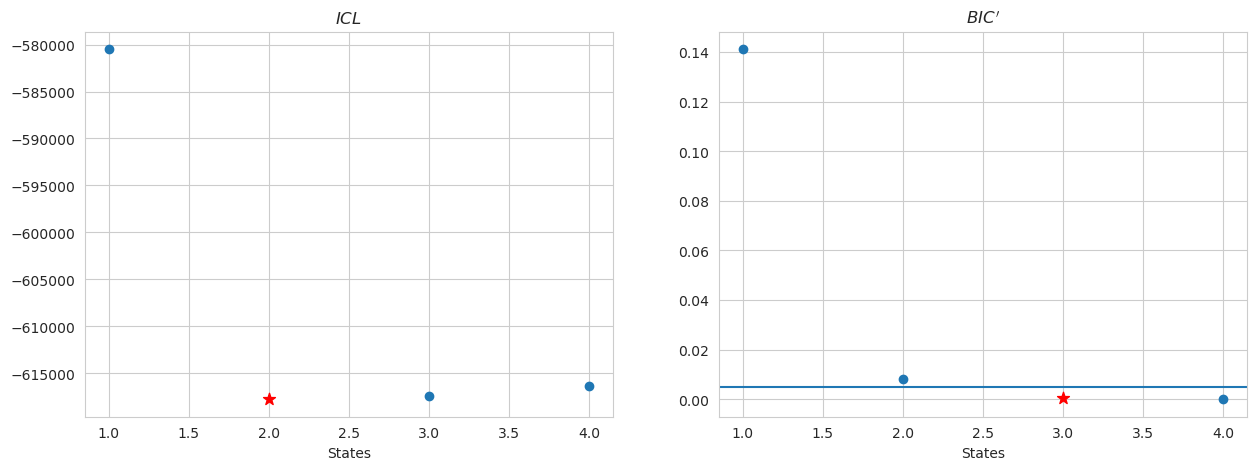

In [50]:
# h_da2_beg_time = time.perf_counter()
h_da2_beg_time = time.perf_counter()

# ph_index_da_2, ph_time_da_2, ph_nanotime_da_2 = data_sort(d_da, nchan=2) # this extracts the data for the da spH2MM selection
# # set up lists to aggregate the results for each 
# h_mod_da_2 = []
# result_da_2 = []

# # we calculate the first 2 models before entering our ICL based while loop, 
# # the 1 state model is unnecessary, but fun to see, the 2 state model is the real initiator
# h_mod_da_2, result_da_2 = [], []

# # the loop repeats until 
# i = 0
# cont = True
# while cont:
#     if i >= len(h_modi_2):
#         h_modi_2.append(factory_h2mm_model(i+1,2))
#     h_mod_temp = EM_H2MM_C(h_modi_2[i],ph_index_da_2,ph_time_da_2,max_iter=7200,converged_min=conv_min)
#     result_temp = viterbi_sort(h_mod_temp,ph_index_da_2,ph_time_da_2)
#     h_mod_da_2.append(h_mod_temp), result_da_2.append(result_temp);
#     if i > 2:
#         icl_da_2 = np.array([result[0] for result in result_da_2])
#         cont = True if np.argmin(icl_da_2[1:]) == i-1 else False
#     i += 1

# model_da_2 = np.argmin(icl_da_2[1:]) + 1
# bicp_da_2 = calc_bicp(h_mod_da_2)
dbs['statepaths2'] = bhm.StatePath.optimize_models(
    data, dbs['bursts'].regate(g_da), 
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em')), 
    models=h_modi_2, # further experience indicates this rarely changes the result
    conv_crit="ICL", thresh=0.05, converged_min=conv_min)

dskip = ['S_raw', 'S_bg', 
         'NphAA_raw', 'NphAA_bg', 'NphDactive_raw', 'NphDactive_bg']
dbs['dwells2'] = [bhm.fretfactory.make_dwell_dict(sp, skip=dskip) 
                  for sp in dbs['statepaths2']]
bicp_da_2 = bhm.StatePath.BICp(dbs['statepaths2'], data)
icl_da_2 = np.array([bhm.StatePath.ICL(sp, data) for sp in dbs['statepaths2']])

# h_da2_end_time = time.perf_counter()
# printtime(h_da2_beg_time,h_da2_end_time,f'Donor active spH2MM optimization for 1 to {i} states took: ')
h_da2_end_time = time.perf_counter()
printtime(h_da2_beg_time,h_da2_end_time,f'Donor active spH2MM optimization for 1 to {icl_da_2.size} states took: ')


# printtime(h_da2_beg_time,h_da2_end_time,f'Donor active spH2MM optimization for 1 to {i} states took: ')

# # now an automatic plotting script so we can compare ICL and BIC' values
# state_list = [h_mod.nstate for h_mod in h_mod_da_2]
# tic_type = []
# tic_col = []
# tic_size = []
# for icl in icl_da_2:
#     if icl == np.min(icl_da_2[1:]):
#         tic_type.append('*')
#         tic_col.append('r')
#         tic_size.append(100)
#     else:
#         tic_type.append('o')
#         tic_col.append('b')
#         tic_size.append(50)

# fig, ax = plt.subplots(1,2,figsize=(15,5))
# for x, icl, bic, m, c, sz in zip(state_list,icl_da_2, bicp_da_2,tic_type,tic_col,tic_size):
#     ax[0].scatter(x,icl,marker=m,color=c,s=sz)
#     ax[1].scatter(x,bic,marker=m,color=c,s=sz)
# ax[0].set_xticks(state_list)
# ax[0].set_title('ICL')
# ax[1].axhline(bicp_min)
# ax[1].set_xticks(state_list)
# ax[1].set_title("BIC'")
fig, ax = plt.subplots(1,2,figsize=(15,5))
bhm.plot.scatter_ICL(data, dbs['statepaths2'], ax=ax[0])
bhm.plot.scatter_BICp(data, dbs['statepaths2'], ax=ax[1])
bicmin_da_2 = np.argwhere(bicp_da_2 < bicp_min)[0,0]
iclmin_da_2 = np.argmin(icl_da_2)
ax[1].axhline(bicp_min)

Based on the ICL, the 2 state model is the best, while BIC' predicts the 3 state model.
Generally ICL is a better measure, however, it does favor slower transition rates, so both models should be considered.

In [51]:
# da_2_res = ES_summary(h_mod_da_2[model_da_2],result_da_2[model_da_2],d_da,ph_min=5,dwell_min=10)
da2_res = bhm.fretfactory.summary_frame(data, dbs['statepaths2'][1], ph_min=5)
# in the original notebook, the maximum theoretical rate was computed
# by ES_summary, now we will make the computation explicit,
# since the threshold is somewhat arbitrary, to be a valid transition rate, 
# the requirement is to be 10 times slower than the maximal photon rate
mrate = smf.Column(dbs['bursts'], 'max_rate', (smf.PhSel('0ex'), 10))
max_ratedbs2 = data.get_column(mrate).max()/ 10
bhm.fretfactory.highlight_rateframe(da2_res, data=data, 
                                    statepath=dbs['statepaths2'][iclmin_da_2],
                                    max_rate=max_ratedbs2, min_dwells=10)

,E h2mm,E vit,E err,to state 0,to state 1,num mid transistion to state 0,num mid transistion to state 1
0,0.627139,0.635593,0.111824,19999637.910248,362.089752,0,976
1,0.108971,0.114766,0.060135,124.738761,19999875.261239,478,0


*The cell bellow shows the 3 state model, as selected by BIC'*

In [52]:
# ES_summary(h_mod_da_2[2],result_da_2[2],d_da,ph_min=5,dwell_min=10)
da2_bicres = bhm.fretfactory.summary_frame(data, dbs['statepaths2'][2], ph_min=5)
bhm.fretfactory.highlight_rateframe(da2_bicres, data=data,
                                    statepath=dbs['statepaths2'][bicmin_da_2],
                                    max_rate=max_ratedbs2, min_dwells=10)

,E h2mm,E vit,E err,to state 0,to state 1,to state 2,num mid transistion to state 0,num mid transistion to state 1,num mid transistion to state 2
0,0.673140,0.677878,0.099379,19999546.112407,433.513354,20.374239,0,819,34
1,0.191953,0.200182,0.061476,230.317714,19999665.084395,104.597891,482,0,53
2,0.074956,0.082735,0.034524,13.115720,109.084848,19999877.799433,1,5,0


*new to this notebook for easier modification*
We now set our choice for plotting to the `sel_da_2` variable:

In [53]:
sel_da_2 = iclmin_da_2

<a id='2p_da_h2mm'></a>
### 2 Parameter H<sup>2</sup>MM of Donor Active population

The model converged after 1 iterations
The model converged after 79 iterations
The model converged after 140 iterations
The model converged after 192 iterations
The model converged after 1189 iterations
Donor active mpH2MM optimization for 1 to 5 states took:  0h 5m 17.0616s to run


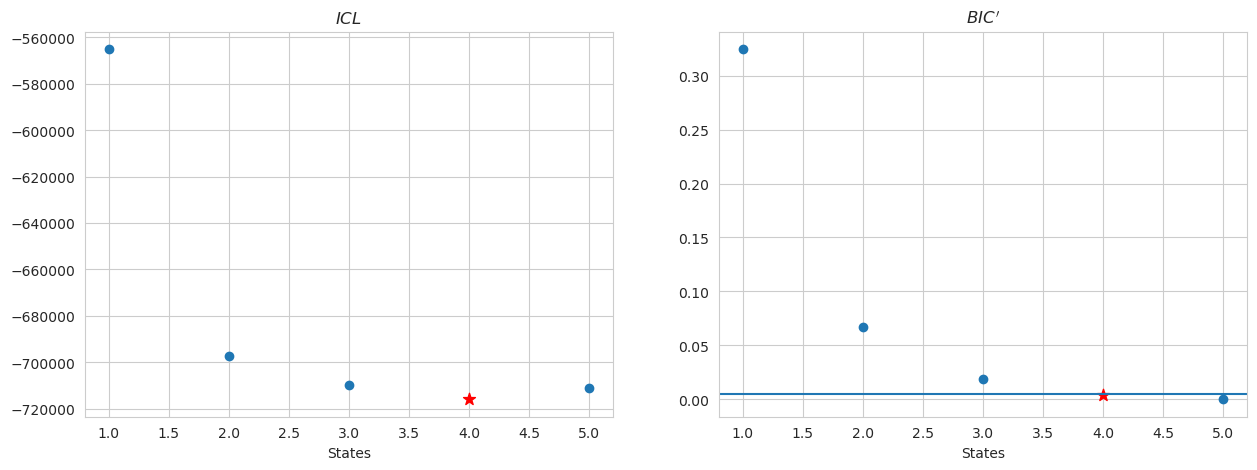

In [54]:
# h_da3_beg_time = time.perf_counter()
h_da3_beg_time = time.perf_counter()
# ph_index_da_3, ph_time_da_3, ph_nanotime_da_3 = data_sort(d_da, nchan=3) # this extracts the data for the da spH2MM selection
# # set up lists to aggregate the results for each 
# h_mod_da_3 = []
# result_da_3 = []

# # Setup some the model and results lists
# h_mod_da_3, result_da_3 = [], []

# # the loop repeats until 
# i = 0
# cont = True
# while cont:
#     if i >= len(h_modi_3):
#         h_modi_3.append(factory_h2mm_model(i+1,3))
#     h_mod_temp = EM_H2MM_C(h_modi_3[i],ph_index_da_3,ph_time_da_3,max_iter=7200,converged_min=conv_min)
#     result_temp = viterbi_sort(h_mod_temp,ph_index_da_3,ph_time_da_3)
#     h_mod_da_3.append(h_mod_temp), result_da_3.append(result_temp);
#     # start checking if model converged when the 4 state model is evaluated
#     if i > 2:
#         icl_da_3 = np.array([result[0] for result in result_da_3])
#         cont = False if np.argmin(icl_da_3[1:]) != i-1 else True
#     i += 1

# model_da_3 = np.argmin(icl_da_3[1:]) + 1

# bicp_da_3 = calc_bicp(h_mod_da_3)
dbs['statepaths3'] = da3_statepath = bhm.StatePath.optimize_models(
    data, dbs['bursts'].regate(g_da), 
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')), 
    models=h_modi_3, # not necessary, we find minimal impact from initial model
    conv_crit="ICL", thresh=0.05, converged_min=conv_min)
dbs['dwells3'] = [bhm.fretfactory.make_dwell_dict(sp) 
                  for sp in dbs['statepaths3']]

bicp_da_3 = bhm.StatePath.BICp(dbs['statepaths3'], data)
icl_da_3 = np.array([bhm.StatePath.ICL(sp, data) for sp in dbs['statepaths3']])

# h_da3_end_time = time.perf_counter()
# printtime(h_da3_beg_time,h_da3_end_time,f'Donor active mpH2MM optimization for 1 to {i} states took: ')
h_da3_end_time = time.perf_counter()
printtime(h_da3_beg_time,h_da3_end_time,
          f'Donor active mpH2MM optimization for 1 to {icl_da_3.size} states took: ')

# # now an automatic plotting script so we can compare ICL and BIC' values
# state_list = [h_mod.nstate for h_mod in h_mod_da_3]
# tic_type = []
# tic_col = []
# tic_size = []
# for icl in icl_da_3:
#     if icl == np.min(icl_da_3[1:]):
#         tic_type.append('*')
#         tic_col.append('r')
#         tic_size.append(100)
#     else:
#         tic_type.append('o')
#         tic_col.append('b')
#         tic_size.append(50)

# fig, ax = plt.subplots(1,2,figsize=(15,5))
# for x, icl, bic, m, c, sz in zip(state_list,icl_da_3, bicp_da_3,tic_type,tic_col,tic_size):
#     ax[0].scatter(x,icl,marker=m,color=c,s=sz)
#     ax[1].scatter(x,bic,marker=m,color=c,s=sz)
# ax[0].set_xticks(state_list)
# ax[0].set_title('ICL')
# ax[1].axhline(bicp_min)
# ax[1].set_xticks(state_list)
# ax[1].set_title("BIC'")
fig, ax = plt.subplots(1,2,figsize=(15,5))
bhm.plot.scatter_ICL(data, dbs['statepaths3'], ax=ax[0])
bhm.plot.scatter_BICp(data, dbs['statepaths3'], ax=ax[1])
bicmin_da_3 = np.argwhere(bicp_da_3 < bicp_min)[0,0]
iclmin_da_3 = np.argmin(icl_da_3)
ax[1].axhline(bicp_min)

Based on the ICL, the 4 state model is the best descriptor of the data for the mpH<sup>2</sup>MM data. This is inconsistent with the spH<sup>2</sup>MM. How are the models different? What did the additional photon stream allow the algorithm to find?

In [55]:
# da_3_res = ES_summary(h_mod_da_3[model_da_3],result_da_3[model_da_3],d_da,ph_min=5,dwell_min=10)
da3_res = bhm.fretfactory.summary_frame(data, dbs['statepaths3'][iclmin_da_3], ph_min=5)
mrate = smf.Column(dbs['bursts'], 'max_rate', (smf.PhSel('0ex_1ex1em'), 10))
max_ratedbs3 = data.get_column(mrate).max() / 10
bhm.fretfactory.highlight_rateframe(da3_res, data=data,
                                    statepath=dbs['statepaths3'][iclmin_da_3],
                                    max_rate=max_ratedbs3, min_dwells=10)

,E h2mm,S h2mm,E vit,S vit,E err,S err,to state 0,to state 1,to state 2,to state 3,num mid transistion to state 0,num mid transistion to state 1,num mid transistion to state 2,num mid transistion to state 3
0,0.476086,0.142061,0.477659,0.133263,0.185263,0.060522,19999226.130889,56.677198,187.625841,529.566072,0,48,437,625
1,0.660142,0.452334,0.653338,0.447083,0.103101,0.076626,21.902485,19999620.405572,18.944807,338.747135,14,0,52,466
2,0.074261,0.959834,0.075511,0.957326,0.043657,0.033024,56.933608,12.416394,19999752.020239,178.629759,280,58,0,656
3,0.169282,0.552646,0.175924,0.547406,0.072904,0.082153,135.933836,161.664851,140.101307,19999562.300006,384,385,500,0


*new to the notebook for clarity*
Now we set our selection to the ICL selection (wouldn't make a difference in this case)

In [56]:
sel_da_3 = iclmin_da_3

Now that we have chosen the ideal model, let's calculate the error bars:

In [57]:
# std_prior_da_3, std_trans_da_3, std_obs_da_3 = h2mm_std(h_mod_da_3[model_da_3],ph_index_da_3,ph_time_da_3,20,converged_min=conv_min)
err_da3 = bhm.error.BootStrapError.evaluate(data, 
                                            dbs['statepaths3'][sel_da_3], 
                                            n=20)

# for i in range(h_mod_da_3[model_da_3].nstate):
#     for j in range(h_mod_da_3[model_da_3].nstate):
#         print(f"Rate {i}->{j}: {h_mod_da_3[model_da_3].trans[i,j]:.4e}+/{std_trans_da_3[i,j]}")
for i, j in permutations(range(err_da3.nstate), 2):
    print(f'Rate {i}->{j}: {err_da3.model.trans[i,j]}+/-{err_da3.err_trans[i,j]}')

The model converged after 1268 iterations
The model converged after 350 iterations
The model converged after 319 iterations
The model converged after 649 iterations
The model converged after 361 iterations
The model converged after 491 iterations
The model converged after 1898 iterations
The model converged after 255 iterations
The model converged after 309 iterations
The model converged after 1823 iterations
The model converged after 285 iterations
The model converged after 217 iterations
The model converged after 459 iterations
The model converged after 284 iterations
The model converged after 318 iterations
The model converged after 591 iterations
The model converged after 222 iterations
The model converged after 530 iterations
Optimization reached maximum number of iterations
The model converged after 595 iterations
Rate 0->1: 2.833859902199059e-06+/-6.160488746604923e-07
Rate 0->2: 9.381292048648911e-06+/-1.833745856748845e-06
Rate 0->3: 2.6478303578558813e-05+/-1.4502116005659178

<a id='fret_h2mm'></a>
## FRET H<sup>2</sup>MM analysis
<a id='1p_fret_h2mm'></a>
### 1 Parameter Traditional H<sup>2</sup>MM of FRET population

The model converged after 1 iterations
The model converged after 127 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations
FRET spH2MM optimization for 1 to 4 states took:  0h 4m 9.9938s to run


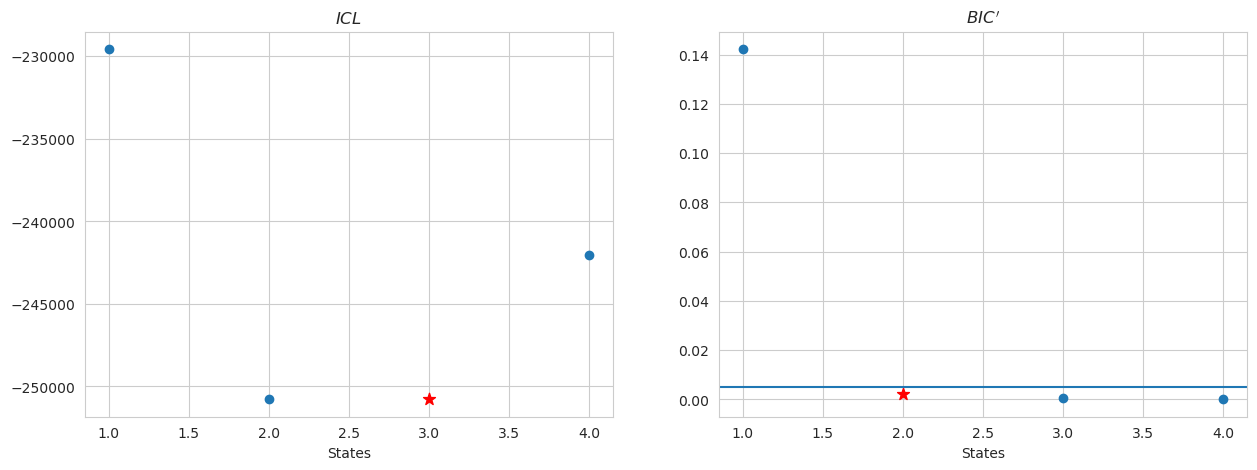

In [58]:
# h_fret2_beg_time = time.perf_counter()
h_fret2_beg_time = time.perf_counter()

# ph_index_fret_2, ph_time_fret_2, ph_nanotime_fret_2 = data_sort(d_fret, nchan=2) # this extracts the data for the da spH2MM selection
# # set up lists to aggregate the results for each 
# h_mod_fret_2 = []
# result_fret_2 = []

# # setup initial lists for storing models and viterbi results
# h_mod_fret_2, result_fret_2 = [], []

# # the loop repeats until 
# i = 0
# cont = True
# while cont:
#     if i >= len(h_modi_2):
#         h_modi_2.append(factory_h2mm_model(i+1,2))
#     h_mod_temp = EM_H2MM_C(h_modi_2[i],ph_index_fret_2,ph_time_fret_2,max_iter=7200,converged_min=conv_min)
#     result_temp = viterbi_sort(h_mod_temp,ph_index_fret_2,ph_time_fret_2)
#     h_mod_fret_2.append(h_mod_temp), result_fret_2.append(result_temp);
#     if i > 2:
#         icl_fret_2 = np.array([result[0] for result in result_fret_2])
#         cont = True if np.argmin(icl_fret_2[1:]) == i-1 else False
#     i += 1

# model_fret_2 = np.argmin(icl_fret_2[1:]) + 1

# bicp_fret_2 = calc_bicp(h_mod_fret_2)
ddc['statepaths2'] = bhm.StatePath.optimize_models(
    data, ddc['bursts'].regate(g_dcfret), 
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em')), 
    models=h_modi_2, # further experience indicates this rarely changes the result
    conv_crit="ICL", thresh=0.05, converged_min=conv_min)
skip_cols = ['S_raw', 'S_bg', 'NphAA_raw', 'NphAA_bg', 'NphDactive_raw', 'NphDactive_bg']
ddc['dwells2'] = [bhm.fretfactory.make_dwell_dict(sp, skip=skip_cols)
                  for sp in ddc['statepaths2']]
bicp_dc_2 = bhm.StatePath.BICp(ddc['statepaths2'], data)
icl_dc_2 = np.array([bhm.StatePath.ICL(sp, data) for sp in ddc['statepaths2']])

# h_fret2_end_time = time.perf_counter()
# printtime(h_fret2_beg_time,h_fret2_end_time,f'FRET spH2MM optimization for 1 to {i} states took: ')
h_fret2_end_time = time.perf_counter()
printtime(h_fret2_beg_time,h_fret2_end_time,f'FRET spH2MM optimization for 1 to {icl_dc_2.size} states took: ')

# # now an automatic plotting script so we can compare ICL and BIC' values
# state_list = [h_mod.nstate for h_mod in h_mod_fret_2]
# tic_type = []
# tic_col = []
# tic_size = []
# for icl in icl_fret_2:
#     if icl == np.min(icl_fret_2[1:]):
#         tic_type.append('*')
#         tic_col.append('r')
#         tic_size.append(100)
#     else:
#         tic_type.append('o')
#         tic_col.append('b')
#         tic_size.append(50)
# fig, ax = plt.subplots(1,2,figsize=(15,5))
# for x, icl, bic, m, c, sz in zip(state_list,icl_fret_2, bicp_fret_2,tic_type,tic_col,tic_size):
#     ax[0].scatter(x,icl,marker=m,color=c,s=sz)
#     ax[1].scatter(x,bic,marker=m,color=c,s=sz)
# ax[0].set_xticks(state_list)
# ax[0].set_title('ICL')
# ax[1].axhline(bicp_min)
# ax[1].set_xticks(state_list)
# ax[1].set_title("BIC'")
fig, ax = plt.subplots(1,2,figsize=(15,5))
bhm.plot.scatter_ICL(data, ddc['statepaths2'], ax=ax[0])
bhm.plot.scatter_BICp(data, ddc['statepaths2'], ax=ax[1])
bicmin_dc_2 = np.argwhere(bicp_dc_2 < bicp_min)[0,0]
iclmin_dc_2 = np.argmin(icl_dc_2)
ax[1].axhline(bicp_min)

For the DCBS search, both ICL and BIC' predict 2 and 3 states, 
but the difference in ICL between 2 and 3 states is very small, so it is most likely that the 2 state model is ideal.
But we will check both:

In [59]:
# fret_2_res = ES_summary(h_mod_fret_2[model_fret_2],result_fret_2[model_fret_2],d_fret,ph_min=5,dwell_min=10)
fret2_res = bhm.fretfactory.summary_frame(data, ddc['statepaths2'][iclmin_dc_2], ph_min=5)
max_ratefret2 = data.get_column(smf.Column(ddc['bursts'], 'max_rate', (smf.PhSel('0ex'), 10))).max() / 10
bhm.fretfactory.highlight_rateframe(fret2_res, data=data,
                                    statepath=ddc['statepaths2'][iclmin_dc_2],
                                    max_rate=max_ratefret2, min_dwells=10)

,E h2mm,E vit,E err,to state 0,to state 1,to state 2,num mid transistion to state 0,num mid transistion to state 1,num mid transistion to state 2
0,0.242694,0.241797,0.088357,19999006.717184,788.201918,205.080898,0,415,3
1,0.692506,0.686136,0.095804,503.285480,19999357.326988,139.387533,281,0,353
2,0.147781,0.167800,0.059310,41.407207,86.203555,19999872.389238,0,70,0


In [60]:
# fret_2_res = ES_summary(h_mod_fret_2[model_fret_2],result_fret_2[model_fret_2],d_fret,ph_min=5,dwell_min=10)
fret2_res = bhm.fretfactory.summary_frame(data, ddc['statepaths2'][iclmin_dc_2], ph_min=5)
max_ratefret2 = data.get_column(smf.Column(ddc['bursts'], 'max_rate', (smf.PhSel('0ex'), 10))).max() / 10
bhm.fretfactory.highlight_rateframe(fret2_res, data=data,
                                    statepath=ddc['statepaths2'][bicmin_dc_2],
                                    max_rate=max_ratefret2, min_dwells=10)

,E h2mm,E vit,E err,to state 0,to state 1,to state 2,num mid transistion to state 0,num mid transistion to state 1,num mid transistion to state 2
0,0.242694,0.241797,0.088357,19999006.717184,788.201918,205.080898,0,415,3
1,0.692506,0.686136,0.095804,503.285480,19999357.326988,139.387533,281,0,353
2,0.147781,0.167800,0.059310,41.407207,86.203555,19999872.389238,0,70,0


*new to this notebook for clarity*
Since the bic was a better selection (and ICL was very close to 2 states)
we set the `sel_dc_2` variable to the `bicmin_dc_2`

In [61]:
sel_dc_2 = bicmin_dc_2

<a id='2p_fret_h2mm'></a>
### 2 Parameter H<sup>2</sup>MM of FRET population

The model converged after 1 iterations
The model converged after 145 iterations
The model converged after 149 iterations
The model converged after 222 iterations
The model converged after 1765 iterations
Optimization reached maximum number of iterations
FRET mpH2MM optimization for 1 to 6 states took:  0h 21m 2.5524s to run


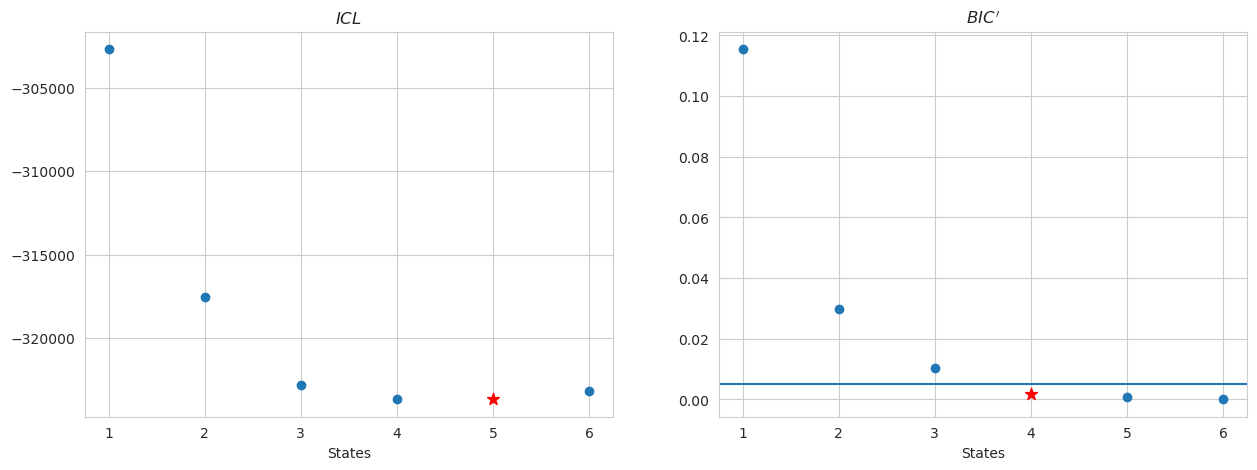

In [62]:
# h_fret3_beg_time = time.perf_counter()
h_fret3_beg_time = time.perf_counter()
# ph_index_fret_3, ph_time_fret_3, ph_nanotime_fret_3 = data_sort(d_fret, nchan=3) # this extracts the data for the da spH2MM selection
# # set up lists to aggregate the results for each 
# h_mod_fret_3 = []
# result_fret_3 = []

# # we calculate the first 2 models before entering our ICL based while loop, 
# # the 1 state model is unnecessary, but fun to see, the 2 state model is the real initiator
# h_mod_fret_3, result_fret_3 = [], []
# # the loop repeats until 
# i = 0
# cont = True
# while cont:
#     if i >= len(h_modi_3):
#         h_modi_3.append(factory_h2mm_model(i+1,3))
#     h_mod_temp = EM_H2MM_C(h_modi_3[i],ph_index_fret_3,ph_time_fret_3,max_iter=7200,converged_min=conv_min)
#     result_temp = viterbi_sort(h_mod_temp,ph_index_fret_3,ph_time_fret_3)
#     h_mod_fret_3.append(h_mod_temp), result_fret_3.append(result_temp);
#     if i > 2:
#         icl_fret_3 = np.array([result[0] for result in result_fret_3])
#         cont = False if np.argmin(icl_fret_3[1:]) != i-1 else True
#     i += 1


# model_fret_3 = np.argmin(icl_fret_3[1:]) + 1

# bicp_fret_3 = calc_bicp(h_mod_fret_3)
ddc['statepaths3'] = bhm.StatePath.optimize_models(
    data, ddc['bursts'].regate(g_dcfret), 
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')),
    models=h_modi_3, # further experience indicates this rarely changes the result
    conv_crit="ICL", thresh=0.05, converged_min=conv_min)
ddc['dwells3'] = [bhm.fretfactory.make_dwell_dict(sp) for sp in ddc['statepaths3']]
bicp_dc_3 = bhm.StatePath.BICp(ddc['statepaths3'], data)
icl_dc_3 = np.array([bhm.StatePath.ICL(sp, data) for sp in ddc['statepaths3']])

# h_fret3_end_time = time.perf_counter()
# printtime(h_fret3_beg_time,h_fret3_end_time,f'FRET mpH2MM optimization for 1 to {i} states took: ')
h_fret3_end_time = time.perf_counter()
msg = f'FRET mpH2MM optimization for 1 to {icl_dc_3.size} states took: '
printtime(h_fret3_beg_time,h_fret3_end_time, msg)

# # now an automatic plotting script so we can compare ICL and BIC' values
# state_list = [h_mod.nstate for h_mod in h_mod_fret_3]
# tic_type = []
# tic_col = []
# tic_size = []
# for icl in icl_fret_3:
#     if icl == np.min(icl_fret_3[1:]):
#         tic_type.append('*')
#         tic_col.append('r')
#         tic_size.append(100)
#     else:
#         tic_type.append('o')
#         tic_col.append('b')
#         tic_size.append(50)

# fig, ax = plt.subplots(1,2,figsize=(15,5))
# for x, icl, bic, m, c, sz in zip(state_list,icl_fret_3, bicp_fret_3,tic_type,tic_col,tic_size):
#     ax[0].scatter(x,icl,marker=m,color=c,s=sz)
#     ax[1].scatter(x,bic,marker=m,color=c,s=sz)
# ax[0].set_xticks(state_list)
# ax[0].set_title('ICL')
# ax[1].axhline(bicp_min)
# ax[1].set_xticks(state_list)
# ax[1].set_title("BIC'")
fig, ax = plt.subplots(1,2,figsize=(15,5))
bhm.plot.scatter_ICL(data, ddc['statepaths3'], ax=ax[0])
bhm.plot.scatter_BICp(data, ddc['statepaths3'], ax=ax[1])
bicmin_dc_3 = np.argwhere(bicp_dc_3 < bicp_min)[0,0]
iclmin_dc_3 = np.argmin(icl_dc_3)
ax[1].axhline(bicp_min)

Based on the $ICL$, the 5 state model (but 4 states is very close), while BIC' predicts 4 is the best descriptor of the data for the mpH<sup>2</sup>MM data. 

In other salt concentrations, we find that sometimes as few as 3 or 2 states are chosen with ICL or BIC.
Different Burst selections therefore influence the states found. 
By removing the Donor Active bursts with DCBS, there is sometimes not a significant enough proportion of these bursts or states for mpH<sup>2</sup>MM to detect, 
thus removing that state from the ideal selection.

In [63]:
# fret_3_res = ES_summary(h_mod_fret_3[model_fret_3],result_fret_3[model_fret_3],d_fret,ph_min=5,dwell_min=10)
fret3_res = bhm.fretfactory.summary_frame(data, ddc['statepaths3'][iclmin_dc_3], ph_min=5)
mrate = smf.Column(ddc['bursts'], 'max_rate', (smf.PhSel('0ex_1ex1em'), 10))
max_ratefret3 = data.get_column(mrate).max() / 10
bhm.fretfactory.highlight_rateframe(fret3_res, data=data,
                                    statepath=ddc['statepaths3'][iclmin_dc_3],
                                    max_rate=max_ratefret3, min_dwells=10)

,E h2mm,S h2mm,E vit,S vit,E err,S err,to state 0,to state 1,to state 2,to state 3,to state 4,num mid transistion to state 0,num mid transistion to state 1,num mid transistion to state 2,num mid transistion to state 3,num mid transistion to state 4
0,0.153458,0.645990,0.144343,0.678299,0.075777,0.077936,19998862.536855,338.243283,319.111788,301.761339,178.346735,0,161,207,208,28
1,0.440347,0.169204,0.422709,0.149024,0.172335,0.068942,637.202493,19998729.488151,181.935861,129.111701,322.261794,91,0,76,22,68
2,0.075958,0.962412,0.073127,0.966026,0.057045,0.034438,883.525715,109.175037,19998950.340592,56.958330,0.000326,221,64,0,45,7
3,0.665355,0.452029,0.654198,0.449576,0.099663,0.069790,178.984314,25.187514,13.989896,19999622.559927,159.278349,82,6,33,0,211
4,0.175643,0.512137,0.183455,0.524703,0.062971,0.065201,94.552953,47.737920,0.000015,122.305632,19999735.403479,1,21,2,91,0


In [64]:
# ES_summary(h_mod_fret_3[2],result_fret_3[2],d_fret,ph_min=5,dwell_min=10);
fret3_res1 = bhm.fretfactory.summary_frame(data, ddc['statepaths3'][3], ph_min=5)
bhm.fretfactory.highlight_rateframe(fret3_res1, data=data,
                                    statepath=ddc['statepaths3'][bicmin_dc_3],
                                    max_rate=max_ratefret3, min_dwells=10)

,E h2mm,S h2mm,E vit,S vit,E err,S err,to state 0,to state 1,to state 2,to state 3,num mid transistion to state 0,num mid transistion to state 1,num mid transistion to state 2,num mid transistion to state 3
0,0.442047,0.171387,0.430761,0.146049,0.187109,0.067090,19998568.996314,231.841175,126.059068,1073.103443,0,91,16,220
1,0.085006,0.933357,0.079386,0.944225,0.057757,0.046587,174.190813,19999178.192007,141.965894,505.651286,80,0,102,235
2,0.665121,0.452808,0.654557,0.447042,0.102150,0.070498,25.984269,41.460398,19999622.106094,310.449239,6,54,0,374
3,0.169683,0.541448,0.176597,0.537396,0.063941,0.070687,148.729004,73.788109,163.616920,19999613.865968,150,109,276,0


*new to this notebook for clarity*

In [65]:
sel_dc_3 = bicmin_dc_3

Now that we have chosen the ideal model, let's calculate the error bars:

In [66]:
# std_prior_fret_3, std_trans_fret_3, std_obs_fret_3 = h2mm_std(h_mod_fret_3[model_fret_3],ph_index_fret_3,ph_time_fret_3, 20, converged_min=conv_min)
err_dc3 = bhm.error.BootStrapError.evaluate(data, dbs['statepaths3'][sel_dc_3], n=20)

# for i in range(h_mod_da_3[model_fret_3].nstate):
#     for j in range(h_mod_fret_3[model_fret_3].nstate):
#         print(f"Rate {i}->{j}: {h_mod_fret_3[model_fret_3].trans[i,j]:.4e}+/{std_trans_fret_3[i,j]}")
for i, j in permutations(range(err_dc3.nstate), 2):
    print(f'Rate {i}->{j}: {err_dc3.model.trans[i,j]}+/-{err_dc3.err_trans[i,j]}')

The model converged after 1268 iterations
The model converged after 344 iterations
The model converged after 319 iterations
The model converged after 636 iterations
The model converged after 369 iterations
The model converged after 469 iterations
The model converged after 1833 iterations
The model converged after 255 iterations
The model converged after 306 iterations
The model converged after 1830 iterations
The model converged after 285 iterations
The model converged after 219 iterations
The model converged after 479 iterations
The model converged after 286 iterations
The model converged after 316 iterations
The model converged after 591 iterations
The model converged after 228 iterations
The model converged after 532 iterations
The model converged after 1944 iterations
The model converged after 615 iterations
Rate 0->1: 2.833859902199059e-06+/-6.160487898606345e-07
Rate 0->2: 9.381292048648911e-06+/-1.8337459546606854e-06
Rate 0->3: 2.6478303578558813e-05+/-1.4502118556668436e-06
Ra

Before we go, let's see how long the entire process has take so far:

In [67]:
# h2mm_time = time.perf_counter()
# printtime(begin, h2mm_time,'The entire analysis up to this point has taken: ')
h2mm_time = time.perf_counter()
printtime(begin, h2mm_time,'The entire analysis up to this point has taken: ')

The entire analysis up to this point has taken:  1h 61m 59.0985s to run


<a id='examineresults'></a>
# Examining the Results

<s>First some function definitions to help with plotting.</s>

These functions are no longer necessary as they are either implemented directly in `smfBursts` or `H2MMbursts`.

In [68]:
# def nanosort(path,post,index,nanotime,post_min):
#     # get the number of streams and number of states in the data
#     num_streams = 0
#     for idx in index:
#         if np.max(idx) + 1 > num_streams:
#             num_streams = np.max(idx).astype('l') + 1
#     num_states = 0
#     for st in path:
#         if np.max(st) + 1 > num_states:
#             num_states = np.max(st).astype('l') + 1
#     # initiate the lists to store the 
#     state_nanotimes = [[np.empty((0),dtype=int) for j in range(num_streams)] for i in range(num_states)]
#     for state in range(num_states):
#         for stream in range(num_streams):
#             for pa, pr, idx,  nt in zip(path,post,index,nanotime):
#                 mask = (pa == state) & (idx == stream) & (pr > post_min)
#                 state_nanotimes[state][stream] = np.append(state_nanotimes[state][stream],nt[mask])
#     return state_nanotimes

In [69]:
# def place_arrow(ax,x1,y1,x2,y2,r1,r2):
#     xdelta, ydelta = x2 - x1, y2 - y1
#     scale = np.sqrt(xdelta**2+ydelta**2)
#     xshift, yshift = -0.01*ydelta/scale, 0.01*xdelta/scale
#     xanno1, yanno1 = x1 + xdelta/2 + 4*xshift, y1 + ydelta/2 + 4*yshift
#     xanno2, yanno2 = x1 + xdelta/2 - 4*xshift, y1 + ydelta/2 - 4*yshift
#     rate1 = '%3.f'%r1
#     rate2 = '%3.f'%r2
#     ax.text(xanno1,yanno1,rate1,fontsize=18,ha='center',va='center',fontweight='bold')
#     ax.text(xanno2,yanno2,rate2,fontsize=18,ha='center',va='center',fontweight='bold')
#     ax.arrow(x1+xshift,y1+yshift,xdelta,ydelta,head_width=0.02,head_length=0.05,head_starts_at_zero=False,length_includes_head=True,color='k')
#     ax.arrow(x2-xshift,y2-yshift,-xdelta,-ydelta,head_width=0.02,head_length=0.05,head_starts_at_zero=False,length_includes_head=True,color='k')

In [70]:
# def stick_plot(ES,path,index,time,clk_p,color,b_color,axE,axS,tick_pos='right',bar_width=0.005):
#     """ Function for making photon stick plots"""
#     tm = (time - time[0]) *clk_p*1000
#     E_path = np.zeros(path.shape,dtype=float)
#     S_path = np.zeros(path.shape,dtype=float)
#     EB_path = np.zeros(path.shape,dtype=float)
#     SB_path = 0.5*np.ones(path.shape,dtype=float)
#     EB_color = []
#     SB_color = []
#     for i in range(path.shape[0]):
#         E_path[i] = ES[path[i],0]
#         S_path[i] = ES[path[i],1]
#         if index[i] == 0:
#             EB_path[i] = -0.5
#             SB_path[i] = 0.5
#             EB_color.append(color[2]) # change to clr[2] to make green, the more traditional color
#             SB_color.append(color[2])
#         elif index[i] == 1:
#             EB_path[i] = 0.5
#             SB_path[i] = 0.5
#             EB_color.append(clr[7]) # change to clr[7] to make red, the more traditional color
#             SB_color.append(clr[7])
#         else:
#             EB_path[i] = 0.0
#             SB_path[i] = -0.5
#             EB_color.append(clr[6])
#             SB_color.append(clr[5])
#     E_point = np.array([tm,E_path]).T.reshape(-1,1,2)
#     E_seg = np.concatenate([E_point[:-1],E_point[1:]],axis=1)
#     S_point = np.array([tm,S_path]).T.reshape(-1,1,2)
#     S_seg = np.concatenate([S_point[:-1],S_point[1:]],axis=1)
#     path_color = [clr[i0] if i0 == i1 else '#aaaaaa' for i0, i1 in zip(path[:-1],path[1:])]
#     E_lc = LineCollection(E_seg)
#     E_lc.set_color(path_color)
#     E_lc.set_linewidth(4.0)
#     S_lc = LineCollection(S_seg)
#     S_lc.set_color(path_color)
#     S_lc.set_linewidth(4.0)
#     axE.bar(tm,EB_path,bottom=0.5,color=EB_color,width=bar_width,linewidth=0)
#     axE.add_collection(E_lc)
#     axS.bar(tm,SB_path,bottom=0.5,color=SB_color,width=bar_width,linewidth=0)
#     axS.add_collection(S_lc)
#     axE.set_yticks([0.00,0.25,0.5,0.75,1.00])
#     axS.set_yticks([0.00,0.25,0.5,0.75])
#     axE.yaxis.set_label_position(tick_pos)
#     axS.yaxis.set_label_position(tick_pos)
#     axE.set_ylabel('$E_{raw}$',fontsize=18)
#     axS.set_ylabel('$S_{raw}$',fontsize=18)
#     axS.set_xlabel('ms',fontsize=18)
#     axE.tick_params(labelsize=16)
#     axS.tick_params(labelsize=16)
#     axE.spines['left'].set_color(b_color)
#     axE.spines['right'].set_color(b_color)
#     axS.spines['left'].set_color(b_color)
#     axS.spines['right'].set_color(b_color)
#     axE.spines['top'].set_color(b_color)
#     axS.spines['bottom'].set_color(b_color)

In [71]:
def name_order_states(statepath:smf.Param)->tuple[list[str],list[int]]:
    """
    This function automatically orders the states.
    It's use is custom to the HP3 system, and assumes no more than 4 states.
    """
    model = statepath.params['model']
    e = model.obs[:,1] / model.obs[:,:2].sum(axis=1)
    a = model.obs[:,2]
    loc_donly = np.argwhere(0.3 > a).reshape(-1)
    loc_aonly = np.argwhere(0.7 < a).reshape(-1)
    loc_fret = np.argwhere((0.7 > a) & (a > 0.3)).reshape(-1)
    loc_fret = loc_fret if e[loc_fret[0]] < e[loc_fret[1]] else loc_fret[::-1]
    state_order = np.concatenate([loc_fret, loc_donly, loc_aonly])
    state_names = ['Open', 'Closed'][:loc_fret.size] + ['Donor Only']*loc_donly.size + ['Acceptor Only']*loc_aonly.size
    return [state_names[i] for i in np.argsort(state_order)], state_order


@smf.datamodel.utils.fnumba.jit('Tuple((i8, i8))(u1[:], u1[:])')
def num_trans(path, fwbk):
    nmax, n, ntrans, instreak = 0, 0, 0, False
    for i in fwbk:
            if i == path[0]:
                n = 1
                break
    for sp, sf in zip(path[:-1], path[1:]):
        if sp == sf:
            continue
        ntrans += 1
        instate = False
        for i in fwbk:
            if i == sf:
                instate = True
        if instreak:
            if instate:
                n += 1
            else:
                if n > nmax:
                    nmax = n
        elif instate:
            n = 0
        instreak = instate
    return nmax, ntrans


def burst_mostT_fret(data, statepath):
    statepaths = data.get_column(smf.Column(statepath, 'statepath'))
    durs = data.get_column(smf.Column(statepath.parents['bursts'], 'dur'))
    model = statepath.params['model']
    e = model.obs[:,1] / model.obs[:,:2].sum(axis=1)
    a = model.obs[:,2]
    loc_fret = np.argwhere((0.3 < a)& (a < 0.7)).reshape(-1).astype(np.uint8)
    return [n[-1] for n in sorted((num_trans(sp, loc_fret)+(d, i) 
                                   for i, (sp, d) in enumerate(zip(statepaths, durs))), reverse=True)]


def burst_longest_category(data, statepath, bcodes):
    gate = smf.make_isin_gate(smf.Column(statepath, 'bstates'), bcodes)
    durs = data.get_column(smf.Column(statepath.parents['bursts'], 'dur'), gate=gate&statepath.base_gate)
    mask = data.get_gategroup(gate, statepath.base_gate)
    return np.arange(mask.size)[mask][np.argsort(durs)]


def burst_representative_sort(data, *args, gate=None, as_log=None, factor=None):
    as_log = np.zeros(len(args), dtype=np.bool_) if as_log is None else as_log
    factor = np.ones(len(args), dtype=np.float64) if factor is None else factor
    if gate is not None:
        args = tuple(arg.regate(gate) for arg in args)
    with np.errstate(divide='ignore'):
        xy = np.vstack([fac*(np.log(data.get_column(arg) if asl else data.get_column(arg))) 
                        for arg, asl, fac in zip(args, as_log, factor)])
    mask = np.isfinite(xy).sum(axis=0) == xy.shape[0]
    locs = np.argsort(gaussian_kde(xy[:,mask]).evaluate(xy[:,mask]))[::-1]
    return np.arange(xy.shape[1])[mask][locs]


def burst_nrepresentative(data:smf.photondata.PhotonDataS, statepath:smf.Param, n:int=5, state_order:list[int]=None)->list[int]:
    burst = statepath.parents['bursts']
    model = statepath.params['model']
    nstate = model.nstate
    state_order = np.arange(nstate) if state_order is None else np.asarray(state_order)
    # create columsn for finding representative burst
    nphdd = smf.Column(burst, 'nph_raw', smf.PhSel('0ex0em'))
    nphda = smf.Column(burst, 'nph_raw', smf.PhSel('0ex1em'))
    nphaa = smf.Column(burst, 'nph_raw', smf.PhSel('1ex1em'))
    dur = smf.Column(burst, 'dur')
    rep = burst_representative_sort(data, dur, nphdd, nphda, nphaa, 
                                    factor=[1e3, 1, 1, 1], as_log=[False, True, True, True])
    most = burst_mostT_fret(data, statepath)
    bstate = data.get_column(smf.Column(statepath, 'bstates'))
    if nstate**2 > n:
        bcodes = [[(np.bitwise_or.reduce([1<<state_order[i] for i in comb]), ) 
                   for comb in combinations(range(nstate), ns)] for ns in range(nstate, 0, -1)]
    else:
        bcodes = list(chain.from_iterable((((np.bitwise_or.reduce([1<<state_order[i] for i in comb]),),) 
                                           for comb in combinations(range(nstate), ns)) for ns in range(nstate, 0, -1)))
    out = [most[1],] if most[1] == rep[1] else [most[1], rep[1]]
    i = 0
    for bgroup in bcodes:
        if len(out) == n:
            break
        for bc in bcodes:
            if len(out) == n:
                break
            burst_l = burst_longest_category(data, statepath, bc)
            mask = ~np.isin(burst_l, out)
            if np.any(mask):
                out.append(burst_l[mask][0])
                continue
    return out

<a id='da_result'></a>
## Donor Active Burst Selection
Now we define a color sequence for display (this just makes things look good)

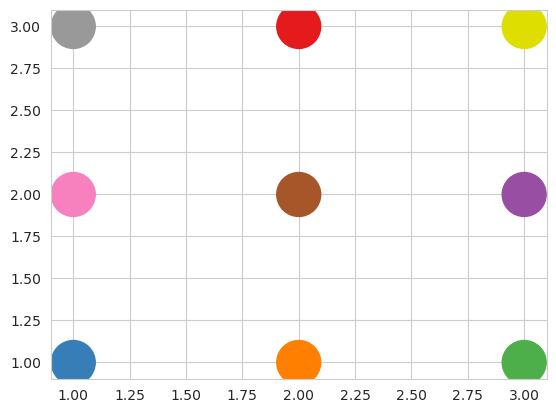

In [72]:
# clr = ['#377eb8', '#ff7f00', '#4daf4a','#f781bf', '#a65628', '#984ea3','#999999', '#e41a1c', '#dede00']
# plt.scatter([1,2,3,1,2,3,1,2,3],[1,1,1,2,2,2,3,3,3],c=clr,s=1000)
clr = ['#377eb8', '#ff7f00', '#4daf4a','#f781bf', '#a65628', '#984ea3','#999999', '#e41a1c', '#dede00']
cmap = ListedColormap(clr)
plt.scatter([1,2,3,1,2,3,1,2,3],[1,1,1,2,2,2,3,3,3],c=clr,s=1000)

### Preliminary Plot results
This lets us see the state, and then give them a name

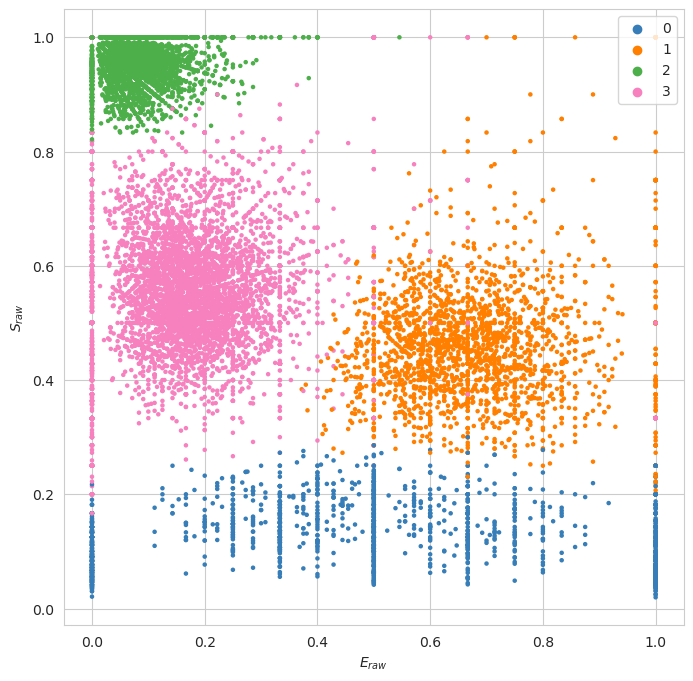

In [73]:
# plt.figure(figsize=(8,8))
# v_result = result_da_3[model_da_3]
# ph_counts = v_result[9]
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(ph_counts)
# for i in range(len(dwell_E)):
#     plt.scatter(dwell_E[i],dwell_S[i],color=clr[i],label=str(i))
# plt.legend()
d = dbs
modsel3 = sel_da_3

plt.figure(figsize=(8,8))
dwell_dict = d['dwells3'][modsel3]
smf.plot.scatter(data, dwell_dict['E_raw'], dwell_dict['S_raw'],
                 point_func=smf.plot.colorcategory, point_cols=dwell_dict['State'],
                 point_kwargs={'cmap':cmap, 'vmin':0, 'vmax':8}, s=5.0)
for i in range(dwell_dict['dwells'].statepath.model.nstate):
    plt.scatter(np.nan, np.nan, c=[cmap(i)], label=f'{i}')
plt.legend()

Now that the states are known (and the fitting makes sense), lets give them names.

Since this is working with a hairpin, it is known that the conformations are open and closed, and by the $S_{raw}$ value, the third state can be assigned to acceptor blinking

In [74]:
# state_names_da = ['Closed','dark D','Open', 'dark A']
# state_type_da_3 = {'Closed':0b0001,'Open':0b0100,'dark A':0b1000,'dark D':0b0010,
#               'Closed and Open':0b0101,'Closed and dark A':0b1001,'Closed and dark D':0b0011,
#               'Open and dark A':0b1100,'Open and dark D':0b0110,'dark A and dark D':0b1010,
#               'Closed, Open and dark A':0b1101,'Closed, Open and dark D':0b0111,'Closed, dark A, and dark D':0b1011,
#               'Open, dark A and dark D':0b1110,
#               'All':0b1111}
# for state in state_type_da_3:
#     state_type_da_3[state] = np.array(state_type_da_3[state]==result_da_3[model_da_3][4]).sum()
#     print('%-20s : %d' %(state,state_type_da_3[state]))
d = dbs
modsel3 = sel_da_3

state_names, state_order = name_order_states(d['statepaths3'][modsel3])

maxlen = sum(len(s) for s in sorted(state_names, key=lambda s: len(s), reverse=True)[:-1])
pfmt = f'%-{maxlen+5*len(state_names)-10}s : %d'
bstates = data.get_column(smf.Column(d['statepaths3'][modsel3], 'bstates'))
state_counts = np.bincount(bstates)
name_dct = list()
for cl in chain.from_iterable(combinations(enumerate(state_names), i) for i in range(1,len(state_names)+1)):
    idxs, names = zip(*cl)
    name = 'all' if len(names) == len(state_names) else ' and '.join(names)
    print(pfmt % (name, state_counts[sum(1<<i for i in idxs)]))

Acceptor Only                           : 1
Closed                                  : 379
Donor Only                              : 1053
Open                                    : 1187
Acceptor Only and Closed                : 13
Acceptor Only and Donor Only            : 207
Acceptor Only and Open                  : 273
Closed and Donor Only                   : 92
Closed and Open                         : 1028
Donor Only and Open                     : 1282
Acceptor Only and Closed and Donor Only : 27
Acceptor Only and Closed and Open       : 164
Acceptor Only and Donor Only and Open   : 678
Closed and Donor Only and Open          : 259
all                                     : 89


<a id='da_mainplot'></a>
## Plot information relevant to 2D E-S plots for Donor Active burst selection

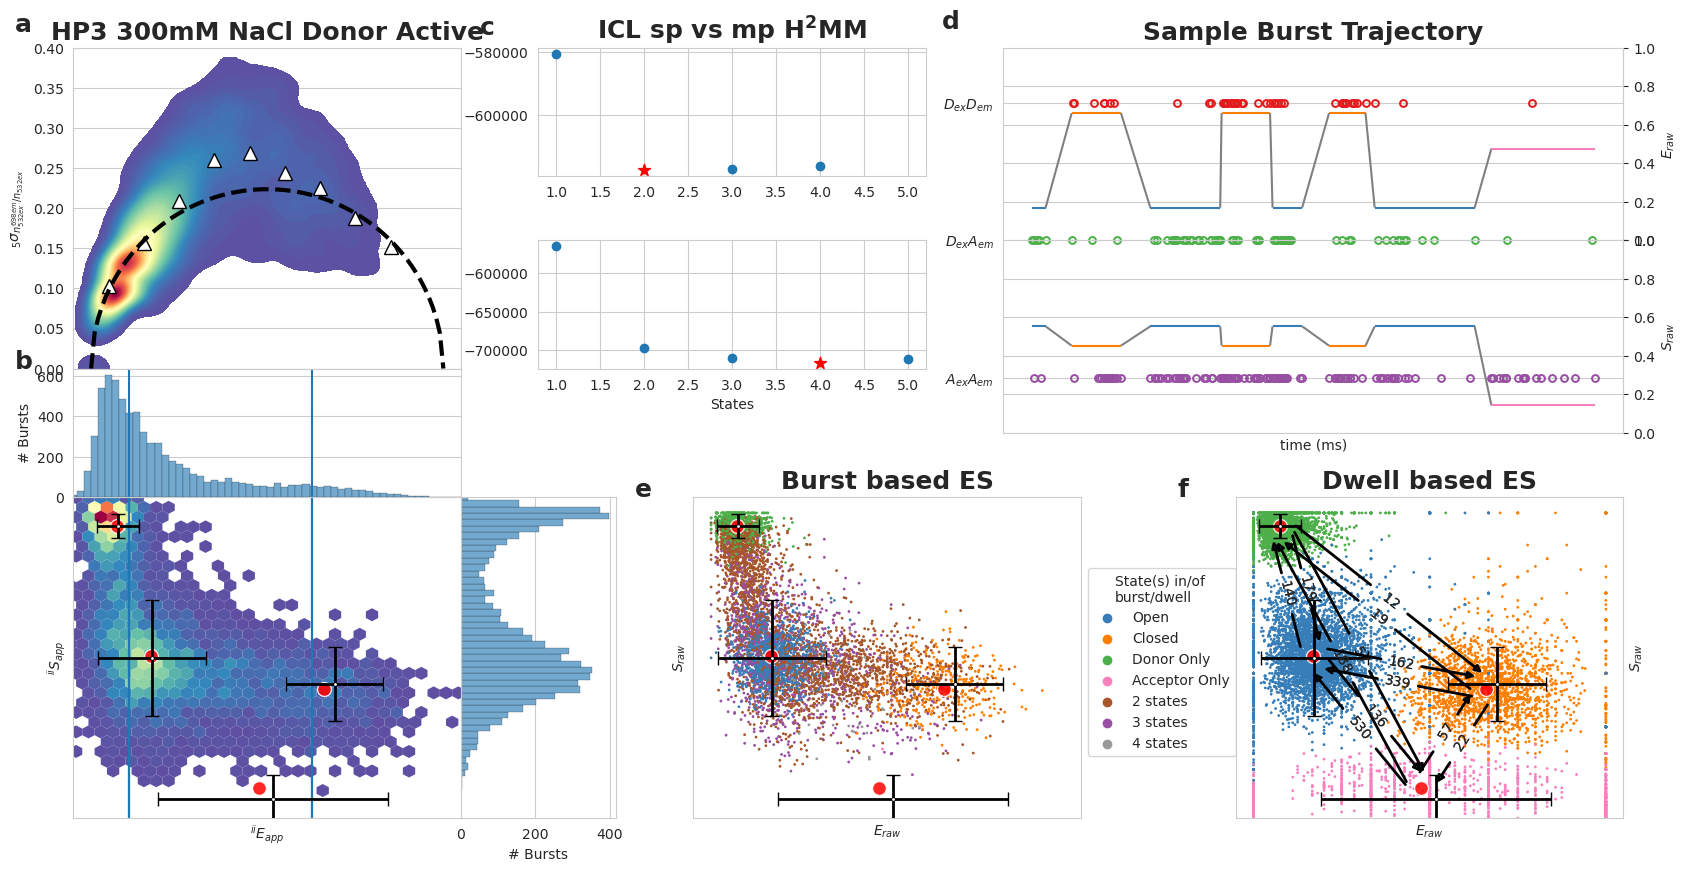

In [75]:
# pull out the relevant variables, makes the cell act like a function
# data = d_da
# ph_times = ph_time_da_3
# ph_indexes = ph_index_da_3
# h_mod = h_mod_da_3
# h_mod2 = h_mod_da_2
# c_result = result_da_2
# v_result = result_da_3
# mod_sel = model_da_3
# mod_sel2 = model_da_2
# # Non data settings
# state_names = state_names_da
# fname = filename.split('.hdf5')[0]
# plot_sel = 'Donor Active'
# fplot_sel = 'DA'
# brst = 55
# burst_marker_size = 5
# barwidth = 0.02
# plot_t = plot_title

# # now the automated stuff
# hmod = h_mod[mod_sel]
# hmod2 = h_mod2[mod_sel2]
# burst_class = []
# for i in range(hmod.nstate):
#     burst_class.append(state_names[i])
# if hmod.nstate > 3:
#     for i in range(2,hmod.nstate+1):
#         burst_class.append(str(i) + ' states')
# elif hmod.nstate == 3:
#     for i in range(hmod.nstate-1):
#         for j in range(i+1,hmod.nstate):
#             burst_class.append(state_names[i] + ' and ' + state_names[j])
# else:
#     burst_class.append('All states')

# # extract some values from the given variables
# clk_p = data.clk_p
# paths = v_result[mod_sel][1]
# brst_type = v_result[mod_sel][4]
# ph_counts = v_result[mod_sel][9]
# icl_2 = np.array([icl[0] for icl in c_result])
# icl_3 = np.array([icl[0] for icl in v_result])
# icl2_states = np.array([model.nstate for model in h_mod2])
# icl3_states = np.array([model.nstate for model in h_mod])
# plot_ttle = plot_t + ' ' + plot_sel

# # get needed bursts for photon stick plot
# ph_time = ph_times[brst]
# ph_index = ph_indexes[brst]
# path = paths[brst]

# # Get the BVA and ES values calculated
# E_vals, std_vals, std_vals1, bn_vals = BVA(data, 5, 20, 40)
# trans, ES_vals = get_ES(hmod,clk_p)
# trans2, ES_vals2 = get_ES(hmod2,clk_p)
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(ph_counts)

# # get the selected burst trajectory for photon stickplot
# E_path = np.zeros(path.shape,dtype=float)
# S_path = np.zeros(path.shape,dtype=float)
# EB_path = np.zeros(path.shape,dtype=float)
# SB_path = 0.5*np.ones(path.shape,dtype=float)
# ph_tm = (ph_time - ph_time[0])*clk_p*1000
# EB_color = []
# SB_color = []
# for i in range(path.size):
#     E_path[i] = ES_vals[path[i],0]
#     S_path[i] = ES_vals[path[i],1]
#     if ph_index[i] == 0:
#         EB_path[i] = -0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[2]) # change to clr[2] to make green, the more traditional color
#         SB_color.append(clr[2])
#     elif ph_index[i] == 1:
#         EB_path[i] = 0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[7]) # change to clr[7] to make red, the more traditional color
#         SB_color.append(clr[7])
#     else:
#         EB_path[i] = 0.0
#         SB_path[i] = -0.5
#         EB_color.append(clr[6])
#         SB_color.append(clr[5])

# # make burst based E and S plots
# E1 = [(index == 1).sum()/(index < 2).sum() for index in ph_indexes]
# S1 = [(index < 2).sum()/index.size for index in ph_indexes]
# # make a list of colors for the scatterplot identifying each burst by number of transitions
# bc = []
# for i in range(brst_type.size):
#     idstr = bin(brst_type[i])[2:]
#     cnt = idstr.count('1')
#     if cnt == 1:
#         bc.append(clr[len(idstr)-1])
#     else:
#         if hmod.nstate > 3:
#             bc.append(clr[cnt+hmod.nstate-2])
#         else:
#             if idstr == '11':
#                 bc.append(clr[3])
#             elif idstr == '101':
#                 bc.append(clr[4])
#             elif idstr == '110':
#                 bc.append(clr[5])
#             else:
#                 bc.append(clr[6])
        
# # set up the figures subplots
# fig1 = plt.figure(figsize=(25,15))
# gs1 = gridspec.GridSpec(nrows=12,ncols=20,figure=fig1)
# plt.subplots_adjust(hspace=0, wspace=0)
# ax1 = []
# ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
# ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[0])) # 1D FRET histogram ax1[1]
# ax1.append(fig1.add_subplot(gs1[7:12,0:5],sharex=ax1[0])) # ES hexbin plot ax1[2]
# ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[2])) # S histogram ax1[3]
# ax1.append(fig1.add_subplot(gs1[0:2,6:11])) # 1pH2MM BIC' ax1[4]
# ax1.append(fig1.add_subplot(gs1[3:5,6:11])) # 2pH2MM BIC' ax1[5]
# ax1.append(fig1.add_subplot(gs1[0:3,12:20])) # E photon path ax1[6]
# ax1.append(fig1.add_subplot(gs1[3:6,12:20],sharex=ax1[6])) # S photon path ax1[7]
# ax1.append(fig1.add_subplot(gs1[7:12,8:13])) # Burst based E-S viterbi calssification ax1[8]
# ax1.append(fig1.add_subplot(gs1[7:12,15:20],sharey=ax1[8])) # Dwell based E-S viterbi classification ax1[9]

# # plotting the BVA plot
# im = sns.kdeplot(x=std_vals, y=E_vals,shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100, ax=ax1[0])
# ax1[0].scatter(bn_vals,std_vals1,marker='^',s=140,color='white',edgecolors='k',alpha=1)
# ax1[0].set_ylim([0,0.4])
# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# ax1[0].plot(x_T,y_T, lw=3, color='k', ls='--')
# ax1[0].set_ylabel('$\mathbf{\sigma_{E}^{*}}$',fontsize=18)

# # plotting the E and S histograms that surround the ES hexbin plot
# dplot(data,hist_fret,ax=ax1[1],pdf=False, weights=None, verbose=True)
# dplot(data,hist_burst_data, data_name='S',ax=ax1[3],vertical=True)
# dplot(data, hexbin_alex, ax=ax1[2])
# ax1[2].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[2].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# for i in range(h_mod2[mod_sel2].nstate):
#     ax1[1].axvline(ES_vals2[i])
#     ax1[2].axvline(ES_vals2[i])

# # set limits and labels on first column 
# ax1[0].set_yticks(np.arange(0.1,0.5,0.1))
# ax1[1].set_ylabel('# Bursts',fontsize=18,fontweight='bold')
# ax1[2].set_xlabel('$\mathbf{E_{raw}}$',fontsize=18,)
# ax1[2].set_ylabel('$\mathbf{S_{raw}}$',fontsize=18)
# ax1[2].set_yticks([0,0.2,0.4,0.6,0.8])
# ax1[0].set_xlim([0,1])
# ax1[0].set_title(plot_title,fontsize=18,fontweight='bold')
# ax1[0].tick_params(labelsize=16)
# ax1[1].tick_params(labelsize=16)
# ax1[2].tick_params(labelsize=16)
# ax1[3].tick_params(labelsize=16)
# ax1[2].set_ylim([0,1])
# ax1[0].text(-0.15,1.05,'a',fontsize=18,fontweight='bold',transform=ax1[0].transAxes)
# ax1[1].set_title(' ')
# ax1[2].set_title(' ')
# ax1[2].text(-0.15,1.0,'b',fontsize=18,fontweight='bold',transform=ax1[2].transAxes)
# ax1[3].set_title(' ')
# ax1[3].set_ylabel(' ')
# ax1[3].set_xlabel('# bursts',fontsize=18,fontweight='bold')
# plt.setp(ax1[3].get_yticklabels(), visible=False)

# # ICL plots
# icl_states = np.append(icl2_states,icl3_states)
# st_min, st_max = np.min(icl_states), np.max(icl_states)
# icl_min2, icl_min3 = icl2_states[np.argmin(icl_2)], icl3_states[np.argmin(icl_3)]
# for st, ic in zip(icl2_states, icl_2):
#     c = clr[7] if st == icl_min2 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_2[mod_sel2] else dict(marker='o',s=75)
#     ax1[4].scatter(st,ic,c=c,**pltkwargs)
# for st, ic in zip(icl3_states, icl_3):
#     c = clr[7] if st == icl_min3 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_3[mod_sel] else dict(marker='o',s=75)
#     ax1[5].scatter(st,ic,c=c,**pltkwargs)
# ax1[4].grid(axis='x')
# ax1[4].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[4].tick_params(labelsize=16)
# ax1[4].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[4].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[4].set_title("sp vs mp H$^2$MM",fontsize=18,fontweight='bold')
# ax1[4].text(-0.15,1.1,'c',fontsize=18,fontweight='bold',transform=ax1[4].transAxes)
# ax1[4].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].grid(axis='x')
# ax1[5].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[5].tick_params(labelsize=16)
# ax1[5].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[5].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[5].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].set_xlabel("Number of States",fontsize=18,fontweight='bold')

# # # plot photon path
# stick_plot(ES_vals,path,ph_index,ph_time,clk_p,clr,bc[brst],ax1[6],ax1[7],bar_width=0.03)
# ax1[6].set_title('Sample Burst Trajectory',fontsize=18,fontweight='bold')
# ax1[6].text(-0.15,1.1,'d',fontsize=18,fontweight='bold',transform=ax1[6].transAxes)

# leg =  [Line2D([0],[0],marker='o',color=clr[i],label=b_class,markerfacecolor=clr[i],markersize=10,ls='None') 
#         for i, b_class in enumerate(burst_class)]
# ax1[8].legend(handles=leg,title='State(s) in/of \nburst/dwell',bbox_to_anchor=(1.0,1.0))
# ax1[8].scatter(E1,S1,c=bc,s=burst_marker_size)
# ax1[8].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[8].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[8].set_title('Burst Based E-S',fontsize=18,fontweight='bold')
# ax1[8].set_ylim([0,1])
# ax1[8].text(-0.15,1.05,'e',fontsize=18, fontweight='bold',transform=ax1[8].transAxes)
# ax1[8].set_xlabel('$\mathbf{E_{raw}}$',fontsize=18)
# ax1[8].set_ylabel('$\mathbf{S_{raw}}$',fontsize=18)

# for i in range(hmod.nstate):
#     ax1[9].scatter(dwell_E[i],dwell_S[i],c=clr[i],s=burst_marker_size)
# ax1[9].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[9].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[9].set_title('Dwell Based E-S',fontsize=18,fontweight='bold')
# ax1[9].text(-0.15,1.05,'f',fontsize=18, fontweight='bold',transform=ax1[9].transAxes)
# ax1[9].set_xlabel('$\mathbf{E_{raw}}$',fontsize=18)
# ax1[9].set_ylabel('$\mathbf{S_{raw}}$',fontsize=18)
# ax1[9].yaxis.set_ticks_position("right")
# ax1[9].yaxis.set_label_position("right")
# # fig1.savefig('figures/'+fname+fplot_sel+'_summary_type0.pdf',format='pdf',bbox_inches='tight')

d = dbs
gate = g_da
modsel2 = sel_da_2
modsel3 = sel_da_3
title = "Donor Active"

brst_n = burst_mostT_fret(data, d['statepaths3'][modsel3])[0]

state_names, state_order = name_order_states(d['statepaths3'][modsel3])
dcmap, bcmap, nlist = bhm.plot.make_bstate_cmap(state_names, clr, order=state_order)
# set up the figures subplots
fig1 = plt.figure(figsize=(20,10))
gs1 = fig1.add_gridspec(12,20, hspace=0.0, wspace=0.0)
ax1 = list()
ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
ax1.append(fig1.add_subplot(gs1[7:12,0:5], sharex=ax1[0])) # ES hexbin plot ax1[1]
ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[1])) # 1D FRET histogram ax1[2]
ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[1])) # S histogram ax1[3]
ax1.append(fig1.add_subplot(gs1[0:2,6:11])) # 1pH2MM BIC' ax1[4]
ax1.append(fig1.add_subplot(gs1[3:5,6:11], sharex=ax1[4])) # 2pH2MM BIC' ax1[5]
ax1.append(fig1.add_subplot(gs1[0:6,12:20])) # Burst photon path ax1[6]
ax1.append(fig1.add_subplot(gs1[0:3,12:20],sharex=ax1[6])) # E state path ax1[7]
ax1.append(fig1.add_subplot(gs1[3:6,12:20],sharex=ax1[6])) # S state path ax1[8]
ax1.append(fig1.add_subplot(gs1[7:12,8:13], sharex=ax1[1], sharey=ax1[1])) # Burst based E-S viterbi calssification ax1[9]
ax1.append(fig1.add_subplot(gs1[7:12,15:20],sharex=ax1[1], sharey=ax1[1])) # Dwell based E-S viterbi classification ax1[10]

ax1[0].text(-0.15,1.05,'a',fontsize=18,fontweight='bold',transform=ax1[0].transAxes)
ax1[2].text(-0.15,1.0,'b',fontsize=18,fontweight='bold',transform=ax1[2].transAxes)
ax1[4].text(-0.15,1.1,'c',fontsize=18,fontweight='bold',transform=ax1[4].transAxes)
ax1[6].text(-0.10,1.05,'d',fontsize=18,fontweight='bold',transform=ax1[6].transAxes)
ax1[9].text(-0.15,1.00,'e',fontsize=18, fontweight='bold',transform=ax1[9].transAxes)
ax1[10].text(-0.15,1.00,'f',fontsize=18, fontweight='bold',transform=ax1[10].transAxes)


# plot BVA
ax1[0].set_title(f'{plot_title} {title}', fontsize=18,fontweight='bold')
smf.plot.plot_meaninterval(data, d['E_raw'], d['BVA5'], gate=gate, marker='^', 
                           color='white', ms=10, mew=1, mec='k', lw=0, 
                           bins=np.linspace(0,1,11), ax=ax1[0])
smf.plot.kdeplot(data, d['E_raw'], d['BVA5'], cmap='Spectral_r', gate=gate, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels, ax=ax1[0])
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_T*(1-x_T))/n)
ax1[0].plot(x_bva,y_bva, lw=3, color='k', ls='--')
ax1[0].set_ylim([0,0.4])
ax1[0].set_xlim([0, 1.0])


# plot burst ES
ax1[2].set_xticks([])
ax1[3].set_yticks([])
smf.plot.hexbin(data, d['E_bg'], d['S_bg'], gate=gate, ax=ax1[1], cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])
smf.plot.hist_bar(data, d['E_bg'], ax=ax1[2], gate=gate, xlabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
bhm.plot.hist_model(d['E_raw'], d['statepaths2'][modsel2], data, ax=ax1[1])
smf.plot.hist_bar(data, d['S_bg'], ax=ax1[3], gate=gate, orientation='horizontal', ylabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[2])
ax1[1].set_xlim([-0.05, 1.05])
ax1[1].set_ylim([0.05, 1.05])

# ICL plots
bhm.plot.scatter_ICL(data, d['statepaths2'], ax=ax1[4], title=False, xlabel=False)
bhm.plot.scatter_ICL(data, d['statepaths3'], ax=ax1[5], title=False)
ax1[4].set_title(r'ICL sp vs mp $\mathbf{H^{2}MM}$', fontsize=18,fontweight='bold')


# plot burst-H2MM categories
ax1[7].patch.set_alpha(0.0)
ax1[7].grid('off')
ax1[7].spines[['top','bottom','left']].set_visible(False)
ax1[7].yaxis.set_ticks_position('right')
ax1[7].yaxis.set_label_position('right')
ax1[7].set_xticks([])
ax1[8].patch.set_alpha(0.0)
ax1[8].grid('off')
ax1[8].spines[['top','bottom','left']].set_visible(False)
ax1[8].yaxis.set_ticks_position('right')
ax1[8].yaxis.set_label_position('right')
ax1[8].set_xticks([])
smf.plot.burst_dets(data, d['bursts'].regate(gate), brst_n, ax=ax1[6], rescale=-3, zerostart=True,
                    det_pos={smf.PhSel('0ex0em'):1.0, smf.PhSel('0ex1em'):2.0, smf.PhSel('1ex1em'):0.0}, 
                    det_kwargs={smf.PhSel('0ex0em'):{'ec':'#4daf4a', 'fc':((0x4d/0xff,0xaf/0xff,0x4a/0xff, 0.2),)}, 
                                smf.PhSel('0ex1em'):{'ec':'#e41a1c', 'fc':((0x4d/0xff,0xaf/0xff,0x4a/0xff, 0.2),)}, 
                                smf.PhSel('1ex1em'):{'ec':'#984ea3', 'fc':((0x4d/0xff,0xaf/0xff,0x4a/0xff, 0.2),)}}, 
                    linewidths=5.0, s=2.0)
ax1[6].set_yticks([0.0, 1.0, 2.0])
ax1[6].set_yticklabels(['$A_{ex}A_{em}$', '$D_{ex}A_{em}$', '$D_{ex}D_{em}$'])
state_kwargs = {'colors':{i:clr[r] for i, r in enumerate(state_order)}}
bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], brst_n, ax=ax1[7], slabel='$E_{raw}$', tlabel=False,
                         state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['E_raw']), rescale=-3,
                         state_kwargs=state_kwargs, color='grey', zerostart=True)
bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], brst_n, ax=ax1[8], slabel='$S_{raw}$', tlabel=False,
                         state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['S_raw']), rescale=-3,
                         state_kwargs=state_kwargs, color='grey', zerostart=True)
ax1[6].set_xlabel('time (ms)')
ax1[6].set_ylim([-0.4, 2.4])
ax1[7].set_ylim([0.0,1.0])
ax1[8].set_ylim([0.0,1.0])
ax1[6].set_title(r'Sample Burst Trajectory', fontsize=18,fontweight='bold')

# Burst based H2MM scatter plot
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], gate=g_da, ax=ax1[9], 
                 point_func=smf.plot.colorcategory, 
                 point_cols=dbs['dwells3'][modsel3]['Bstates'], 
                 point_kwargs={'cmap':bcmap}, s=1.0)
leg = bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order, ax=ax1[9])
ax1[9].legend(handles=leg, title='State(s) in/of \nburst/dwell', bbox_to_anchor=(1.0,0.8))
ax1[9].set_title(r'Burst based ES', fontsize=18,fontweight='bold')

# Dwell based H2MM scatterplot
smf.plot.scatter(data, dbs['dwells3'][modsel3]['E_raw'], dbs['dwells3'][modsel3]['S_raw'], 
                 point_func=smf.plot.colorcategory, ax=ax1[10], point_cols=dbs['dwells3'][modsel3]['State'], 
                 point_kwargs={'cmap':dcmap}, s=1.0)
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])

ax1[10].yaxis.set_ticks_position('right')
ax1[10].yaxis.set_label_position('right')
ax1[10].set_title(r'Dwell based ES', fontsize=18,fontweight='bold')

# overlay model parameters over scatter plots
for i in [1, 9, 10]:
    bhm.plot.scatter_model(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data, ax=ax1[i],
                       color='r',marker='o', lw=1.0, ec='white', s=100.0, alpha=0.85)
    smf.plot.errorbars(data, d['dwells3'][modsel3]['E_raw'], d['dwells3'][modsel3]['S_raw'],
                       d['dwells3'][modsel3]['State'], ax=ax1[i], color='k', lw=0, ms=2, marker='.',
                       elinewidth=2, capsize=5, mec='white', mew=1, xlabel=False, ylabel=False)

bhm.plot.scatter_model_trans_arrows(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data=data, 
                                    arrowprops={'ec':'k', 'lw':2}, ax=ax1[10]);

**mpH<sup>2</sup>MM results for DNA hairpin at 300 mM NaCl, Donor Active burst selection.** a) Burst variance analysis (BVA), the standard deviation of $E_{raw}$ values of bursts is displayed versus their $E_{raw}$ values. Bursts with standard deviations higher than expected solely from shot noise (semicircle), are ones that include dynamic heterogeneity, such as within-burst FRET dynamics. Triangles indicate the average of standard deviation values per $E_{raw}$ bin. b) 2D histogram of $E_{raw}$ and $S_{raw}$ (E-S plots, colloquially) of bursts. The $E_{raw}$ and $S_{raw}$ values of sub-populations derived from mpH<sup>2</sup>MM are marked by red circles, and the standard deviation (SD) of these values, derived from the *Viterbi* dwell time analysis, are marked by black crosses. Vertical blue bars indicated $E_{raw}$ derived from spH<sup>2</sup>MM. c) Comparison of values of the integrated complete likelihood ($ICL$) of spH<sup>2</sup>MM (top panel) and mpH<sup>2</sup>MM (bottom panel) of optimized models with different numbers of states. The ideal state-model is marked in red. d) Comparison of values of the modified Bayesian Information Criterion ($BIC'$) of optimized models with different numbers of states, using spH<sup>2</sup>MM (top pannel) and mpH<sup>2</sup>MM (bottom pannel), the model with the fewest number of states with a BIC' less than 0.005 is marked in red. e) A sample burst trajectory, with photons represented as colored vertical bars, with donor excitation photons colored green or red for donor and acceptor, respectively, and acceptor excitation photons colored purple. $E_{raw}$ (top panel) and $S_{raw}$ (bottom panel) of sub-populations determined from dwells using the *Viterbi* algorithm, are overlayed on the photon bars. e,f) E-S scatter plots of data processed by the *Viterbi* algorithm. mpH<sup>2</sup>MM sub-populations and *Viterbi* -derived standard deviations (SD) are overlayed as red circles and black crosses, respectively.

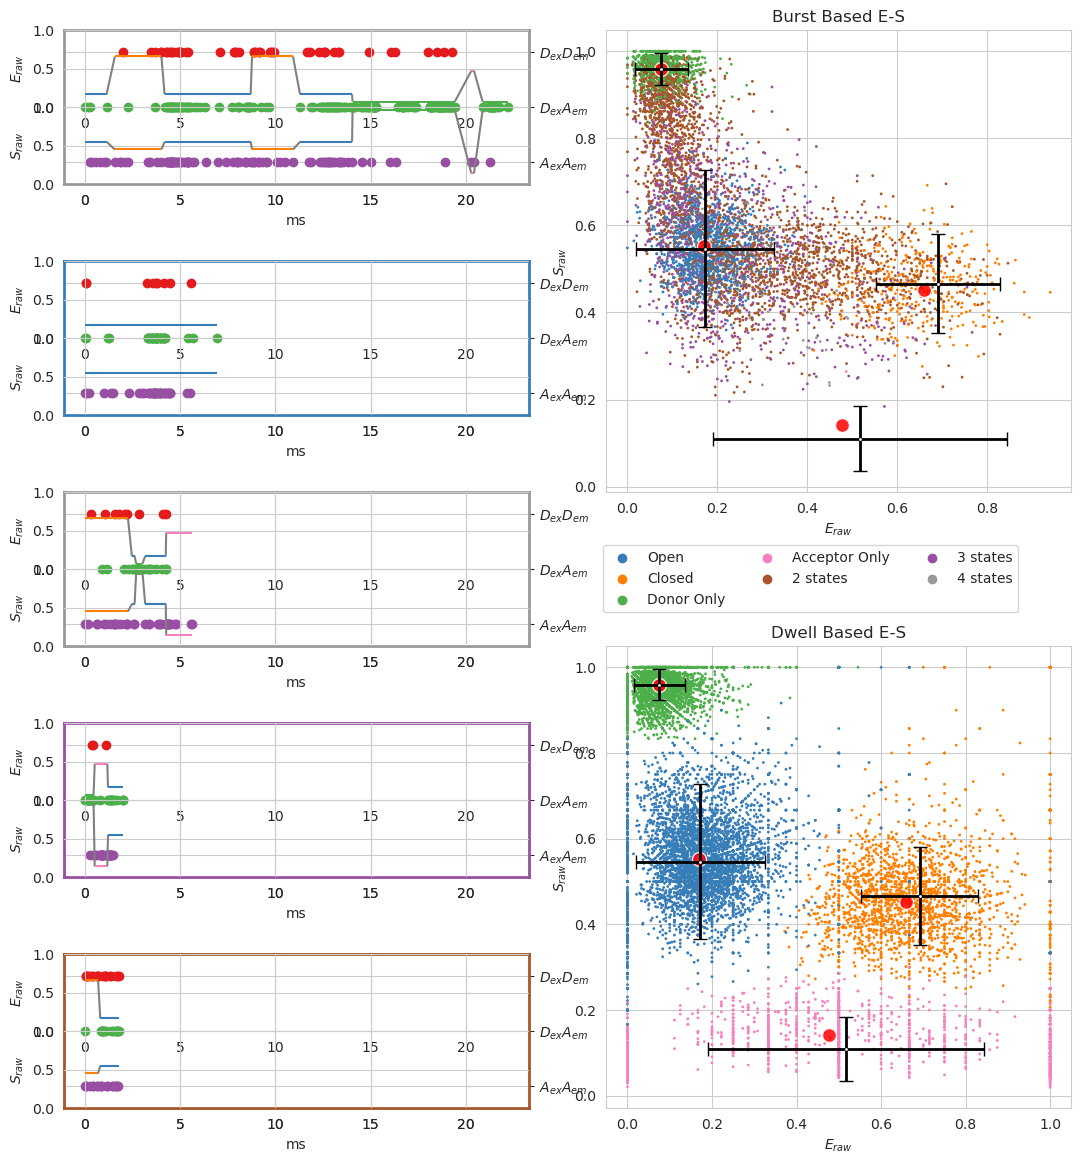

In [76]:
# data = d_da
# ph_times = ph_time_da_3
# ph_indexes = ph_index_da_3
# h_mod = h_mod_da_3[model_da_3]
# result = result_da_3[model_da_3]
# state_names = state_names_da
# bursts = [895,896,897,898,899]
# fname = filename.split('.hdf5')[0]
# fplot_sel = 'DA'
# assert len(bursts) == 5

# burst_class = []
# for i in range(h_mod.nstate):
#     burst_class.append(state_names[i])
# if h_mod.nstate > 3:
#     for i in range(2,h_mod.nstate+1):
#         burst_class.append(str(i) + ' states')
# elif h_mod.nstate == 3:
#     for i in range(h_mod.nstate-1):
#         for j in range(i+1,h_mod.nstate):
#             burst_class.append(state_names[i] + ' and ' + state_names[j])
# elif h_mod.nstate == 2:
#     burst_class.append('Dynamics')
# else:
#     burst_class.append('All states')

# trans, ES_vals = get_ES(h_mod,data.clk_p)
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(result[9])
# path = result[1]

# fig = plt.figure(figsize=(13,14))
# gs = gridspec.GridSpec(nrows=14,ncols=13,figure=fig)
# plt.subplots_adjust(hspace=0, wspace=0)
# trace = []
# for i in range(5):
#     ax1 = fig.add_subplot(gs[(3*i),0:6],sharex=trace[0][0] if i != 0 else None)
#     ax2 = fig.add_subplot(gs[(3*i+1),0:6],sharex=ax1)
#     trace.append([ax1,ax2])
# hist = [fig.add_subplot(gs[0:6,7:13]),fig.add_subplot(gs[8:14,7:13])]

# bc = []
# for bid in result[4]:
#     idstr = bin(bid)[2:]
#     cnt = idstr.count('1')
#     if cnt == 1:
#         bc.append(clr[len(idstr)-1])
#     else:
#         if h_mod.nstate > 3:
#             bc.append(clr[cnt+h_mod.nstate-2])
#         elif h_mod.nstate == 3:
#             if idstr == '11':
#                 bc.append(clr[3])
#             elif idstr == '101':
#                 bc.append(clr[4])
#             elif idstr == '110':
#                 bc.append(clr[5])
#             else:
#                 bc.append(clr[6])
#         elif h_mod.nstate == 2:
#             bc.append(clr[2])

# leg =  [Line2D([0],[0],marker='o',color=clr[i],label=b_class,markerfacecolor=clr[i],markersize=5,ls='None') 
#         for i, b_class in enumerate(burst_class)]
# hist[0].legend(handles=leg,title="",loc='lower left',bbox_to_anchor=(0.0,-0.3),fontsize=12,ncol=3)
# hist[0].scatter(data.E,data.S,c=bc,s=1)
# hist[0].set_xlim([-0.1,1.1])
# hist[0].set_ylim([-0.1,1.1])
# hist[0].text(-0.1,1.05,'f',fontsize=18,fontweight='bold',transform=hist[0].transAxes)
# hist[0].set_title("Burst based E-S",fontsize=14,fontweight='bold')
# hist[0].set_xlabel("$\mathbf{E_{raw}}$")
# hist[0].set_ylabel("$\mathbf{S_{raw}}$")

# for i, (E, S) in enumerate(zip(dwell_E,dwell_S)):
#     hist[1].scatter(E,S,c=clr[i],s=1)
# hist[1].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# hist[1].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# hist[1].set_xlim([-0.1,1.1])
# hist[1].set_ylim([-0.1,1.1])
# hist[0].text(-0.1,1.05,'g',fontsize=18,fontweight='bold',transform=hist[1].transAxes)
# hist[1].set_title("Dwell based E-S",fontsize=14,fontweight='bold')
# hist[1].set_xlabel("$\mathbf{E_{raw}}$")
# hist[1].set_ylabel("$\mathbf{S_{raw}}$")

# for i in range(len(bursts)):
#     stick_plot(ES_vals,path[bursts[i]],ph_indexes[bursts[i]],ph_times[bursts[i]],data.clk_p,clr,bc[bursts[i]],trace[i][0],trace[i][1],tick_pos='left',bar_width=0.03)
#     trace[i][0].text(-0.20,1.05,chr(ord('a')+i),fontsize=18,fontweight='bold',transform=trace[i][0].transAxes)
        
# # trace[4][1].set_xlabel('ms',fontsize=10)
# trace[0][0].set_title('Sample Burst Trajectories',fontsize=14,fontweight='bold')
# # fig.savefig('figures/'+fname+fplot_sel+'_viterbi.pdf',format='pdf',bbox_inches='tight')

bidxs = burst_nrepresentative(data, d['statepaths3'][modsel3])
# make figure and gridspec
fig = plt.figure(figsize=(13,14))
gs = fig.add_gridspec(14, 13,hspace=0.0, wspace=0.0)
# loop to plot each burst path
taxs = list()
bstates = data.get_column(d['dwells3'][modsel3]['Bstates'])
for i in range(5):
    ax0 = fig.add_subplot(gs[3*i:3*i+2,0:6], sharex=taxs[0][0] if i != 0 else None)
    ax1 = fig.add_subplot(gs[(3*i),0:6], sharex=ax0)
    ax1.patch.set_alpha(0.0)
    ax1.spines[['top','bottom','left','right']].set_visible(False)
    ax2 = fig.add_subplot(gs[(3*i+1),0:6],sharex=ax0)
    ax2.patch.set_alpha(0.0)
    ax2.spines[['top','bottom','left','right']].set_visible(False)
    smf.plot.burst_dets(data, d['bursts'].regate(gate), bidxs[i], ax=ax0, rescale=-3,
                        det_pos={smf.PhSel('0ex0em'):1.0, smf.PhSel('0ex1em'):2.0, smf.PhSel('1ex1em'):0.0}, 
                        det_kwargs={smf.PhSel('0ex0em'):{'c':'#4daf4a'}, 
                                    smf.PhSel('0ex1em'):{'c':'#e41a1c'}, 
                                    smf.PhSel('1ex1em'):{'c':'#984ea3'}}, zerostart=True)
    ax0.set_yticks([0.0, 1.0, 2.0])
    ax0.set_yticklabels(['$A_{ex}A_{em}$', '$D_{ex}A_{em}$', '$D_{ex}D_{em}$'])
    ax0.set_ylim([-0.4, 2.4])
    bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], bidxs[i], 
                             ax=ax1, slabel='$E_{raw}$', tlabel=False,
                             state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['E_raw']), 
                             rescale=-3, state_kwargs=state_kwargs, 
                             color='grey', zerostart=True)
    bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], bidxs[i], ax=ax2, 
                             slabel='$S_{raw}$', tlabel=False,
                             state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['S_raw']), 
                             rescale=-3, state_kwargs=state_kwargs, 
                             color='grey', zerostart=True)
    ax0.yaxis.set_ticks_position('right')
    ax0.yaxis.set_label_position('right')
    ax0.spines[['top','bottom','left','right']].set_color(bcmap(bstates[bidxs[i]]))
    ax0.spines[['top','bottom','left','right']].set_linewidth(2.0)
    taxs.append((ax0, ax1, ax2))

# plot burst based scatter
saxs = [fig.add_subplot(gs[0:6,7:13]),fig.add_subplot(gs[8:14,7:13])]
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], gate=g_da, ax=saxs[0],
                 point_func=smf.plot.colorcategory, point_cols=dbs['dwells3'][modsel3]['Bstates'], 
                 point_kwargs={'cmap':bcmap}, s=1.0)
leg = bhm.plot.state_labels_bursts(nlist, bcmap, ax=saxs[0], order=state_order)
saxs[0].set_title("Burst Based E-S")
saxs[0].legend(handles=leg, bbox_to_anchor=(0.9,-0.1), ncols=3)
# plot dwel based scatter
smf.plot.scatter(data, dbs['dwells3'][modsel3]['E_raw'], dbs['dwells3'][modsel3]['S_raw'], 
                 point_func=smf.plot.colorcategory, ax=saxs[1], point_cols=dbs['dwells3'][modsel3]['State'], 
                 point_kwargs={'cmap':ListedColormap([clr[i] for i in state_order])}, s=1.0)
saxs[1].set_title('Dwell Based E-S')
for sax in saxs:
    bhm.plot.scatter_model(d['E_bg'], d['S_bg'], d['statepaths3'][modsel3], data, ax=sax,
                       color='r',marker='o', lw=1.0, ec='white', s=100.0, alpha=0.85)
    smf.plot.errorbars(data, d['dwells3'][modsel3]['E_raw'], 
                       d['dwells3'][modsel3]['S_raw'],
                       d['dwells3'][modsel3]['State'], 
                       ax=sax, color='k', lw=0, ms=2, marker='.',
                       elinewidth=2, capsize=5, mec='white', mew=1, 
                       xlabel=False, ylabel=False)

**mpH<sup>2</sup>MM *Viterbi* analysis of DNA haripin at 300mM NaCl Donor Active burst selection** a-e) Selected photon traces with the *Viterbi* derived most likely state paths overlayed. Photons are represented as verticle bars colored according to the photon stream, (<font color="green">green</font> for D<sub>ex</sub>D<sub>em</sub> photons, <font color="red">red</font> for D<sub>ex</sub>A<sub>em</sub> photons, and <font color="purple">purple</font> for A<sub>ex</sub>A<sub>em</sub> photons). Horizontal line represents the $E_{raw}$ (upper pannel) and $S_{raw}$ of the state predicted by the *Viterbi* algorithm. e,f) E-S scatter plot of bursts (f) or dwells within bursts (g), color coded by which states are present in the bursts (f) or according to the state of the dwell (g), according to Viterbi algorithm. Colors are consistent throughout, with states in a-e colored as in g, and the borders of the burst traces colored as in f.

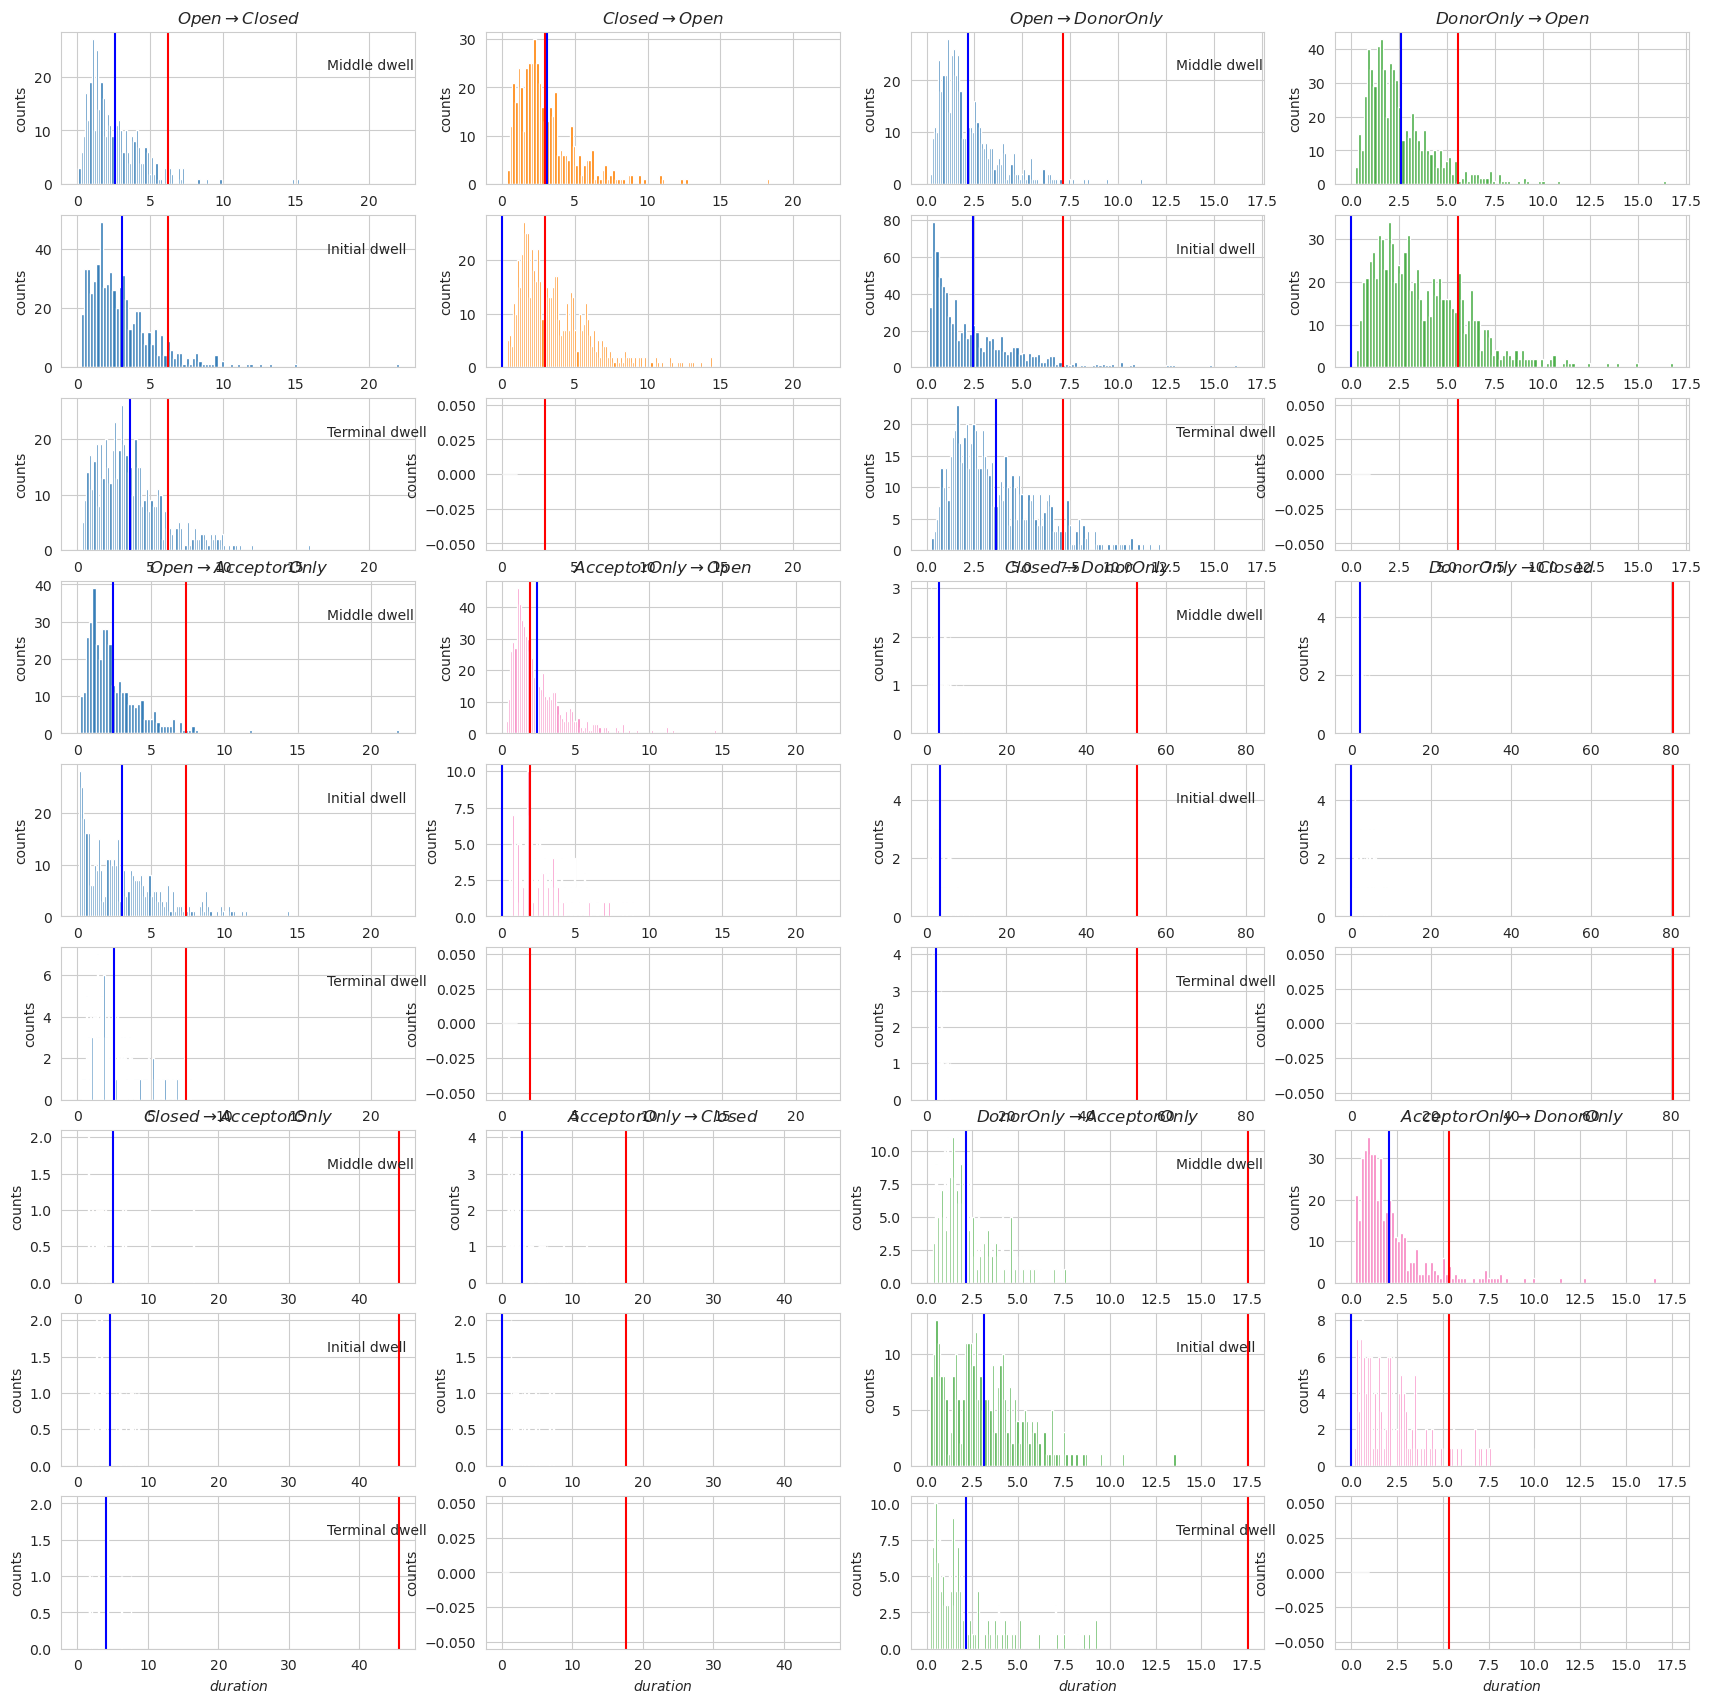

In [77]:
# # the function like inputs
# hmod = h_mod_da_3[model_da_3]
# v_result = result_da_3[model_da_3]
# clk_p = d_da.clk_p
# state_str = state_names_da
# fname = filename.split('.hdf5')[0]
# fplot_name = 'DA'

# # extract some variables
# dwell_mid = v_result[5]
# dwell_beg = v_result[6]
# dwell_end = v_result[7]
# dwell_burst = v_result[8]

# nstate = hmod.nstate
# ngraphs = nstate*(nstate-1) // 2
# nrows = ngraphs // 2 + (ngraphs % 2)
# trans, ES = get_ES(hmod,clk_p)

# fig3 = plt.figure(figsize=(21,nrows*7))
# gs3 = gridspec.GridSpec(nrows=3*nrows,ncols=4,figure=fig3)
# ax3 = [[] for i in range(ngraphs)]
# k = 0
# for i in range(nstate):
#     for j in range(i+1,nstate):
#         macro_row, macro_col = 3*(k//2), 2*(k%2)
#         ax3[k].append(fig3.add_subplot(gs3[macro_row,macro_col]))
#         ax3[k][0].hist(dwell_mid[i][j][:,0]*1000*clk_p,color=clr[i])
#         ax3[k][0].axvline(1000/trans[i,j],color='r')
#         ax3[k][0].axvline(np.mean(dwell_mid[i][j][:,0])*1000*clk_p,color='b') if dwell_mid[i][j][:,0].size != 0 else None
#         ax3[k][0].annotate('Full residence',(0.7,0.85),xycoords='axes fraction')
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+1,macro_col],sharex=ax3[k][0]))
#         ax3[k][1].hist(dwell_beg[i][j][:,0]*1000*clk_p,color=clr[i])
#         ax3[k][1].axvline(1000/trans[i,j],color='r')
#         ax3[k][1].axvline(np.mean(dwell_beg[i][j][:,0])*1000*clk_p,color='b') if dwell_beg[i][j][:,0].size != 0 else None
#         ax3[k][1].annotate('Initial Dwell',(0.7,0.85),xycoords='axes fraction')
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+2,macro_col],sharex=ax3[k][1]))
#         ax3[k][2].hist(dwell_end[i][j][:,0]*1000*clk_p,color=clr[i])
#         ax3[k][2].annotate('Ending Dwell',(0.7,0.85),xycoords='axes fraction')
#         ax3[k][2].axvline(1000/trans[i,j],color='r')
#         ax3[k][2].axvline(np.mean(dwell_end[i][j][:,0])*1000*clk_p,color='b') if dwell_end[i][j][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row,macro_col+1],sharey=ax3[k][0]))
#         ax3[k][3].hist(dwell_mid[j][i][:,0]*1000*clk_p,color=clr[j])
#         ax3[k][3].axvline(1000/trans[j,i],color='r')
#         ax3[k][3].axvline(np.mean(dwell_mid[j][i][:,0])*1000*clk_p,color='b') if dwell_mid[j][i][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+1,macro_col+1],sharey=ax3[k][1],sharex=ax3[k][3]))
#         ax3[k][4].hist(dwell_beg[j][i][:,0]*1000*clk_p,color=clr[j])
#         ax3[k][4].axvline(1000/trans[j,i],color='r')
#         ax3[k][4].axvline(np.mean(dwell_beg[j][i][:,0])*1000*clk_p,color='b') if dwell_beg[j][i][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+2,macro_col+1],sharey=ax3[k][2],sharex=ax3[k][4]))
#         ax3[k][5].hist(dwell_end[j][i][:,0]*1000*clk_p,color=clr[j])
#         ax3[k][5].axvline(1000/trans[j,i],color='r')
#         ax3[k][5].axvline(np.mean(dwell_end[j][i][:,0])*1000*clk_p,color='b') if dwell_end[j][i][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row:macro_row+3,macro_col]))
#         ax3[k][6].axis('off')
#         ax3[k][6].set_title(state_str[i] + '->' + state_str[j])
#         ax3[k].append(fig3.add_subplot(gs3[macro_row:macro_row+3,macro_col+1]))
#         ax3[k][7].axis('off')
#         ax3[k][7].set_title(state_str[j] + '->' + state_str[i])
#         k += 1
# # fig3.savefig('figures/'+fname + fplot_name + '_dwellhist.pdf',format='pdf',bbox_inches='tight')

d = dbs
modsel3 = sel_da_3

# make gates for beginning, middle and end dwells
dstate = smf.Column(d['dwells3'][modsel3]['dwells'], 'dwell_pos', ('pos',))
snext = smf.Column(d['dwells3'][modsel3]['dwells'], 'state', 1)
sprev = smf.Column(d['dwells3'][modsel3]['dwells'], 'state', -1)
gd_mid = smf.make_geq_gate(dstate, 1)
gd_beg = smf.make_isin_gate(dstate, -1)
gd_end = smf.make_isin_gate(dstate, -2)

nstate = d['statepaths3'][modsel3].params['model'].nstate
ncombs = nstate*(nstate-1) // 2
nrows = ncombs // 2 + (ncombs % 2)

nrows = (ncombs//2) + (ncombs%2)
fig3 = plt.figure(figsize=(21,nrows*7))
gs3 = fig3.add_gridspec(3*nrows, 4)
ax3 = list()
k = 0
for k, (i, j) in enumerate(combinations(state_order, 2)):
    fgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], i) & smf.make_isin_gate(snext, j)
    rgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], j) & smf.make_isin_gate(snext, i)
    pfgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], j) & smf.make_isin_gate(sprev, i)
    prgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], i) & smf.make_isin_gate(sprev, j)
    
    macro_row, macro_col = 3*(k//2), 2*(k%2)
    af0 = fig3.add_subplot(gs3[macro_row, macro_col])
    af1 = fig3.add_subplot(gs3[macro_row+1, macro_col], sharex=af0)
    af2 = fig3.add_subplot(gs3[macro_row+2, macro_col], sharex=af0)
    ar0 = fig3.add_subplot(gs3[macro_row, macro_col+1], sharex=af0)
    ar1 = fig3.add_subplot(gs3[macro_row+1, macro_col+1], sharex=af0)
    ar2 = fig3.add_subplot(gs3[macro_row+2, macro_col+1], sharex=af0)
    
    af0.set_title(rf"${state_names[i]} \rightarrow {state_names[j]}$")
    ar0.set_title(rf"${state_names[j]} \rightarrow {state_names[i]}$")
    af0.annotate('Middle dwell', (0.75,0.75), xycoords='axes fraction')
    af1.annotate('Initial dwell', (0.75,0.75), xycoords='axes fraction')
    af2.annotate('Terminal dwell', (0.75,0.75), xycoords='axes fraction')

    frate = 1e3/d['statepaths3'][modsel3].params['model'].trans[i,j]*data.clk_p
    rrate = 1e3/d['statepaths3'][modsel3].params['model'].trans[j,i]*data.clk_p
    for a in (af0, af1, af2):
        a.axvline(frate, c='r')
    for a in (ar0, ar1, ar2):
        a.axvline(rrate, c='r')
    
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_mid&fgate, ax=af0, rescale=-3, color=dcmap(i))
    if np.any(h):
        af0.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_mid&fgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_beg&fgate, ax=af1, rescale=-3, color=dcmap(i))
    if np.any(h):
        af1.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_beg&fgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_end&pfgate, ax=af2, rescale=-3, color=dcmap(i))
    if np.any(h):
        af2.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_end&pfgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_mid&rgate, ax=ar0, rescale=-3, color=dcmap(j))
    if np.any(h):
        ar0.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_mid&rgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_beg&rgate, ax=ar1, rescale=-3, color=dcmap(j))
    if np.any(h):
        ar1.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_beg&rgate)), c='b')
    h, _, _ ,_ ,_ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_beg&prgate, ax=ar2, rescale=-3, color=dcmap(j))
    if np.any(h):
        ar2.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_end&rgate))*1e3, c='b')
    ax3.append(((af0, af1, af2), (ar0, ar1, ar2)))

**Analysis of the $t_{dwell}$ distributions of *Viterbi* based on each state, for the Donor Active selection of the DNA hairpin in 300 mM NaCL.** Histograms are grouped in blocks fo 2 columns and 3 rows. Each block represents a common set of transitions, each column in the block is a different direction, i.e. one column is from *state A* to *state B*, and the other is *state B* to *state A*. The *top row* histograms the $t_{dwell}$ of dwells which begin and end within a burst. The *middle row* histograms the $t_{dwell}$ of dwells which begin at the beginning of a burst. The *bottom row* histograms teh $t_{dwell}$ of all dwells that end at the end of a burst.

<a id='da_lifetime'></a>
## Donor Active Assement of Quantum Yield through the Lifetime data

<s>First let's make a function that will sort the nanotimes based on state and stream, removing the nanotimes that have a posterior probability bellow a certain threshold, this will allow us to asses the lifetime, and therefore the quantum yield of the state</s>

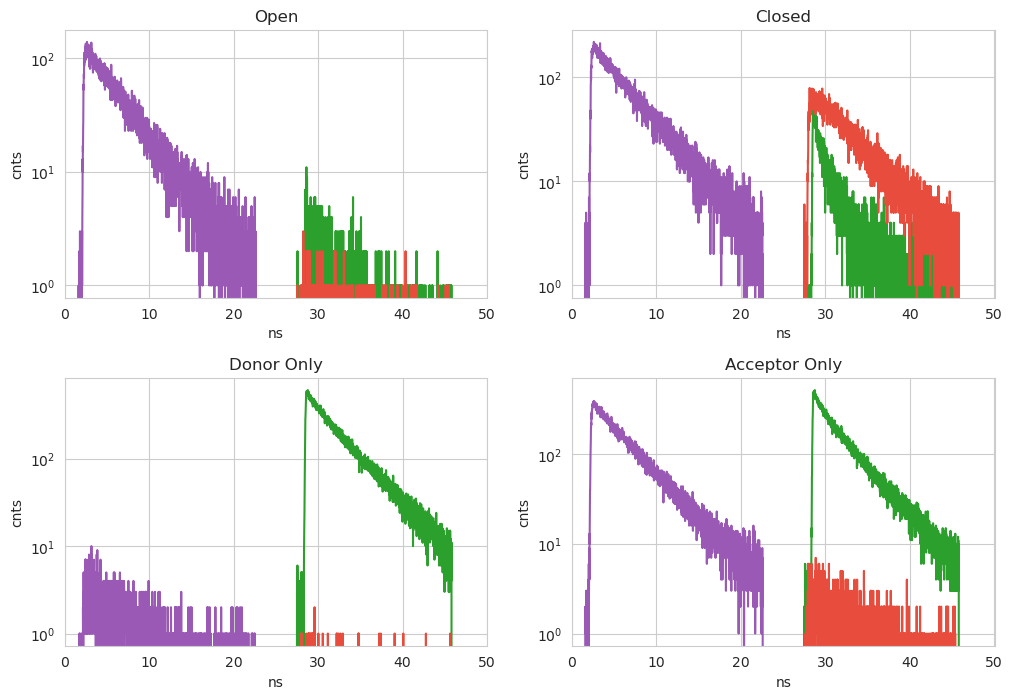

In [78]:
# nt_th_da_3 = [29,29,3]
# fig_nt = plt.figure(figsize=(20,5*( (len(state_nanotimes_hist) + 1) // 2) ))
# gs_nt = gridspec.GridSpec(ncols=2,nrows=((len(state_nanotimes_hist) + 1) // 2))
# ax_nt = []
# stream_names = ['DexDem','DexAem','AexAem']
# for i, state in enumerate(state_nanotimes_hist):
#     ax_nt.append(fig_nt.add_subplot(gs_nt[(i)//2,(i)%2]))
#     for j, stream in enumerate(state):
#         ax_nt[i].semilogy(time_axis_ns,stream[0],label=state_names_da[i]+' '+stream_names[j])
#     plt.legend()

d = dbs

fig, ax = plt.subplots(1 if modsel3  < 2 else 2, 2, figsize=(12,8), gridspec_kw={'hspace':0.3})
ax = np.atleast_2d(ax)

# compute nanotime histograms
nhist = dict()
for stream in smf.fretfactory.ALEXdefaults['streams'][1:]:
    nhcol = smf.Column(d['statepaths3'][modsel3], 'nanohist_state', (stream, 0.2, 'ph_scale', True))
    nhist[stream] = data.get_column(nhcol).sum(axis=0)

# plot histograms (the rest is all plotting)
nt_bins = np.arange(data.setup.tcspc_num_bins[0])*data.setup.tcspc_unit[0]*1e9
for i, state in enumerate(state_order):
    ax[i//2, i%2].set_title(state_names[state])
    ax[i//2, i%2].set_xlabel('ns')
    ax[i//2, i%2].set_ylabel('cnts')
    for stream in smf.fretfactory.ALEXdefaults['stream_colors', ('sel', 'streams')][1:]:
        ax[i//2, i%2].semilogy(nt_bins, nhist[stream['sel']][i,:], c=stream['color'])
        ax[i//2, i%2].set_xlim([0, data.setup.tcspc_unit[0]*data.setup.tcspc_num_bins[0]*1e9])

Play with the values in the list <s>`nt_th_da_3`</s>`irf_thresh` to exclude the IRF

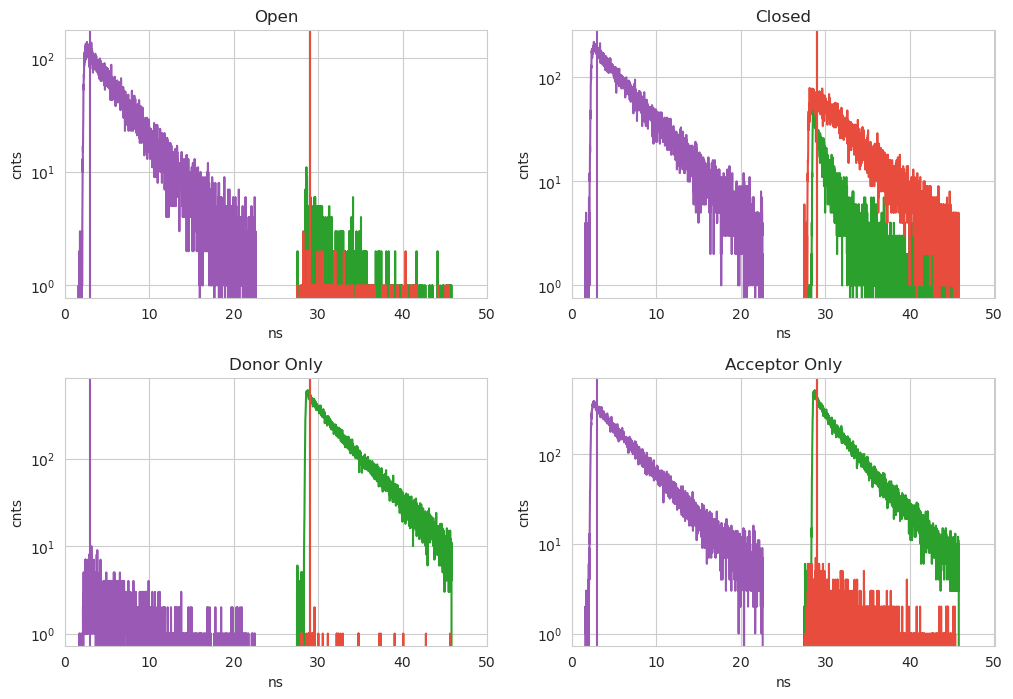

In [79]:
# nt_th_da_3 = [29,29,3]
# fig_nt = plt.figure(figsize=(20,5*( (len(state_nanotimes_hist) + 1) // 2) ))
# gs_nt = gridspec.GridSpec(ncols=2,nrows=((len(state_nanotimes_hist) + 1) // 2))
# ax_nt = []
# stream_names = ['DexDem','DexAem','AexAem']
# for i, state in enumerate(state_nanotimes_hist):
#     ax_nt.append(fig_nt.add_subplot(gs_nt[(i)//2,(i)%2]))
#     for j, stream in enumerate(state):
#         ax_nt[i].semilogy(time_axis_ns,stream[0],label=state_names_da[i]+' '+stream_names[j])
#         ax_nt[i].axvline(nt_th_da_3[j])
#     plt.legend()

d = dbs
modsel3 = sel_da_3

irf_thresh = {smf.PhSel('0ex0em'):2377, smf.PhSel('0ex1em'):2377, smf.PhSel('1ex1em'):246}


fig, ax = plt.subplots(1 if modsel3  < 2 else 2, 2, figsize=(12,8), gridspec_kw={'hspace':0.3})
ax = np.atleast_2d(ax)

# compute nanotime histograms
nhist = dict()
for stream in smf.fretfactory.ALEXdefaults['streams'][1:]:
    nhcol = smf.Column(d['statepaths3'][modsel3], 'nanohist_state', (stream, 0.2, 'ph_scale', True))
    nhist[stream] = data.get_column(nhcol).sum(axis=0)

# plot histograms (the rest is all plotting)
nt_bins = np.arange(data.setup.tcspc_num_bins[0])*data.setup.tcspc_unit[0]*1e9
for i, state in enumerate(state_order):
    ax[i//2, i%2].set_title(state_names[state])
    ax[i//2, i%2].set_xlabel('ns')
    ax[i//2, i%2].set_ylabel('cnts')
    for stream in smf.fretfactory.ALEXdefaults['stream_colors', ('sel', 'streams')][1:]:
        ax[i//2, i%2].semilogy(nt_bins, nhist[stream['sel']][i,:], c=stream['color'])
        ax[i//2, i%2].set_xlim([0, data.setup.tcspc_unit[0]*data.setup.tcspc_num_bins[0]*1e9])
        ax[i//2, i%2].axvline(nt_bins[irf_thresh[stream['sel']]], c=stream['color'])

Since `smfbursts` directly supports computation of mean nanotimes, we can set the IRF threshhold directly in the data object.

In [80]:
data.irf_thresh = irf_thresh

Now that the IRF is excluded, the mean arrival time can be calculated, which allows us to calculate the lifetime

[]

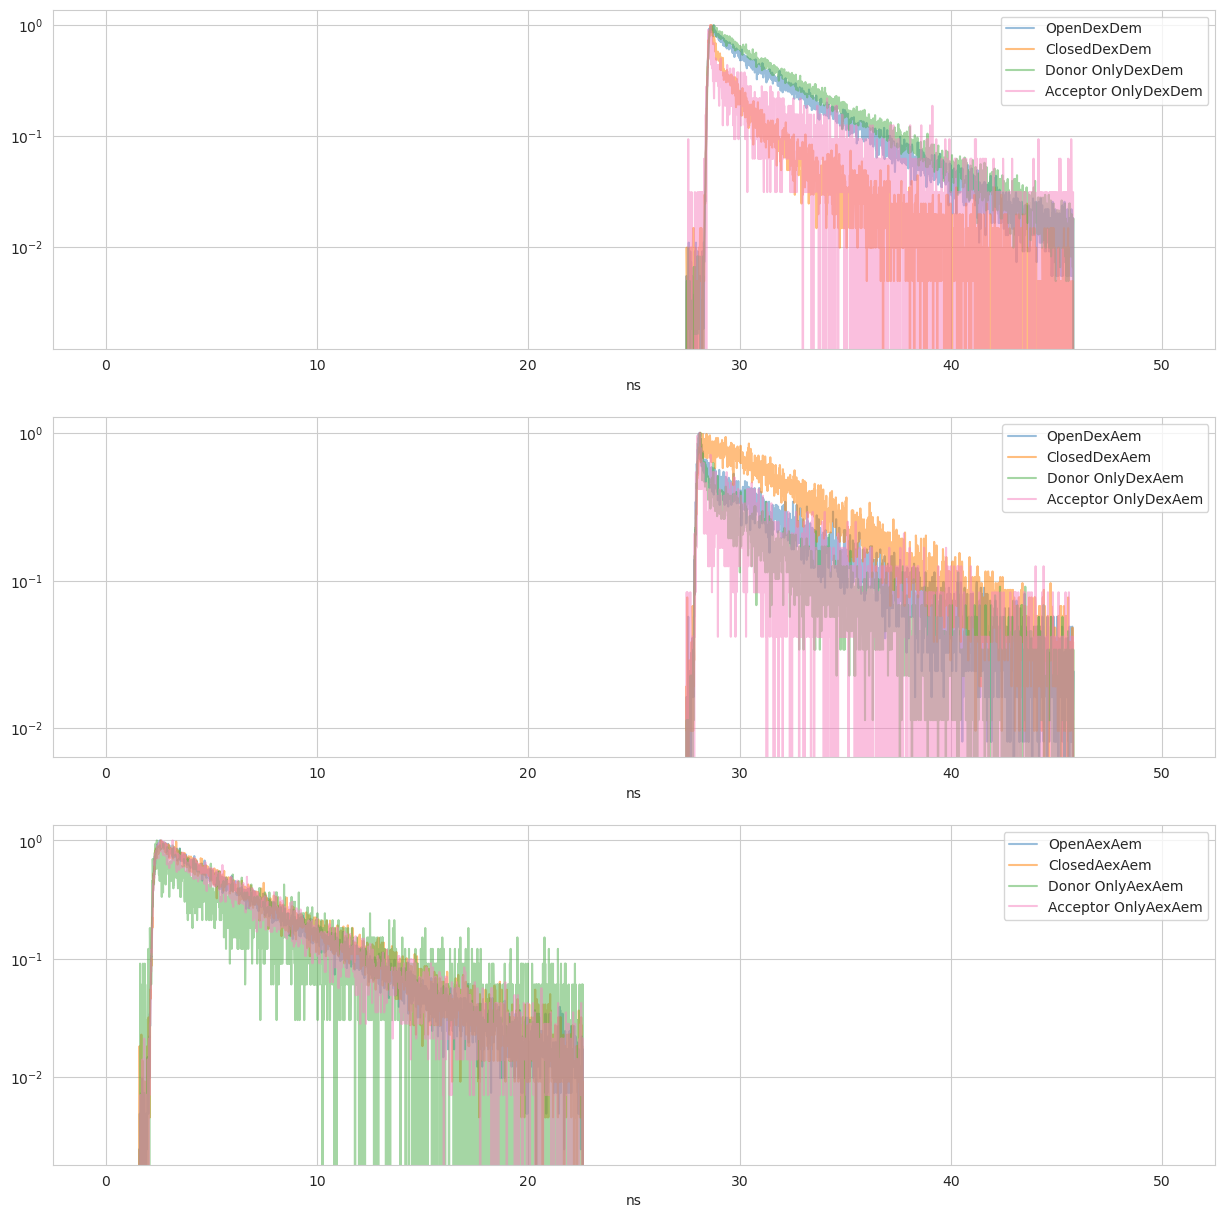

In [81]:
# state_nanotimes_corr = [[[] for j in range(len(state_nanotimes[i]))] for i in range(len(state_nanotimes))]
# state_nanotimes_mean = [[[] for j in range(len(state_nanotimes[i]))] for i in range(len(state_nanotimes))]

# fig_nt = plt.figure(figsize=(15,5*len(state_nanotimes_hist[0])))
# gs_nt = gridspec.GridSpec(ncols=1,nrows=len(state_nanotimes_hist[0]))
# ax_nt = []
# stream_str = ['DexDem','DexAem','AexAem']

# for j in range(len(state_nanotimes[0])):
#     ax_nt.append(fig_nt.add_subplot(gs_nt[j,0]))
# for i in range(len(state_nanotimes)):
#     for j in range(len(state_nanotimes[i])):
#         ax_nt[j].semilogy(time_axis_ns,state_nanotimes_hist[i][j][0]/np.max(state_nanotimes_hist[i][j][0]),alpha=0.5,label=state_names_da[i]+' '+stream_str[j])
#         state_nanotimes_corr[i][j] = state_nanotimes[i][j][state_nanotimes[i][j] > nt_th_da_3[j]/(tcspc_bin*1e9)] - nt_th_da_3[j]/(tcspc_bin*1e9)
#         state_nanotimes_mean[i][j] = np.mean(state_nanotimes_corr[i][j])
# for j in range(len(state_nanotimes[0])):
#     ax_nt[j].legend()
        
# lifetimes = np.array(state_nanotimes_mean) * tcspc_bin * 1e9
# # fig_nt.savefig('figures/'+fname+'DA_decays.pdf',format='pdf',bbox_inches='tight')
# lifetimes

fig, ax = plt.subplots(3, 1, figsize=(15, 15))

lifetimes = list()
nt_bins = np.arange(data.setup.tcspc_num_bins[0])*data.setup.tcspc_unit[0]*1e9
for i, stream in enumerate(smf.fretfactory.ALEXdefaults[('s', 'streams'),('l', 'stream_labels')][1:]):
    nh = smf.Column(d['dwells3'][modsel3]['dwells'], 'nanohist', (stream['s'], True))
    nt = smf.Column(d['dwells3'][modsel3]['dwells'], 'nanomean', stream['s'])
    lifetimes_sub = list()
    for state in state_order:
        g_temp = smf.make_isin_gate(d['dwells3'][modsel3]['State'], state)
        nhist = data.get_column(nh, gate=g_temp).sum(axis=0)
        ax[i].semilogy(nt_bins, nhist/nhist.max(), c=dcmap(state), alpha=0.5, label=state_names[state]+stream['l'])
        lifetimes_sub.append(np.nanmean(data.get_column(nt, gate=g_temp)))
    ax[i].legend()
    ax[i].set_xlabel('ns')

lifetimes

**Comparison of fluorescent lifetime decays of states derived from *Viterbi* analysis, based on Donor Active burst selection.** *Top panel:* Donor decays, ($D_{ex}D_{em}$). *Middle panel:* Acceptor FRET decays ($D_{ex}A_{em}$), *Bottom panel:* ($A_{ex}A_{em}$).

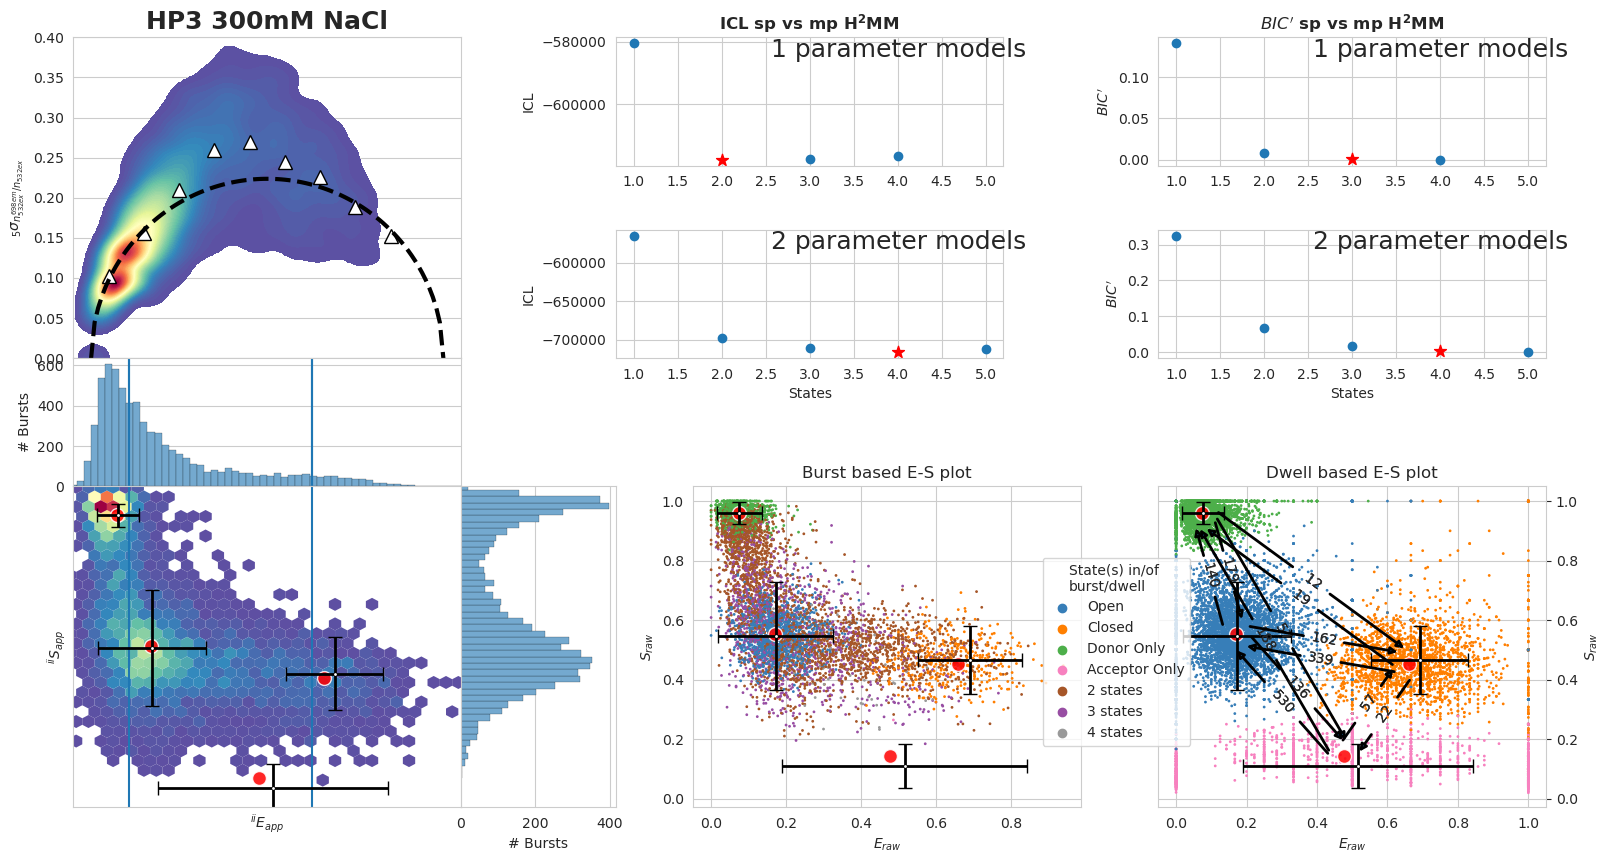

In [82]:
# # pull out the relevant variables, makes the cell act like a function
# data = d_da
# ph_times = ph_time_da_3
# ph_indexes = ph_index_da_3
# h_mod = h_mod_da_3
# h_mod2 = h_mod_da_2
# result2 = result_da_2
# result3 = result_da_3
# mod_sel = model_da_3
# mod_sel2 = model_da_2
# # Non data settings
# state_names = state_names_da
# fname = filename.split('.hdf5')[0]
# plot_sel = 'Donor Active'
# fplot_sel = 'DA'
# burst_marker_size = 5
# barwidth = 0.02
# plot_t = plot_title



# # now the automated stuff
# # build a "burst class" variable to name each type of burst by the states present
# hmod = h_mod[mod_sel]
# burst_class = []
# for i in range(hmod.nstate):
#     burst_class.append(state_names[i])
# if hmod.nstate > 3:
#     for i in range(2,hmod.nstate+1):
#         burst_class.append(str(i) + ' states')
# elif hmod.nstate == 3:
#     for i in range(hmod.nstate-1):
#         for j in range(i+1,hmod.nstate):
#             burst_class.append(state_names[i] + ' and ' + state_names[j])
# elif hmod.nstate == 2:
#     burst_class.append('Dynamics')
# else:
#     burst_class.append('All states')

# # extract some values from the given variables
# clk_p = data.clk_p
# paths = result3[mod_sel][1]
# brst_type = result3[mod_sel][4]
# ph_counts = result3[mod_sel][9]
# icl_2 = np.array([icl[0] for icl in result2])
# icl_3 = np.array([icl[0] for icl in result3])
# icl2_states = np.array([model.nstate for model in h_mod2])
# icl3_states = np.array([model.nstate for model in h_mod])
# plot_ttle = plot_t + ' ' + plot_sel

# # get needed bursts for photon stick plot
# ph_time = (ph_times[brst] - ph_times[brst][0]) * 1000 * clk_p
# ph_index = ph_indexes[brst]
# path = paths[brst]

# # Get the BVA and ES values calculated
# E_vals, std_vals, std_vals1, bn_vals = BVA(data, 5, 20, 40)
# trans, ES_vals = get_ES(hmod,clk_p)
# trasn2, ES_vals2 = get_ES(h_mod2[mod_sel2],clk_p)
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(ph_counts)

# # get the selected burst trajectory for photon stickplot
# E_path = np.zeros(path.shape,dtype=float)
# S_path = np.zeros(path.shape,dtype=float)
# EB_path = np.zeros(path.shape,dtype=float)
# SB_path = 0.5*np.ones(path.shape,dtype=float)
# ph_tm = (ph_time - ph_time[0])*clk_p*1000
# EB_color = []
# SB_color = []
# for i in range(path.size):
#     E_path[i] = ES_vals[path[i],0]
#     S_path[i] = ES_vals[path[i],1]
#     if ph_index[i] == 0:
#         EB_path[i] = -0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[2]) # change to clr[2] to make green, the more traditional color
#         SB_color.append(clr[2])
#     elif ph_index[i] == 1:
#         EB_path[i] = 0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[7]) # change to clr[7] to make red, the more traditional color
#         SB_color.append(clr[7])
#     else:
#         EB_path[i] = 0.0
#         SB_path[i] = -0.5
#         EB_color.append(clr[6])
#         SB_color.append(clr[5])

# # make burst based E and S plots
# E1 = [(index == 1).sum()/(index < 2).sum() for index in ph_indexes]
# S1 = [(index < 2).sum()/index.size for index in ph_indexes]
# # make a list of colors for the scatterplot identifying each burst by number of transitions
# bc = []
# for i in range(brst_type.size):
#     idstr = bin(brst_type[i])[2:]
#     cnt = idstr.count('1')
#     if cnt == 1:
#         bc.append(clr[len(idstr)-1])
#     else:
#         if hmod.nstate > 3:
#             bc.append(clr[cnt+hmod.nstate-2])
#         elif hmod.nstate == 3:
#             if idstr == '11':
#                 bc.append(clr[3])
#             elif idstr == '101':
#                 bc.append(clr[4])
#             elif idstr == '110':
#                 bc.append(clr[5])
#             else:
#                 bc.append(clr[6])
#         elif hmod.nstate == 2:
#             bc.append(clr[2])
        
# # set up the figures subplots
# fig1 = plt.figure(figsize=(25,15))
# gs1 = gridspec.GridSpec(nrows=12,ncols=20,figure=fig1)
# plt.subplots_adjust(hspace=0, wspace=0)
# ax1 = []
# ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
# ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[0])) # 1D FRET histogram ax1[1]
# ax1.append(fig1.add_subplot(gs1[7:12,0:5],sharex=ax1[0])) # ES hexbin plot ax1[2]
# ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[2])) # S histogram ax1[3]
# ax1.append(fig1.add_subplot(gs1[0:2,7:12])) # 1pH2MM ICL ax1[4]
# ax1.append(fig1.add_subplot(gs1[3:5,7:12],sharex=ax1[4])) # 2pH2MM ICL ax1[5]
# ax1.append(fig1.add_subplot(gs1[0:2,14:19])) # 1pH2MM BIC' ax1[6]
# ax1.append(fig1.add_subplot(gs1[3:5,14:19],sharex=ax1[6])) # 2pH2MM BIC' ax1[7]
# ax1.append(fig1.add_subplot(gs1[7:12,8:13])) # Burst based E-S viterbi calssification ax1[8]
# ax1.append(fig1.add_subplot(gs1[7:12,14:19],sharey=ax1[8])) # Dwell based E-S viterbi classification ax1[9]

# # plotting the BVA plot
# im = sns.kdeplot(x=std_vals, y=E_vals,shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100, ax=ax1[0])
# ax1[0].scatter(bn_vals,std_vals1,marker='^',s=140,color='white',edgecolors='k',alpha=1)
# ax1[0].set_ylim([0,0.4])
# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# ax1[0].plot(x_T,y_T, lw=3, color='k', ls='--')
# ax1[0].set_ylabel(r'$\mathbf{\sigma_{E}^{*}}$',fontsize=18)

# # plotting the E and S histograms that surround the ES hexbin plot
# dplot(data,hist_fret,ax=ax1[1],pdf=False, weights=None, verbose=True)
# dplot(data,hist_burst_data, data_name='S',ax=ax1[3],vertical=True)
# dplot(data, hexbin_alex, ax=ax1[2])
# ax1[2].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[2].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# for i in range(h_mod2[mod_sel2].nstate):
#     ax1[1].axvline(ES_vals2[i])
#     ax1[2].axvline(ES_vals2[i])

# # set limits and labels on first column 
# ax1[0].set_yticks(np.arange(0.1,0.5,0.1))
# ax1[1].set_ylabel('# Bursts',fontsize=18,fontweight='bold')
# ax1[2].set_xlabel(r'$\mathbf{E_{raw}}$',fontsize=18,)
# ax1[2].set_ylabel(r'$\mathbf{S_{raw}}$',fontsize=18)
# ax1[2].set_yticks([0,0.2,0.4,0.6,0.8])
# ax1[0].set_xlim([0,1])
# ax1[0].set_title(plot_ttle,fontsize=18,fontweight='bold')
# ax1[0].tick_params(labelsize=16)
# ax1[1].tick_params(labelsize=16)
# ax1[2].tick_params(labelsize=16)
# ax1[3].tick_params(labelsize=16)
# ax1[2].set_ylim([0,1])
# ax1[0].text(-0.15,1.05,'a',fontsize=18,fontweight='bold',transform=ax1[0].transAxes)
# ax1[1].set_title(' ')
# ax1[2].set_title(' ')
# ax1[2].text(-0.15,1.0,'b',fontsize=18,fontweight='bold',transform=ax1[2].transAxes)
# ax1[3].set_title(' ')
# ax1[3].set_ylabel(' ')
# ax1[3].set_xlabel('# bursts',fontsize=18,fontweight='bold')
# plt.setp(ax1[3].get_yticklabels(), visible=False)

# # ICL plots
# icl_states = np.append(icl2_states,icl3_states)
# st_min, st_max = np.min(icl_states), np.max(icl_states)
# icl_min2, icl_min3 = icl2_states[np.argmin(icl_2)], icl3_states[np.argmin(icl_3)]
# for st, ic in zip(icl2_states, icl_2):
#     c = clr[7] if st == icl_min2 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_2[mod_sel2] else dict(marker='o',s=75)
#     ax1[4].scatter(st,ic,c=c,**pltkwargs)
# for st, ic in zip(icl3_states, icl_3):
#     c = clr[7] if st == icl_min3 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_3[mod_sel] else dict(marker='o',s=75)
#     ax1[5].scatter(st,ic,c=c,**pltkwargs)
# ax1[4].grid(axis='x')
# ax1[4].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[4].tick_params(labelsize=16)
# ax1[4].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[4].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[4].set_title("ICL sp vs mp H$^2$MM",fontsize=18,fontweight='bold')
# ax1[4].text(-0.15,1.1,'c',fontsize=18,fontweight='bold',transform=ax1[4].transAxes)
# ax1[4].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].grid(axis='x')
# ax1[5].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[5].tick_params(labelsize=16)
# ax1[5].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[5].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[5].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].set_xlabel("Number of States",fontsize=18,fontweight='bold')

# # plot BIC'
# bicp2, st_2 = calc_bicp(h_mod2), np.array([mod.nstate for mod in h_mod2])
# bsel2 = st_2[np.argwhere(bicp2 < bicp_min)[0][0]]
# bicp3, st_3 = calc_bicp(h_mod), np.array([mod.nstate for mod in h_mod])
# bsel3 = st_3[np.argwhere(bicp3 < bicp_min)[0][0]]
# for st, bic in zip(st_2,bicp2):
#     c = clr[7] if st == bsel2 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if bic == bicp2[mod_sel2] else dict(marker='o',s=75)
#     ax1[6].scatter(st,bic,c=c,**pltkwargs)
# for st, bic in zip(st_3,bicp3):
#     c = clr[7] if st == bsel3 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if bic == bicp3[mod_sel] else dict(marker='o',s=75)
#     ax1[7].scatter(st,bic,c=c,**pltkwargs)
# ax1[6].axhline(bicp_min,c=clr[0],ls='-',lw=1)
# ax1[7].axhline(bicp_min,c=clr[0],ls='-',lw=1)
# ax1[6].grid(axis='x')
# ax1[6].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[6].tick_params(labelsize=16)
# ax1[6].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[6].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[6].set_title("BIC' sp vs mp H$^2$MM",fontsize=18,fontweight='bold')
# ax1[6].text(-0.05,1.05,'d',fontsize=18,fontweight='bold',transform=ax1[6].transAxes)
# ax1[6].set_ylabel("BIC'",fontsize=18,fontweight='bold')
# ax1[7].grid(axis='x')
# ax1[7].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[7].tick_params(labelsize=16)
# ax1[7].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[7].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[7].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[7].set_xlabel("Number of States",fontsize=18,fontweight='bold')

# leg =  [Line2D([0],[0],marker='o',color=clr[i],label=b_class,markerfacecolor=clr[i],markersize=10,ls='None') 
#         for i, b_class in enumerate(burst_class)]
# ax1[8].legend(handles=leg,title='State(s) in/of \nburst/dwell',bbox_to_anchor=(1.0,1.0))
# ax1[8].scatter(E1,S1,c=bc,s=burst_marker_size)
# ax1[8].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[8].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[8].set_title('Burst Based E-S',fontsize=18,fontweight='bold')
# ax1[8].set_ylim([0,1])
# ax1[8].text(-0.15,1.05,'e',fontsize=18, fontweight='bold',transform=ax1[8].transAxes)
# ax1[8].set_xlabel(r'$\mathbf{E_{raw}}$',fontsize=18)
# ax1[8].set_ylabel(r'$\mathbf{S_{raw}}$',fontsize=18)

# for i in range(hmod.nstate):
#     ax1[9].scatter(dwell_E[i],dwell_S[i],c=clr[i],s=burst_marker_size)
# ax1[9].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[9].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[9].set_title('Dwell Based E-S',fontsize=18,fontweight='bold')
# ax1[9].text(-0.15,1.05,'f',fontsize=18, fontweight='bold',transform=ax1[9].transAxes)
# ax1[9].set_xlabel(r'$\mathbf{E_{raw}}$',fontsize=18)
# ax1[9].set_ylabel(r'$\mathbf{S_{raw}}$',fontsize=18)
# ax1[9].yaxis.set_ticks_position("right")
# ax1[9].yaxis.set_label_position("right")
# for i in range(ES_vals.shape[0]-1):
#     for j in range(i+1,ES_vals.shape[0]):
#         place_arrow(ax1[9],ES_vals[i,0],ES_vals[i,1],ES_vals[j,0],ES_vals[j,1],trans[i,j],trans[j,i])
# # fig1.savefig('figures/'+fname+fplot_sel+'_summary_type3.pdf',format='pdf',bbox_inches='tight')

d = dbs
gate = g_da
modsel2 = sel_da_2
modsel3 = sel_da_3

state_names, state_order = name_order_states(d['statepaths3'][modsel3])
dcmap, bcmap, nlist = bhm.plot.make_bstate_cmap(state_names, clr, order=state_order)
# set up the figures subplots
fig1 = plt.figure(figsize=(20,10))
gs1 = fig1.add_gridspec(12,20, hspace=0.0, wspace=0.0)
ax1 = list()
ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[0])) # 1D FRET histogram ax1[1]
ax1.append(fig1.add_subplot(gs1[7:12,0:5],sharex=ax1[0])) # ES hexbin plot ax1[2]
ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[2])) # S histogram ax1[3]
ax1.append(fig1.add_subplot(gs1[0:2,7:12])) # 1pH2MM ICL ax1[4]
ax1.append(fig1.add_subplot(gs1[3:5,7:12],sharex=ax1[4])) # 2pH2MM ICL ax1[5]
ax1.append(fig1.add_subplot(gs1[0:2,14:19])) # 1pH2MM BIC' ax1[6]
ax1.append(fig1.add_subplot(gs1[3:5,14:19],sharex=ax1[6])) # 2pH2MM BIC' ax1[7]
ax1.append(fig1.add_subplot(gs1[7:12,8:13])) # Burst based E-S viterbi calssification ax1[8]
ax1.append(fig1.add_subplot(gs1[7:12,14:19],sharey=ax1[8])) # Dwell based E-S viterbi classification ax1[9]


# plot BVA
ax1[0].set_title(plot_title, fontsize=18,fontweight='bold')
smf.plot.plot_meaninterval(data, d['E_raw'], d['BVA5'], gate=gate, marker='^', 
                           color='white', ms=10, mew=1, mec='k', lw=0, 
                           bins=np.linspace(0,1,11), ax=ax1[0])
smf.plot.kdeplot(data, d['E_raw'], d['BVA5'], cmap='Spectral_r', gate=gate, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels, ax=ax1[0])
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_T*(1-x_T))/n)
ax1[0].plot(x_bva,y_bva, lw=3, color='k', ls='--')
ax1[0].set_ylim([0,0.4])
ax1[0].set_xlim([0, 1.0])


# plot burst ES
ax1[2].set_xticks([])
ax1[3].set_yticks([])
smf.plot.hexbin(data, d['E_bg'], d['S_bg'], gate=gate, ax=ax1[2], cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])
smf.plot.hist_bar(data, d['E_bg'], ax=ax1[1], gate=gate, xlabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
bhm.plot.hist_model(d['E_raw'], d['statepaths2'][modsel2], data, ax=ax1[2])
smf.plot.hist_bar(data, d['S_bg'], ax=ax1[3], gate=gate, orientation='horizontal', ylabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
ax1[2].set_xlim([-0.05, 1.05])
ax1[2].set_ylim([0.05, 1.05])

# ICL plots
bhm.plot.scatter_ICL(data, d['statepaths2'], ax=ax1[4], title=False, xlabel=False)
bhm.plot.scatter_ICL(data, d['statepaths3'], ax=ax1[5], title=False)
ax1[4].set_title(r'ICL sp vs mp $\mathbf{H^{2}MM}$', fontweight='bold')
ax1[4].set_ylabel('ICL')
ax1[5].set_ylabel('ICL')
ax1[4].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
ax1[5].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)

# BIC plots
bhm.plot.scatter_BICp(data, d['statepaths2'], ax=ax1[6], title=False, xlabel=False)
bhm.plot.scatter_BICp(data, d['statepaths3'], ax=ax1[7], title=False)
ax1[6].set_title(r'$BIC^{\prime}$ sp vs mp $\mathbf{H^{2}MM}$', fontweight='bold')
ax1[6].set_ylabel(r'$BIC^{\prime}$')
ax1[7].set_ylabel(r'$BIC^{\prime}$')
ax1[6].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
ax1[7].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)

# Burst based H2MM scatter plot
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], gate=g_da, ax=ax1[8], 
                 point_func=smf.plot.colorcategory, point_cols=dbs['dwells3'][modsel3]['Bstates'], 
                 point_kwargs={'cmap':bcmap}, s=1.0)
leg = bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order, ax=ax1[9])
ax1[9].legend(handles=leg, title='State(s) in/of \nburst/dwell', bbox_to_anchor=(0.1,0.8))
ax1[8].set_title("Burst based E-S plot")

# Dwell based H2MM scatterplot
smf.plot.scatter(data, dbs['dwells3'][modsel3]['E_raw'], dbs['dwells3'][modsel3]['S_raw'], 
                 point_func=smf.plot.colorcategory, ax=ax1[9], point_cols=dbs['dwells3'][modsel3]['State'], 
                 point_kwargs={'cmap':dcmap}, s=1.0)
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])
ax1[9].set_title("Dwell based E-S plot")

ax1[9].yaxis.set_ticks_position('right')
ax1[9].yaxis.set_label_position('right')

# overlay model parameters over scatter plots
for i in [2, 8, 9]:
    bhm.plot.scatter_model(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data, ax=ax1[i],
                       color='r',marker='o', lw=1.0, ec='white', s=100.0, alpha=0.85)
    smf.plot.errorbars(data, d['dwells3'][modsel3]['E_raw'], d['dwells3'][modsel3]['S_raw'],
                       d['dwells3'][modsel3]['State'], ax=ax1[i], color='k', lw=0, ms=2, marker='.',
                       elinewidth=2, capsize=5, mec='white', mew=1, xlabel=False, ylabel=False)
bhm.plot.scatter_model_trans_arrows(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data=data, 
                                    ax=ax1[9], arrowprops={'ec':'k', 'lw':2});

**mpH<sup>2</sup>MM results for DNA hairpin at 300 mM NaCl, Donor Active burst selection.** a) Burst variance analysis (BVA), the standard deviation of $E_{raw}$ values of bursts is displayed versus their $E_{raw}$ values. Bursts with standard deviations higher than expected solely from shot noise (semicircle), are ones that include dynamic heterogeneity, such as within-burst FRET dynamics. Triangles indicate the average of standard deviation values per $PR$ bin. b) 2D histogram of $E_{raw}$ and $S_{raw}$ (E-S plots, colloquially) of bursts. The $E_{raw}$ and $S_{raw}$ values of sub-populations derived from mpH<sup>2</sup>MM are marked by red circles, and the standard deviation (SD) of these values, derived from the *Viterbi* dwell time analysis, are marked by black crosses. Vertical blue bars indicated $E_{raw}$ derived from spH<sup>2</sup>MM. c) Comparison of values of the integrated complete likelihood ($ICL$) of spH<sup>2</sup>MM (top panel) and mpH<sup>2</sup>MM (bottom panel) of optimized models with different numbers of states. The ideal state-model is marked in red. d) Comparison of values of the modified Bayesian Information Criterion ($BIC'$) for spH<sup>2</sup>MM (top pannel) and mpH<sup>2</sup>MM of optimized models with different numbers of states. e,f) E-S scatter plots of data processed by the *Viterbi* algorithm. mpH<sup>2</sup>MM sub-populations and *Viterbi* -derived standard deviations (SD) are overlayed as red circles and black crosses, respectively. e,f) E-S scatter plot of bursts (e) or dwells within bursts (f), color coded by which states are present in the bursts (e) or according to the state of the dwell (f), according to *Viterbi* algorithm. Numbers beside arrows indicate transition rates (in $s^{-1}$) between respective states.

## FRET active Burst Selection

### Preliminary Plot results
This lets us see the state, and then give them a name

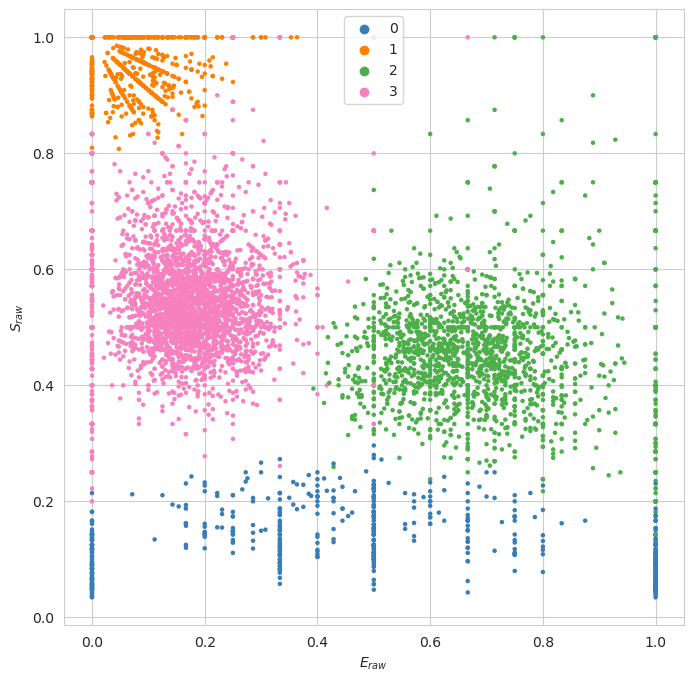

In [83]:
# plt.figure(figsize=(8,8))
# v_result = result_da_3[model_da_3]
# ph_counts = v_result[9]
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(ph_counts)
# for i in range(len(dwell_E)):
#     plt.scatter(dwell_E[i],dwell_S[i],color=clr[i],label=str(i))
# plt.legend()
d = ddc
modsel3 = sel_dc_3

plt.figure(figsize=(8,8))
dwell_dict = d['dwells3'][modsel3]
smf.plot.scatter(data, dwell_dict['E_raw'], dwell_dict['S_raw'],
                 point_func=smf.plot.colorcategory, point_cols=dwell_dict['State'],
                 point_kwargs={'cmap':cmap, 'vmin':0, 'vmax':8}, s=5.0)
for i in range(dwell_dict['dwells'].statepath.model.nstate):
    plt.scatter(np.nan, np.nan, c=[cmap(i)], label=f'{i}')
plt.legend()

Now that the states are known (and the fitting makes sense), lets give them names.

Since this is working with a hairpin, it is known that the conformations are open and closed, and by the $S_{raw}$ value, the third state can be assigned to acceptor blinking

In [84]:
# state_names_da = ['Closed','dark D','Open', 'dark A']
# state_type_da_3 = {'Closed':0b0001,'Open':0b0100,'dark A':0b1000,'dark D':0b0010,
#               'Closed and Open':0b0101,'Closed and dark A':0b1001,'Closed and dark D':0b0011,
#               'Open and dark A':0b1100,'Open and dark D':0b0110,'dark A and dark D':0b1010,
#               'Closed, Open and dark A':0b1101,'Closed, Open and dark D':0b0111,'Closed, dark A, and dark D':0b1011,
#               'Open, dark A and dark D':0b1110,
#               'All':0b1111}
# for state in state_type_da_3:
#     state_type_da_3[state] = np.array(state_type_da_3[state]==result_da_3[model_da_3][4]).sum()
#     print('%-20s : %d' %(state,state_type_da_3[state]))
d = ddc
modsel3 = sel_dc_3

state_names, state_order = name_order_states(d['statepaths3'][modsel3-1])

maxlen = sum(len(s) for s in sorted(state_names, key=lambda s: len(s), reverse=True)[:-1])
pfmt = f'%-{maxlen+5*len(state_names)-10}s : %d'
bstates = data.get_column(smf.Column(d['statepaths3'][modsel3], 'bstates'))
state_counts = np.bincount(bstates)
name_dct = list()
for cl in chain.from_iterable(combinations(enumerate(state_names), i) for i in range(1,len(state_names)+1)):
    idxs, names = zip(*cl)
    name = 'all' if len(names) == len(state_names) else ' and '.join(names)
    print(pfmt % (name, state_counts[sum(1<<i for i in idxs)]))

Donor Only            : 0
Closed                : 0
Open                  : 314
Donor Only and Closed : 20
Donor Only and Open   : 8
Closed and Open       : 52
all                   : 7


In [85]:
modsel3

np.int64(3)

<a id='da_mainplot'></a>
## Plot information relevant to 2D E-S plots for DCBS burst selection

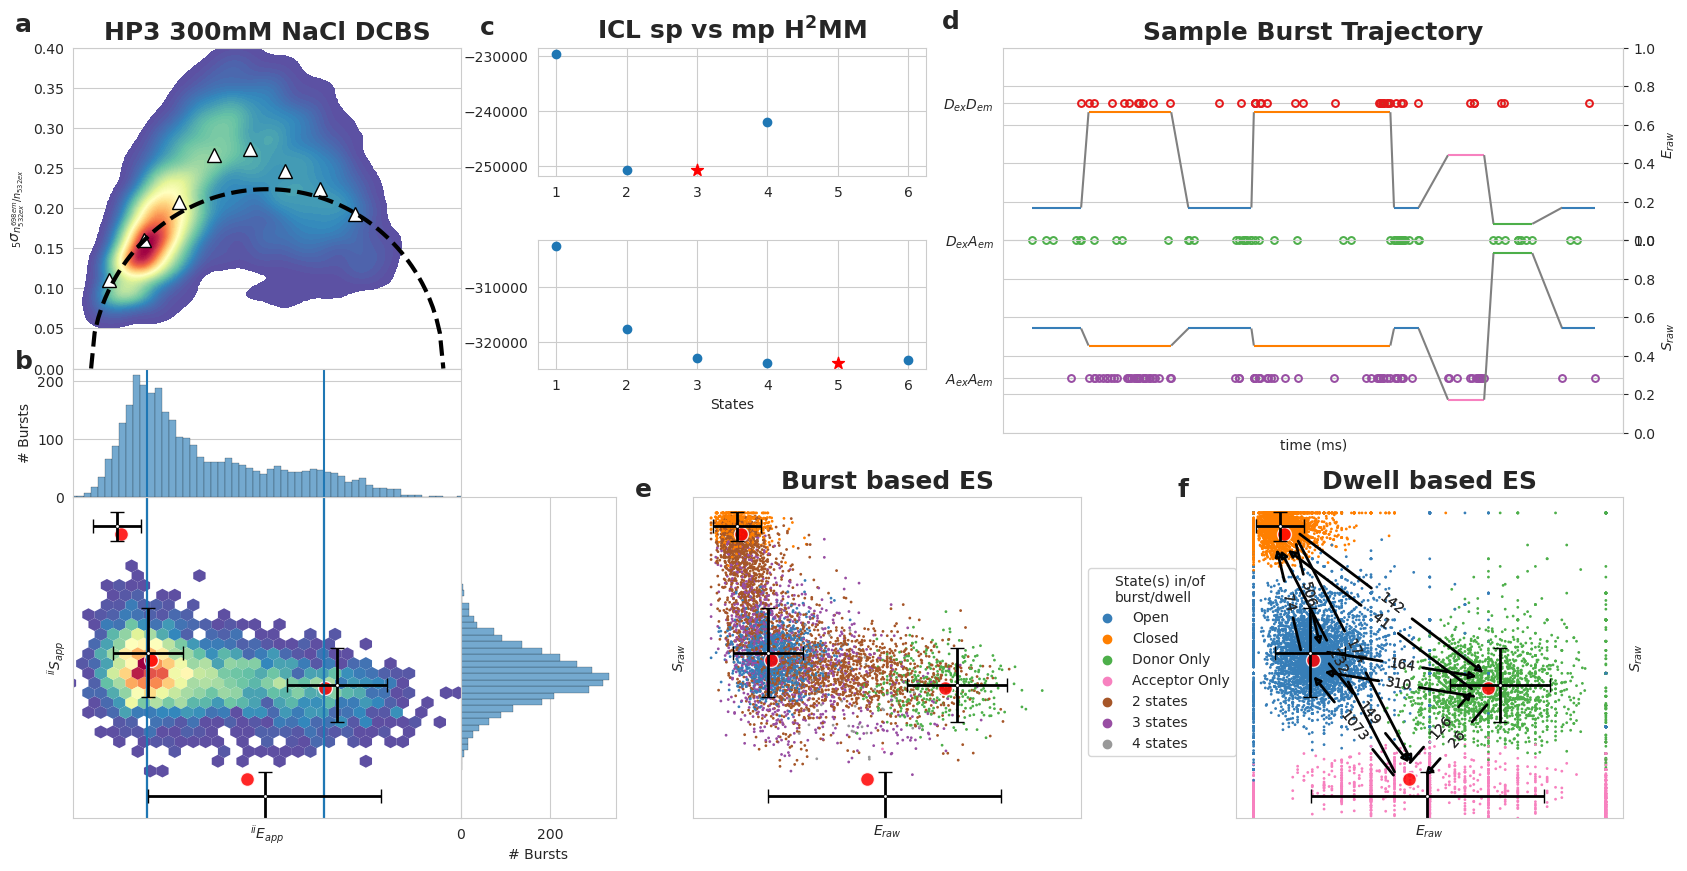

In [86]:
# pull out the relevant variables, makes the cell act like a function
# data = d_da
# ph_times = ph_time_da_3
# ph_indexes = ph_index_da_3
# h_mod = h_mod_da_3
# h_mod2 = h_mod_da_2
# c_result = result_da_2
# v_result = result_da_3
# mod_sel = model_da_3
# mod_sel2 = model_da_2
# # Non data settings
# state_names = state_names_da
# fname = filename.split('.hdf5')[0]
# plot_sel = 'Donor Active'
# fplot_sel = 'DA'
# brst = 55
# burst_marker_size = 5
# barwidth = 0.02
# plot_t = plot_title

# # now the automated stuff
# hmod = h_mod[mod_sel]
# hmod2 = h_mod2[mod_sel2]
# burst_class = []
# for i in range(hmod.nstate):
#     burst_class.append(state_names[i])
# if hmod.nstate > 3:
#     for i in range(2,hmod.nstate+1):
#         burst_class.append(str(i) + ' states')
# elif hmod.nstate == 3:
#     for i in range(hmod.nstate-1):
#         for j in range(i+1,hmod.nstate):
#             burst_class.append(state_names[i] + ' and ' + state_names[j])
# else:
#     burst_class.append('All states')

# # extract some values from the given variables
# clk_p = data.clk_p
# paths = v_result[mod_sel][1]
# brst_type = v_result[mod_sel][4]
# ph_counts = v_result[mod_sel][9]
# icl_2 = np.array([icl[0] for icl in c_result])
# icl_3 = np.array([icl[0] for icl in v_result])
# icl2_states = np.array([model.nstate for model in h_mod2])
# icl3_states = np.array([model.nstate for model in h_mod])
# plot_ttle = plot_t + ' ' + plot_sel

# # get needed bursts for photon stick plot
# ph_time = ph_times[brst]
# ph_index = ph_indexes[brst]
# path = paths[brst]

# # Get the BVA and ES values calculated
# E_vals, std_vals, std_vals1, bn_vals = BVA(data, 5, 20, 40)
# trans, ES_vals = get_ES(hmod,clk_p)
# trans2, ES_vals2 = get_ES(hmod2,clk_p)
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(ph_counts)

# # get the selected burst trajectory for photon stickplot
# E_path = np.zeros(path.shape,dtype=float)
# S_path = np.zeros(path.shape,dtype=float)
# EB_path = np.zeros(path.shape,dtype=float)
# SB_path = 0.5*np.ones(path.shape,dtype=float)
# ph_tm = (ph_time - ph_time[0])*clk_p*1000
# EB_color = []
# SB_color = []
# for i in range(path.size):
#     E_path[i] = ES_vals[path[i],0]
#     S_path[i] = ES_vals[path[i],1]
#     if ph_index[i] == 0:
#         EB_path[i] = -0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[2]) # change to clr[2] to make green, the more traditional color
#         SB_color.append(clr[2])
#     elif ph_index[i] == 1:
#         EB_path[i] = 0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[7]) # change to clr[7] to make red, the more traditional color
#         SB_color.append(clr[7])
#     else:
#         EB_path[i] = 0.0
#         SB_path[i] = -0.5
#         EB_color.append(clr[6])
#         SB_color.append(clr[5])

# # make burst based E and S plots
# E1 = [(index == 1).sum()/(index < 2).sum() for index in ph_indexes]
# S1 = [(index < 2).sum()/index.size for index in ph_indexes]
# # make a list of colors for the scatterplot identifying each burst by number of transitions
# bc = []
# for i in range(brst_type.size):
#     idstr = bin(brst_type[i])[2:]
#     cnt = idstr.count('1')
#     if cnt == 1:
#         bc.append(clr[len(idstr)-1])
#     else:
#         if hmod.nstate > 3:
#             bc.append(clr[cnt+hmod.nstate-2])
#         else:
#             if idstr == '11':
#                 bc.append(clr[3])
#             elif idstr == '101':
#                 bc.append(clr[4])
#             elif idstr == '110':
#                 bc.append(clr[5])
#             else:
#                 bc.append(clr[6])
        
# # set up the figures subplots
# fig1 = plt.figure(figsize=(25,15))
# gs1 = gridspec.GridSpec(nrows=12,ncols=20,figure=fig1)
# plt.subplots_adjust(hspace=0, wspace=0)
# ax1 = []
# ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
# ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[0])) # 1D FRET histogram ax1[1]
# ax1.append(fig1.add_subplot(gs1[7:12,0:5],sharex=ax1[0])) # ES hexbin plot ax1[2]
# ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[2])) # S histogram ax1[3]
# ax1.append(fig1.add_subplot(gs1[0:2,6:11])) # 1pH2MM BIC' ax1[4]
# ax1.append(fig1.add_subplot(gs1[3:5,6:11])) # 2pH2MM BIC' ax1[5]
# ax1.append(fig1.add_subplot(gs1[0:3,12:20])) # E photon path ax1[6]
# ax1.append(fig1.add_subplot(gs1[3:6,12:20],sharex=ax1[6])) # S photon path ax1[7]
# ax1.append(fig1.add_subplot(gs1[7:12,8:13])) # Burst based E-S viterbi calssification ax1[8]
# ax1.append(fig1.add_subplot(gs1[7:12,15:20],sharey=ax1[8])) # Dwell based E-S viterbi classification ax1[9]

# # plotting the BVA plot
# im = sns.kdeplot(x=std_vals, y=E_vals,shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100, ax=ax1[0])
# ax1[0].scatter(bn_vals,std_vals1,marker='^',s=140,color='white',edgecolors='k',alpha=1)
# ax1[0].set_ylim([0,0.4])
# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# ax1[0].plot(x_T,y_T, lw=3, color='k', ls='--')
# ax1[0].set_ylabel('$\mathbf{\sigma_{E}^{*}}$',fontsize=18)

# # plotting the E and S histograms that surround the ES hexbin plot
# dplot(data,hist_fret,ax=ax1[1],pdf=False, weights=None, verbose=True)
# dplot(data,hist_burst_data, data_name='S',ax=ax1[3],vertical=True)
# dplot(data, hexbin_alex, ax=ax1[2])
# ax1[2].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[2].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# for i in range(h_mod2[mod_sel2].nstate):
#     ax1[1].axvline(ES_vals2[i])
#     ax1[2].axvline(ES_vals2[i])

# # set limits and labels on first column 
# ax1[0].set_yticks(np.arange(0.1,0.5,0.1))
# ax1[1].set_ylabel('# Bursts',fontsize=18,fontweight='bold')
# ax1[2].set_xlabel('$\mathbf{E_{raw}}$',fontsize=18,)
# ax1[2].set_ylabel('$\mathbf{S_{raw}}$',fontsize=18)
# ax1[2].set_yticks([0,0.2,0.4,0.6,0.8])
# ax1[0].set_xlim([0,1])
# ax1[0].set_title(plot_title,fontsize=18,fontweight='bold')
# ax1[0].tick_params(labelsize=16)
# ax1[1].tick_params(labelsize=16)
# ax1[2].tick_params(labelsize=16)
# ax1[3].tick_params(labelsize=16)
# ax1[2].set_ylim([0,1])
# ax1[0].text(-0.15,1.05,'a',fontsize=18,fontweight='bold',transform=ax1[0].transAxes)
# ax1[1].set_title(' ')
# ax1[2].set_title(' ')
# ax1[2].text(-0.15,1.0,'b',fontsize=18,fontweight='bold',transform=ax1[2].transAxes)
# ax1[3].set_title(' ')
# ax1[3].set_ylabel(' ')
# ax1[3].set_xlabel('# bursts',fontsize=18,fontweight='bold')
# plt.setp(ax1[3].get_yticklabels(), visible=False)

# # ICL plots
# icl_states = np.append(icl2_states,icl3_states)
# st_min, st_max = np.min(icl_states), np.max(icl_states)
# icl_min2, icl_min3 = icl2_states[np.argmin(icl_2)], icl3_states[np.argmin(icl_3)]
# for st, ic in zip(icl2_states, icl_2):
#     c = clr[7] if st == icl_min2 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_2[mod_sel2] else dict(marker='o',s=75)
#     ax1[4].scatter(st,ic,c=c,**pltkwargs)
# for st, ic in zip(icl3_states, icl_3):
#     c = clr[7] if st == icl_min3 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_3[mod_sel] else dict(marker='o',s=75)
#     ax1[5].scatter(st,ic,c=c,**pltkwargs)
# ax1[4].grid(axis='x')
# ax1[4].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[4].tick_params(labelsize=16)
# ax1[4].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[4].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[4].set_title("sp vs mp H$^2$MM",fontsize=18,fontweight='bold')
# ax1[4].text(-0.15,1.1,'c',fontsize=18,fontweight='bold',transform=ax1[4].transAxes)
# ax1[4].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].grid(axis='x')
# ax1[5].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[5].tick_params(labelsize=16)
# ax1[5].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[5].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[5].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].set_xlabel("Number of States",fontsize=18,fontweight='bold')

# # # plot photon path
# stick_plot(ES_vals,path,ph_index,ph_time,clk_p,clr,bc[brst],ax1[6],ax1[7],bar_width=0.03)
# ax1[6].set_title('Sample Burst Trajectory',fontsize=18,fontweight='bold')
# ax1[6].text(-0.15,1.1,'d',fontsize=18,fontweight='bold',transform=ax1[6].transAxes)

# leg =  [Line2D([0],[0],marker='o',color=clr[i],label=b_class,markerfacecolor=clr[i],markersize=10,ls='None') 
#         for i, b_class in enumerate(burst_class)]
# ax1[8].legend(handles=leg,title='State(s) in/of \nburst/dwell',bbox_to_anchor=(1.0,1.0))
# ax1[8].scatter(E1,S1,c=bc,s=burst_marker_size)
# ax1[8].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[8].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[8].set_title('Burst Based E-S',fontsize=18,fontweight='bold')
# ax1[8].set_ylim([0,1])
# ax1[8].text(-0.15,1.05,'e',fontsize=18, fontweight='bold',transform=ax1[8].transAxes)
# ax1[8].set_xlabel('$\mathbf{E_{raw}}$',fontsize=18)
# ax1[8].set_ylabel('$\mathbf{S_{raw}}$',fontsize=18)

# for i in range(hmod.nstate):
#     ax1[9].scatter(dwell_E[i],dwell_S[i],c=clr[i],s=burst_marker_size)
# ax1[9].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[9].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[9].set_title('Dwell Based E-S',fontsize=18,fontweight='bold')
# ax1[9].text(-0.15,1.05,'f',fontsize=18, fontweight='bold',transform=ax1[9].transAxes)
# ax1[9].set_xlabel('$\mathbf{E_{raw}}$',fontsize=18)
# ax1[9].set_ylabel('$\mathbf{S_{raw}}$',fontsize=18)
# ax1[9].yaxis.set_ticks_position("right")
# ax1[9].yaxis.set_label_position("right")
# # fig1.savefig('figures/'+fname+fplot_sel+'_summary_type0.pdf',format='pdf',bbox_inches='tight')

d = ddc
gate = g_dcfret
modsel2 = sel_dc_2
modsel3 = sel_dc_3
title = "DCBS"

brst_n = burst_mostT_fret(data, d['statepaths3'][modsel3], )[0]

state_names, state_order = name_order_states(d['statepaths3'][modsel3])
dcmap, bcmap, nlist = bhm.plot.make_bstate_cmap(state_names, clr, order=state_order)
# set up the figures subplots
fig1 = plt.figure(figsize=(20,10))
gs1 = fig1.add_gridspec(12,20, hspace=0.0, wspace=0.0)
ax1 = list()
ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
ax1.append(fig1.add_subplot(gs1[7:12,0:5], sharex=ax1[0])) # ES hexbin plot ax1[1]
ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[1])) # 1D FRET histogram ax1[2]
ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[1])) # S histogram ax1[3]
ax1.append(fig1.add_subplot(gs1[0:2,6:11])) # 1pH2MM BIC' ax1[4]
ax1.append(fig1.add_subplot(gs1[3:5,6:11], sharex=ax1[4])) # 2pH2MM BIC' ax1[5]
ax1.append(fig1.add_subplot(gs1[0:6,12:20])) # Burst photon path ax1[6]
ax1.append(fig1.add_subplot(gs1[0:3,12:20],sharex=ax1[6])) # E state path ax1[7]
ax1.append(fig1.add_subplot(gs1[3:6,12:20],sharex=ax1[6])) # S state path ax1[8]
ax1.append(fig1.add_subplot(gs1[7:12,8:13], sharex=ax1[1], sharey=ax1[1])) # Burst based E-S viterbi calssification ax1[9]
ax1.append(fig1.add_subplot(gs1[7:12,15:20],sharex=ax1[1], sharey=ax1[1])) # Dwell based E-S viterbi classification ax1[10]

ax1[0].text(-0.15,1.05,'a',fontsize=18,fontweight='bold',transform=ax1[0].transAxes)
ax1[2].text(-0.15,1.0,'b',fontsize=18,fontweight='bold',transform=ax1[2].transAxes)
ax1[4].text(-0.15,1.1,'c',fontsize=18,fontweight='bold',transform=ax1[4].transAxes)
ax1[6].text(-0.10,1.05,'d',fontsize=18,fontweight='bold',transform=ax1[6].transAxes)
ax1[9].text(-0.15,1.00,'e',fontsize=18, fontweight='bold',transform=ax1[9].transAxes)
ax1[10].text(-0.15,1.00,'f',fontsize=18, fontweight='bold',transform=ax1[10].transAxes)


# plot BVA
ax1[0].set_title(f'{plot_title} {title}', fontsize=18,fontweight='bold')
smf.plot.plot_meaninterval(data, d['E_raw'], d['BVA5'], gate=gate, marker='^', 
                           color='white', ms=10, mew=1, mec='k', lw=0, 
                           bins=np.linspace(0,1,11), ax=ax1[0])
smf.plot.kdeplot(data, d['E_raw'], d['BVA5'], cmap='Spectral_r', gate=gate, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels, ax=ax1[0])
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_T*(1-x_T))/n)
ax1[0].plot(x_bva,y_bva, lw=3, color='k', ls='--')
ax1[0].set_ylim([0,0.4])
ax1[0].set_xlim([0, 1.0])


# plot burst ES
ax1[2].set_xticks([])
ax1[3].set_yticks([])
smf.plot.hexbin(data, d['E_bg'], d['S_bg'], gate=gate, ax=ax1[1], cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])
smf.plot.hist_bar(data, d['E_bg'], ax=ax1[2], gate=gate, xlabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
bhm.plot.hist_model(d['E_raw'], d['statepaths2'][modsel2], data, ax=ax1[1])
smf.plot.hist_bar(data, d['S_bg'], ax=ax1[3], gate=gate, orientation='horizontal', ylabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[2])
ax1[1].set_xlim([-0.05, 1.05])
ax1[1].set_ylim([0.05, 1.05])

# ICL plots
bhm.plot.scatter_ICL(data, d['statepaths2'], ax=ax1[4], title=False, xlabel=False)
bhm.plot.scatter_ICL(data, d['statepaths3'], ax=ax1[5], title=False)
ax1[4].set_title(r'ICL sp vs mp $\mathbf{H^{2}MM}$', fontsize=18,fontweight='bold')


# plot burst-H2MM categories
ax1[7].patch.set_alpha(0.0)
ax1[7].grid('off')
ax1[7].spines[['top','bottom','left']].set_visible(False)
ax1[7].yaxis.set_ticks_position('right')
ax1[7].yaxis.set_label_position('right')
ax1[7].set_xticks([])
ax1[8].patch.set_alpha(0.0)
ax1[8].grid('off')
ax1[8].spines[['top','bottom','left']].set_visible(False)
ax1[8].yaxis.set_ticks_position('right')
ax1[8].yaxis.set_label_position('right')
ax1[8].set_xticks([])
smf.plot.burst_dets(data, d['bursts'].regate(gate), brst_n, ax=ax1[6], rescale=-3, zerostart=True,
                    det_pos={smf.PhSel('0ex0em'):1.0, smf.PhSel('0ex1em'):2.0, smf.PhSel('1ex1em'):0.0}, 
                    det_kwargs={smf.PhSel('0ex0em'):{'ec':'#4daf4a', 'fc':((0x4d/0xff,0xaf/0xff,0x4a/0xff, 0.2),)}, 
                                smf.PhSel('0ex1em'):{'ec':'#e41a1c', 'fc':((0x4d/0xff,0xaf/0xff,0x4a/0xff, 0.2),)}, 
                                smf.PhSel('1ex1em'):{'ec':'#984ea3', 'fc':((0x4d/0xff,0xaf/0xff,0x4a/0xff, 0.2),)}}, 
                    linewidths=5.0, s=2.0)
ax1[6].set_yticks([0.0, 1.0, 2.0])
ax1[6].set_yticklabels(['$A_{ex}A_{em}$', '$D_{ex}A_{em}$', '$D_{ex}D_{em}$'])
state_kwargs = {'colors':{i:clr[r] for i, r in enumerate(state_order)}}
bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], brst_n, ax=ax1[7], slabel='$E_{raw}$', tlabel=False,
                         state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['E_raw']), rescale=-3,
                         state_kwargs=state_kwargs, color='grey', zerostart=True)
bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], brst_n, ax=ax1[8], slabel='$S_{raw}$', tlabel=False,
                         state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['S_raw']), rescale=-3,
                         state_kwargs=state_kwargs, color='grey', zerostart=True)
ax1[6].set_xlabel('time (ms)')
ax1[6].set_ylim([-0.4, 2.4])
ax1[7].set_ylim([0.0,1.0])
ax1[8].set_ylim([0.0,1.0])
ax1[6].set_title(r'Sample Burst Trajectory', fontsize=18,fontweight='bold')

# Burst based H2MM scatter plot
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], gate=g_da, ax=ax1[9], 
                 point_func=smf.plot.colorcategory, point_cols=dbs['dwells3'][modsel3]['Bstates'], 
                 point_kwargs={'cmap':bcmap}, s=1.0)
leg = bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order, ax=ax1[9])
ax1[9].legend(handles=leg, title='State(s) in/of \nburst/dwell', bbox_to_anchor=(1.0,0.8))
ax1[9].set_title(r'Burst based ES', fontsize=18,fontweight='bold')

# Dwell based H2MM scatterplot
smf.plot.scatter(data, dbs['dwells3'][modsel3]['E_raw'], dbs['dwells3'][modsel3]['S_raw'], 
                 point_func=smf.plot.colorcategory, ax=ax1[10], point_cols=dbs['dwells3'][modsel3]['State'], 
                 point_kwargs={'cmap':dcmap}, s=1.0)
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])

ax1[10].yaxis.set_ticks_position('right')
ax1[10].yaxis.set_label_position('right')
ax1[10].set_title(r'Dwell based ES', fontsize=18,fontweight='bold')

# overlay model parameters over scatter plots
for i in [1, 9, 10]:
    bhm.plot.scatter_model(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data, ax=ax1[i],
                       color='r',marker='o', lw=1.0, ec='white', s=100.0, alpha=0.85)
    smf.plot.errorbars(data, d['dwells3'][modsel3]['E_raw'], d['dwells3'][modsel3]['S_raw'],
                       d['dwells3'][modsel3]['State'], ax=ax1[i], color='k', lw=0, ms=2, marker='.',
                       elinewidth=2, capsize=5, mec='white', mew=1, xlabel=False, ylabel=False)

bhm.plot.scatter_model_trans_arrows(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data=data, 
                                    arrowprops={'ec':'k', 'lw':2}, ax=ax1[10]);

**mpH<sup>2</sup>MM results for DNA hairpin at 300 mM NaCl, DCBS burst selection.** 
a) Burst variance analysis (BVA), the standard deviation of $E_{raw}$ values of bursts is displayed versus their $E_{raw}$ values. 
Bursts with standard deviations higher than expected solely from shot noise (semicircle), are ones that include dynamic heterogeneity, such as within-burst FRET dynamics. 
Triangles indicate the average of standard deviation values per $E_{raw}$ bin. 
b) 2D histogram of $E_{raw}$ and $S_{raw}$ (E-S plots, colloquially) of bursts. 
The $E_{raw}$ and $S_{raw}$ values of sub-populations derived from mpH<sup>2</sup>MM are marked by red circles, 
and the standard deviation (SD) of these values, derived from the *Viterbi* dwell time analysis, are marked by black crosses. 
Vertical blue bars indicated $E_{raw}$ derived from spH<sup>2</sup>MM. 
c) Comparison of values of the integrated complete likelihood ($ICL$) of spH<sup>2</sup>MM (top panel) and mpH<sup>2</sup>MM (bottom panel) of optimized models with different numbers of states. 
The ideal state-model is marked in red. 
d) Comparison of values of the modified Bayesian Information Criterion ($BIC'$) of optimized models with different numbers of states, using spH<sup>2</sup>MM (top pannel) and mpH<sup>2</sup>MM (bottom pannel), 
the model with the fewest number of states with a BIC' less than 0.005 is marked in red. 
e) A sample burst trajectory, with photons represented as colored vertical bars, with donor excitation photons colored green or red for donor and acceptor, respectively, and acceptor excitation photons colored purple. 
$E_{raw}$ (top panel) and $S_{raw}$ (bottom panel) of sub-populations determined from dwells using the *Viterbi* algorithm, are overlayed on the photon bars. 
e,f) E-S scatter plots of data processed by the *Viterbi* algorithm. mpH<sup>2</sup>MM sub-populations and *Viterbi* -derived standard deviations (SD) are overlayed as red circles and black crosses, respectively.

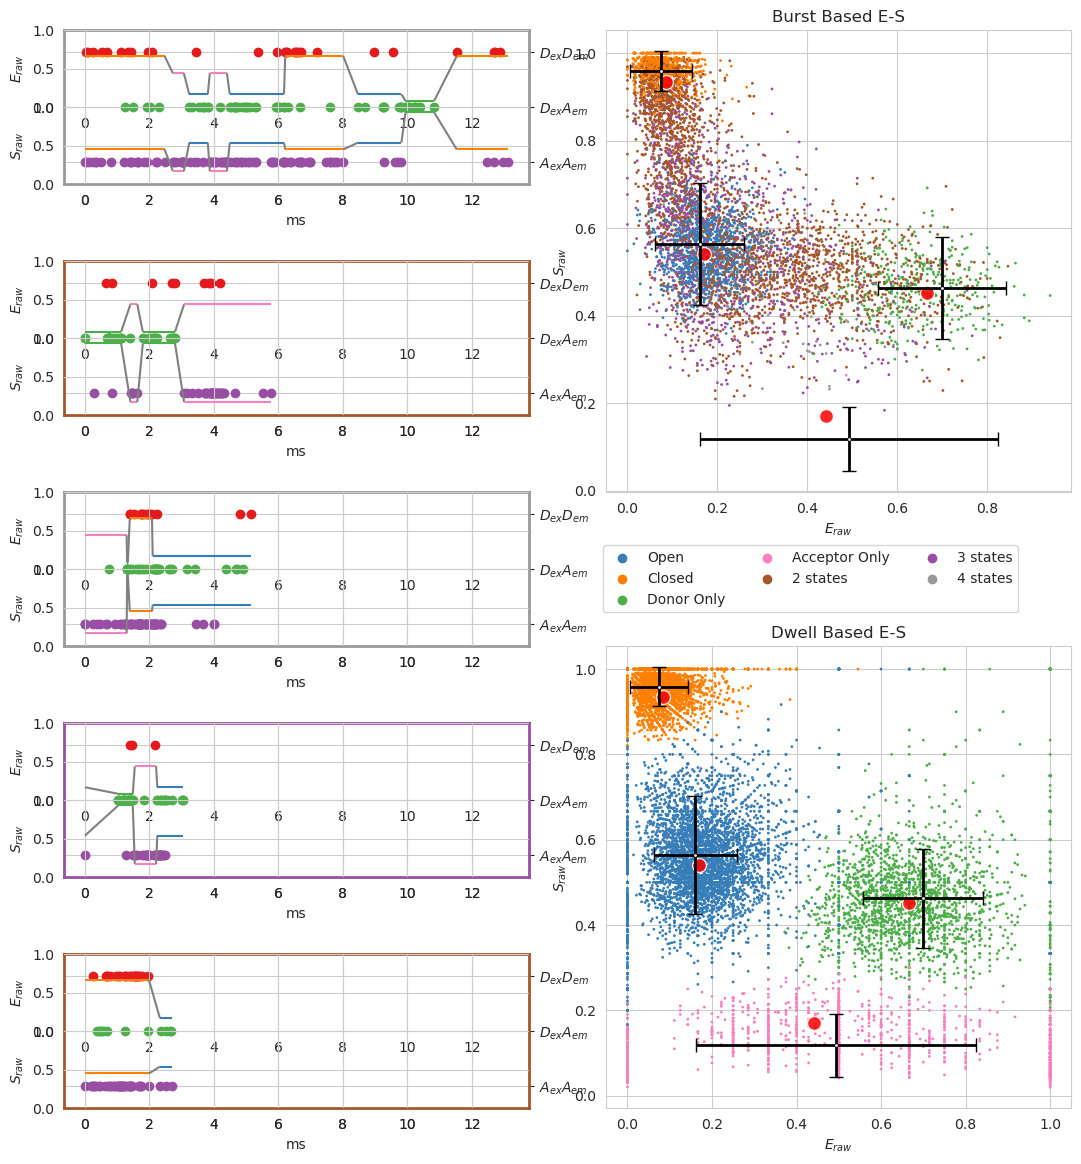

In [87]:
# data = d_da
# ph_times = ph_time_da_3
# ph_indexes = ph_index_da_3
# h_mod = h_mod_da_3[model_da_3]
# result = result_da_3[model_da_3]
# state_names = state_names_da
# bursts = [895,896,897,898,899]
# fname = filename.split('.hdf5')[0]
# fplot_sel = 'DA'
# assert len(bursts) == 5

# burst_class = []
# for i in range(h_mod.nstate):
#     burst_class.append(state_names[i])
# if h_mod.nstate > 3:
#     for i in range(2,h_mod.nstate+1):
#         burst_class.append(str(i) + ' states')
# elif h_mod.nstate == 3:
#     for i in range(h_mod.nstate-1):
#         for j in range(i+1,h_mod.nstate):
#             burst_class.append(state_names[i] + ' and ' + state_names[j])
# elif h_mod.nstate == 2:
#     burst_class.append('Dynamics')
# else:
#     burst_class.append('All states')

# trans, ES_vals = get_ES(h_mod,data.clk_p)
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(result[9])
# path = result[1]

# fig = plt.figure(figsize=(13,14))
# gs = gridspec.GridSpec(nrows=14,ncols=13,figure=fig)
# plt.subplots_adjust(hspace=0, wspace=0)
# trace = []
# for i in range(5):
#     ax1 = fig.add_subplot(gs[(3*i),0:6],sharex=trace[0][0] if i != 0 else None)
#     ax2 = fig.add_subplot(gs[(3*i+1),0:6],sharex=ax1)
#     trace.append([ax1,ax2])
# hist = [fig.add_subplot(gs[0:6,7:13]),fig.add_subplot(gs[8:14,7:13])]

# bc = []
# for bid in result[4]:
#     idstr = bin(bid)[2:]
#     cnt = idstr.count('1')
#     if cnt == 1:
#         bc.append(clr[len(idstr)-1])
#     else:
#         if h_mod.nstate > 3:
#             bc.append(clr[cnt+h_mod.nstate-2])
#         elif h_mod.nstate == 3:
#             if idstr == '11':
#                 bc.append(clr[3])
#             elif idstr == '101':
#                 bc.append(clr[4])
#             elif idstr == '110':
#                 bc.append(clr[5])
#             else:
#                 bc.append(clr[6])
#         elif h_mod.nstate == 2:
#             bc.append(clr[2])

# leg =  [Line2D([0],[0],marker='o',color=clr[i],label=b_class,markerfacecolor=clr[i],markersize=5,ls='None') 
#         for i, b_class in enumerate(burst_class)]
# hist[0].legend(handles=leg,title="",loc='lower left',bbox_to_anchor=(0.0,-0.3),fontsize=12,ncol=3)
# hist[0].scatter(data.E,data.S,c=bc,s=1)
# hist[0].set_xlim([-0.1,1.1])
# hist[0].set_ylim([-0.1,1.1])
# hist[0].text(-0.1,1.05,'f',fontsize=18,fontweight='bold',transform=hist[0].transAxes)
# hist[0].set_title("Burst based E-S",fontsize=14,fontweight='bold')
# hist[0].set_xlabel("$\mathbf{E_{raw}}$")
# hist[0].set_ylabel("$\mathbf{S_{raw}}$")

# for i, (E, S) in enumerate(zip(dwell_E,dwell_S)):
#     hist[1].scatter(E,S,c=clr[i],s=1)
# hist[1].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# hist[1].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# hist[1].set_xlim([-0.1,1.1])
# hist[1].set_ylim([-0.1,1.1])
# hist[0].text(-0.1,1.05,'g',fontsize=18,fontweight='bold',transform=hist[1].transAxes)
# hist[1].set_title("Dwell based E-S",fontsize=14,fontweight='bold')
# hist[1].set_xlabel("$\mathbf{E_{raw}}$")
# hist[1].set_ylabel("$\mathbf{S_{raw}}$")

# for i in range(len(bursts)):
#     stick_plot(ES_vals,path[bursts[i]],ph_indexes[bursts[i]],ph_times[bursts[i]],data.clk_p,clr,bc[bursts[i]],trace[i][0],trace[i][1],tick_pos='left',bar_width=0.03)
#     trace[i][0].text(-0.20,1.05,chr(ord('a')+i),fontsize=18,fontweight='bold',transform=trace[i][0].transAxes)
        
# # trace[4][1].set_xlabel('ms',fontsize=10)
# trace[0][0].set_title('Sample Burst Trajectories',fontsize=14,fontweight='bold')
# # fig.savefig('figures/'+fname+fplot_sel+'_viterbi.pdf',format='pdf',bbox_inches='tight')

bidxs = burst_nrepresentative(data, d['statepaths3'][modsel3])
# make figure and gridspec
fig = plt.figure(figsize=(13,14))
gs = fig.add_gridspec(14, 13,hspace=0.0, wspace=0.0)
# loop to plot each burst path
taxs = list()
bstates = data.get_column(d['dwells3'][modsel3]['Bstates'])
for i in range(5):
    ax0 = fig.add_subplot(gs[3*i:3*i+2,0:6], sharex=taxs[0][0] if i != 0 else None)
    ax1 = fig.add_subplot(gs[(3*i),0:6], sharex=ax0)
    ax1.patch.set_alpha(0.0)
    ax1.spines[['top','bottom','left','right']].set_visible(False)
    ax2 = fig.add_subplot(gs[(3*i+1),0:6],sharex=ax0)
    ax2.patch.set_alpha(0.0)
    ax2.spines[['top','bottom','left','right']].set_visible(False)
    smf.plot.burst_dets(data, d['bursts'].regate(gate), bidxs[i], ax=ax0, rescale=-3,
                        det_pos={smf.PhSel('0ex0em'):1.0, smf.PhSel('0ex1em'):2.0, smf.PhSel('1ex1em'):0.0}, 
                        det_kwargs={smf.PhSel('0ex0em'):{'c':'#4daf4a'}, 
                                    smf.PhSel('0ex1em'):{'c':'#e41a1c'}, 
                                    smf.PhSel('1ex1em'):{'c':'#984ea3'}}, zerostart=True)
    ax0.set_yticks([0.0, 1.0, 2.0])
    ax0.set_yticklabels(['$A_{ex}A_{em}$', '$D_{ex}A_{em}$', '$D_{ex}D_{em}$'])
    ax0.set_ylim([-0.4, 2.4])
    bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], bidxs[i], ax=ax1, slabel='$E_{raw}$', tlabel=False,
                             state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['E_raw']), rescale=-3,
                             state_kwargs=state_kwargs, color='grey', zerostart=True)
    bhm.plot.burst_statepath(data, d['statepaths3'][modsel3], bidxs[i], ax=ax2, slabel='$S_{raw}$', tlabel=False,
                             state_pos=data.get_table(d['statepaths3'][modsel3]).model_values(d['S_raw']), rescale=-3,
                             state_kwargs=state_kwargs, color='grey', zerostart=True)
    ax0.yaxis.set_ticks_position('right')
    ax0.yaxis.set_label_position('right')
    ax0.spines[['top','bottom','left','right']].set_color(bcmap(bstates[bidxs[i]]))
    ax0.spines[['top','bottom','left','right']].set_linewidth(2.0)
    taxs.append((ax0, ax1, ax2))

# plot burst based scatter
saxs = [fig.add_subplot(gs[0:6,7:13]),fig.add_subplot(gs[8:14,7:13])]
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], gate=g_da, ax=saxs[0],
                 point_func=smf.plot.colorcategory, point_cols=dbs['dwells3'][modsel3]['Bstates'], 
                 point_kwargs={'cmap':bcmap}, s=1.0)
leg = bhm.plot.state_labels_bursts(nlist, bcmap, ax=saxs[0], order=state_order)
saxs[0].set_title("Burst Based E-S")
saxs[0].legend(handles=leg, bbox_to_anchor=(0.9,-0.1), ncols=3)
# plot dwel based scatter
smf.plot.scatter(data, dbs['dwells3'][modsel3]['E_raw'], dbs['dwells3'][modsel3]['S_raw'], 
                 point_func=smf.plot.colorcategory, ax=saxs[1], point_cols=dbs['dwells3'][modsel3]['State'], 
                 point_kwargs={'cmap':ListedColormap([clr[i] for i in state_order])}, s=1.0)
saxs[1].set_title('Dwell Based E-S')
for sax in saxs:
    bhm.plot.scatter_model(d['E_bg'], d['S_bg'], d['statepaths3'][modsel3], data, ax=sax,
                       color='r',marker='o', lw=1.0, ec='white', s=100.0, alpha=0.85)
    smf.plot.errorbars(data, d['dwells3'][modsel3]['E_raw'], d['dwells3'][modsel3]['S_raw'],
                       d['dwells3'][modsel3]['State'], ax=sax, color='k', lw=0, ms=2, marker='.',
                       elinewidth=2, capsize=5, mec='white', mew=1, xlabel=False, ylabel=False)

**mpH<sup>2</sup>MM *Viterbi* analysis of DNA haripin at 300mM NaCl DCBS burst selection** 
a-e) Selected photon traces with the *Viterbi* derived most likely state paths overlayed. 
Photons are represented as verticle bars colored according to the photon stream, 
(<font color="green">green</font> for D<sub>ex</sub>D<sub>em</sub> photons, <font color="red">red</font> for D<sub>ex</sub>A<sub>em</sub> photons, 
and <font color="purple">purple</font> for A<sub>ex</sub>A<sub>em</sub> photons). 
Horizontal line represents the $E_{raw}$ (upper pannel) and $S_{raw}$ of the state predicted by the *Viterbi* algorithm. 
e,f) E-S scatter plot of bursts (f) or dwells within bursts 
(g), color coded by which states are present in the bursts 
(f) or according to the state of the dwell 
(g), according to Viterbi algorithm. Colors are consistent throughout, with states in a-e colored as in g, and the borders of the burst traces colored as in f.

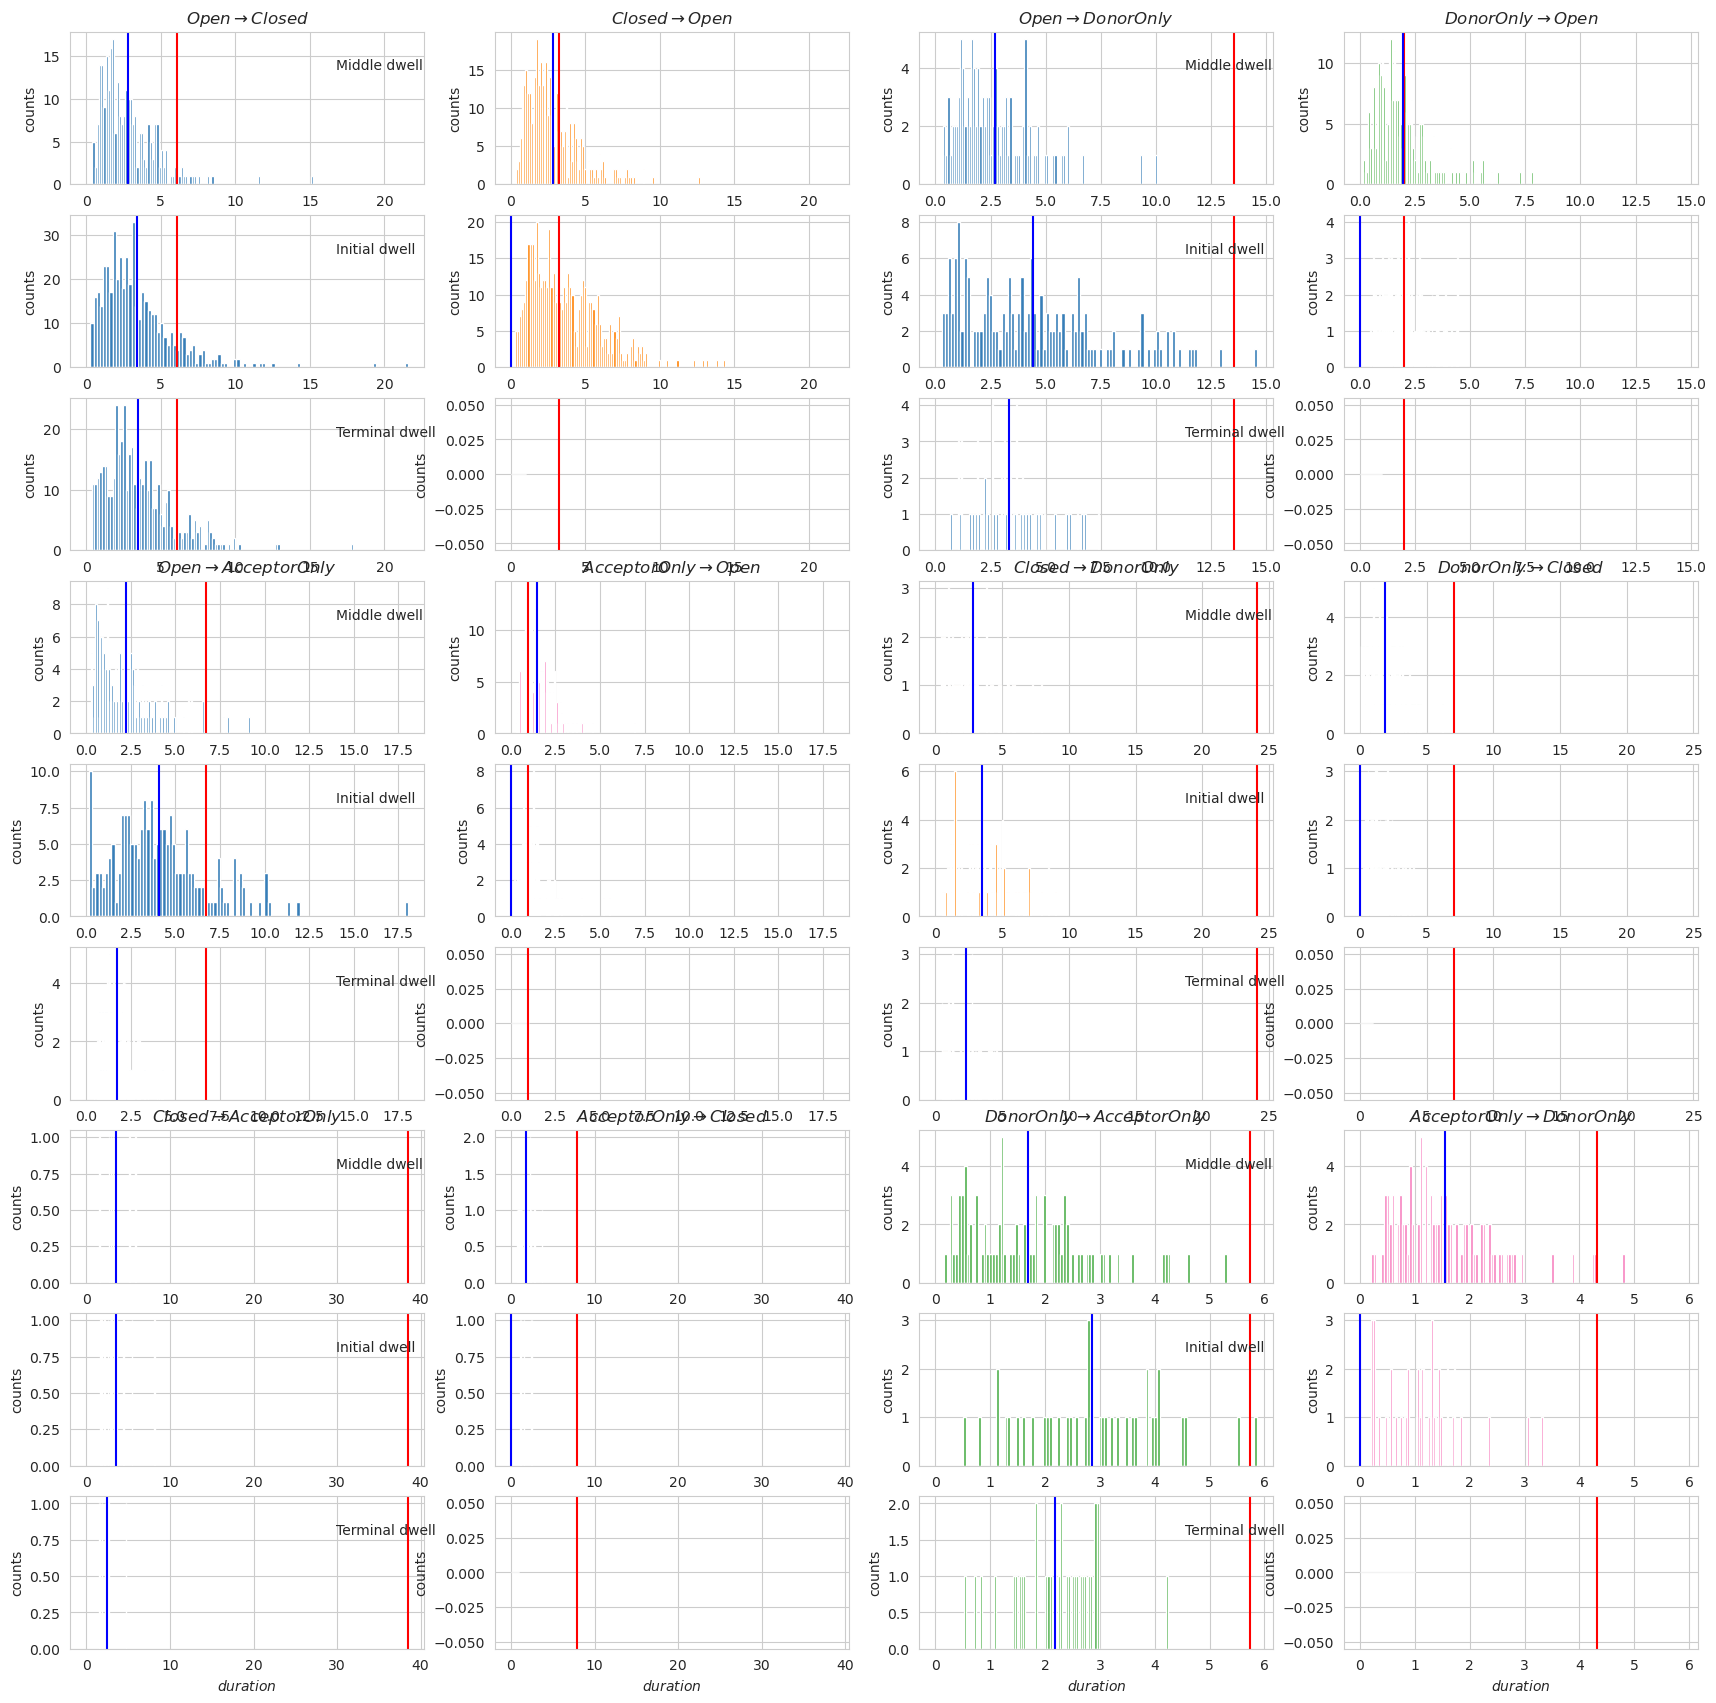

In [88]:
# # the function like inputs
# hmod = h_mod_da_3[model_da_3]
# v_result = result_da_3[model_da_3]
# clk_p = d_da.clk_p
# state_str = state_names_da
# fname = filename.split('.hdf5')[0]
# fplot_name = 'DA'

# # extract some variables
# dwell_mid = v_result[5]
# dwell_beg = v_result[6]
# dwell_end = v_result[7]
# dwell_burst = v_result[8]

# nstate = hmod.nstate
# ngraphs = nstate*(nstate-1) // 2
# nrows = ngraphs // 2 + (ngraphs % 2)
# trans, ES = get_ES(hmod,clk_p)

# fig3 = plt.figure(figsize=(21,nrows*7))
# gs3 = gridspec.GridSpec(nrows=3*nrows,ncols=4,figure=fig3)
# ax3 = [[] for i in range(ngraphs)]
# k = 0
# for i in range(nstate):
#     for j in range(i+1,nstate):
#         macro_row, macro_col = 3*(k//2), 2*(k%2)
#         ax3[k].append(fig3.add_subplot(gs3[macro_row,macro_col]))
#         ax3[k][0].hist(dwell_mid[i][j][:,0]*1000*clk_p,color=clr[i])
#         ax3[k][0].axvline(1000/trans[i,j],color='r')
#         ax3[k][0].axvline(np.mean(dwell_mid[i][j][:,0])*1000*clk_p,color='b') if dwell_mid[i][j][:,0].size != 0 else None
#         ax3[k][0].annotate('Full residence',(0.7,0.85),xycoords='axes fraction')
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+1,macro_col],sharex=ax3[k][0]))
#         ax3[k][1].hist(dwell_beg[i][j][:,0]*1000*clk_p,color=clr[i])
#         ax3[k][1].axvline(1000/trans[i,j],color='r')
#         ax3[k][1].axvline(np.mean(dwell_beg[i][j][:,0])*1000*clk_p,color='b') if dwell_beg[i][j][:,0].size != 0 else None
#         ax3[k][1].annotate('Initial Dwell',(0.7,0.85),xycoords='axes fraction')
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+2,macro_col],sharex=ax3[k][1]))
#         ax3[k][2].hist(dwell_end[i][j][:,0]*1000*clk_p,color=clr[i])
#         ax3[k][2].annotate('Ending Dwell',(0.7,0.85),xycoords='axes fraction')
#         ax3[k][2].axvline(1000/trans[i,j],color='r')
#         ax3[k][2].axvline(np.mean(dwell_end[i][j][:,0])*1000*clk_p,color='b') if dwell_end[i][j][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row,macro_col+1],sharey=ax3[k][0]))
#         ax3[k][3].hist(dwell_mid[j][i][:,0]*1000*clk_p,color=clr[j])
#         ax3[k][3].axvline(1000/trans[j,i],color='r')
#         ax3[k][3].axvline(np.mean(dwell_mid[j][i][:,0])*1000*clk_p,color='b') if dwell_mid[j][i][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+1,macro_col+1],sharey=ax3[k][1],sharex=ax3[k][3]))
#         ax3[k][4].hist(dwell_beg[j][i][:,0]*1000*clk_p,color=clr[j])
#         ax3[k][4].axvline(1000/trans[j,i],color='r')
#         ax3[k][4].axvline(np.mean(dwell_beg[j][i][:,0])*1000*clk_p,color='b') if dwell_beg[j][i][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row+2,macro_col+1],sharey=ax3[k][2],sharex=ax3[k][4]))
#         ax3[k][5].hist(dwell_end[j][i][:,0]*1000*clk_p,color=clr[j])
#         ax3[k][5].axvline(1000/trans[j,i],color='r')
#         ax3[k][5].axvline(np.mean(dwell_end[j][i][:,0])*1000*clk_p,color='b') if dwell_end[j][i][:,0].size != 0 else None
#         ax3[k].append(fig3.add_subplot(gs3[macro_row:macro_row+3,macro_col]))
#         ax3[k][6].axis('off')
#         ax3[k][6].set_title(state_str[i] + '->' + state_str[j])
#         ax3[k].append(fig3.add_subplot(gs3[macro_row:macro_row+3,macro_col+1]))
#         ax3[k][7].axis('off')
#         ax3[k][7].set_title(state_str[j] + '->' + state_str[i])
#         k += 1
# # fig3.savefig('figures/'+fname + fplot_name + '_dwellhist.pdf',format='pdf',bbox_inches='tight')

d = ddc
modsel3 = sel_dc_3

# make gates for beginning, middle and end dwells
dstate = smf.Column(d['dwells3'][modsel3]['dwells'], 'dwell_pos', ('pos',))
snext = smf.Column(d['dwells3'][modsel3]['dwells'], 'state', 1)
sprev = smf.Column(d['dwells3'][modsel3]['dwells'], 'state', -1)
gd_mid = smf.make_geq_gate(dstate, 1)
gd_beg = smf.make_isin_gate(dstate, -1)
gd_end = smf.make_isin_gate(dstate, -2)

nstate = d['statepaths3'][modsel3].params['model'].nstate
ncombs = nstate*(nstate-1) // 2
nrows = ncombs // 2 + (ncombs % 2)

nrows = (ncombs//2) + (ncombs%2)
fig3 = plt.figure(figsize=(21,nrows*7))
gs3 = fig3.add_gridspec(3*nrows, 4)
ax3 = list()
k = 0
for k, (i, j) in enumerate(combinations(state_order, 2)):
    fgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], i) & smf.make_isin_gate(snext, j)
    rgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], j) & smf.make_isin_gate(snext, i)
    pfgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], j) & smf.make_isin_gate(sprev, i)
    prgate = smf.make_isin_gate(d['dwells3'][modsel3]['State'], i) & smf.make_isin_gate(sprev, j)
    
    macro_row, macro_col = 3*(k//2), 2*(k%2)
    af0 = fig3.add_subplot(gs3[macro_row, macro_col])
    af1 = fig3.add_subplot(gs3[macro_row+1, macro_col], sharex=af0)
    af2 = fig3.add_subplot(gs3[macro_row+2, macro_col], sharex=af0)
    ar0 = fig3.add_subplot(gs3[macro_row, macro_col+1], sharex=af0)
    ar1 = fig3.add_subplot(gs3[macro_row+1, macro_col+1], sharex=af0)
    ar2 = fig3.add_subplot(gs3[macro_row+2, macro_col+1], sharex=af0)
    
    af0.set_title(rf"${state_names[i]} \rightarrow {state_names[j]}$")
    ar0.set_title(rf"${state_names[j]} \rightarrow {state_names[i]}$")
    af0.annotate('Middle dwell', (0.75,0.75), xycoords='axes fraction')
    af1.annotate('Initial dwell', (0.75,0.75), xycoords='axes fraction')
    af2.annotate('Terminal dwell', (0.75,0.75), xycoords='axes fraction')

    frate = 1e3/d['statepaths3'][modsel3].params['model'].trans[i,j]*data.clk_p
    rrate = 1e3/d['statepaths3'][modsel3].params['model'].trans[j,i]*data.clk_p
    for a in (af0, af1, af2):
        a.axvline(frate, c='r')
    for a in (ar0, ar1, ar2):
        a.axvline(rrate, c='r')
    
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_mid&fgate, ax=af0, rescale=-3, color=dcmap(i))
    if np.any(h):
        af0.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_mid&fgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_beg&fgate, ax=af1, rescale=-3, color=dcmap(i))
    if np.any(h):
        af1.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_beg&fgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_end&pfgate, ax=af2, rescale=-3, color=dcmap(i))
    if np.any(h):
        af2.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_end&pfgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_mid&rgate, ax=ar0, rescale=-3, color=dcmap(j))
    if np.any(h):
        ar0.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_mid&rgate))*1e3, c='b')
    h, _, _, _, _ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_beg&rgate, ax=ar1, rescale=-3, color=dcmap(j))
    if np.any(h):
        ar1.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_beg&rgate)), c='b')
    h, _, _ ,_ ,_ = smf.plot.hist_bar(data, d['dwells3'][modsel3]['Dur'], gate=gd_beg&prgate, ax=ar2, rescale=-3, color=dcmap(j))
    if np.any(h):
        ar2.axvline(np.nanmean(data.get_column(d['dwells3'][modsel3]['Dur'], gate=gd_end&rgate))*1e3, c='b')
    ax3.append(((af0, af1, af2), (ar0, ar1, ar2)))

**Analysis of the $t_{dwell}$ distributions of *Viterbi* based on each state, for the DCBS selection of the DNA hairpin in 300 mM NaCL.** 
Histograms are grouped in blocks fo 2 columns and 3 rows. 
Each block represents a common set of transitions, each column in the block is a different direction, i.e. one column is from *state A* to *state B*, 
and the other is *state B* to *state A*. The *top row* histograms the $t_{dwell}$ of dwells which begin and end within a burst. 
The *middle row* histograms the $t_{dwell}$ of dwells which begin at the beginning of a burst. The *bottom row* histograms teh $t_{dwell}$ of all dwells that end at the end of a burst.

<a id='dcbs_lifetime'></a>
## DCBS Assement of Quantum Yield through the Lifetime data

<s>First let's make a function that will sort the nanotimes based on state and stream, removing the nanotimes that have a posterior probability bellow a certain threshold, this will allow us to asses the lifetime, and therefore the quantum yield of the state</s>

The mean arrival time can be calculated, which allows us to calculate the lifetime.

[]

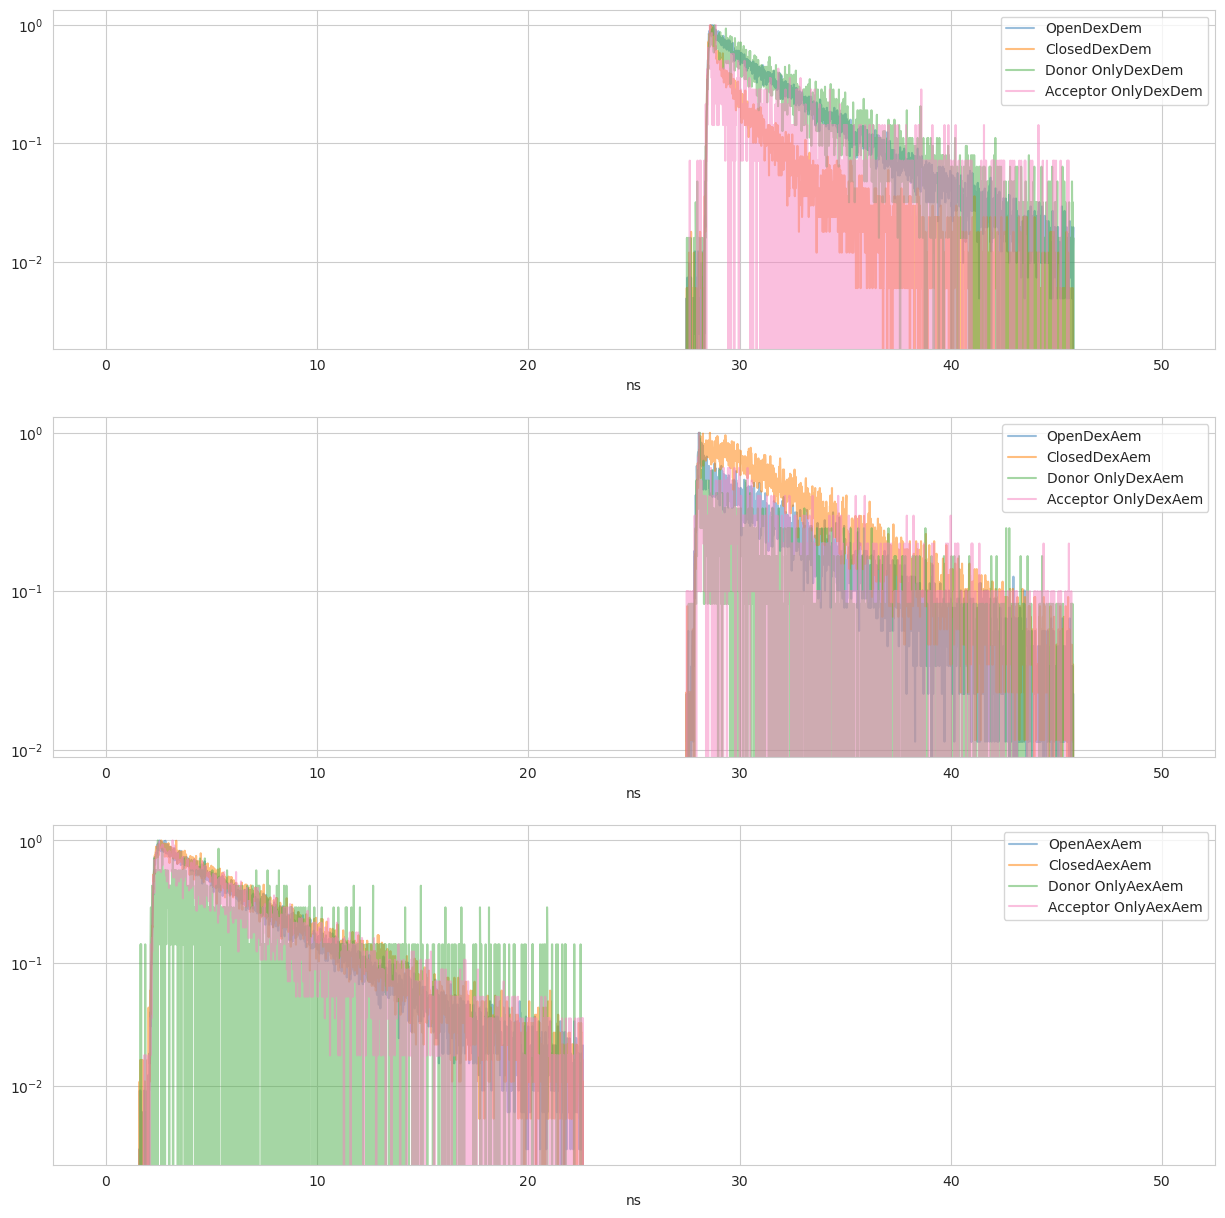

In [89]:
# state_nanotimes_corr = [[[] for j in range(len(state_nanotimes[i]))] for i in range(len(state_nanotimes))]
# state_nanotimes_mean = [[[] for j in range(len(state_nanotimes[i]))] for i in range(len(state_nanotimes))]

# fig_nt = plt.figure(figsize=(15,5*len(state_nanotimes_hist[0])))
# gs_nt = gridspec.GridSpec(ncols=1,nrows=len(state_nanotimes_hist[0]))
# ax_nt = []
# stream_str = ['DexDem','DexAem','AexAem']

# for j in range(len(state_nanotimes[0])):
#     ax_nt.append(fig_nt.add_subplot(gs_nt[j,0]))
# for i in range(len(state_nanotimes)):
#     for j in range(len(state_nanotimes[i])):
#         ax_nt[j].semilogy(time_axis_ns,state_nanotimes_hist[i][j][0]/np.max(state_nanotimes_hist[i][j][0]),alpha=0.5,label=state_names_da[i]+' '+stream_str[j])
#         state_nanotimes_corr[i][j] = state_nanotimes[i][j][state_nanotimes[i][j] > nt_th_da_3[j]/(tcspc_bin*1e9)] - nt_th_da_3[j]/(tcspc_bin*1e9)
#         state_nanotimes_mean[i][j] = np.mean(state_nanotimes_corr[i][j])
# for j in range(len(state_nanotimes[0])):
#     ax_nt[j].legend()
        
# lifetimes = np.array(state_nanotimes_mean) * tcspc_bin * 1e9
# # fig_nt.savefig('figures/'+fname+'DA_decays.pdf',format='pdf',bbox_inches='tight')
# lifetimes

fig, ax = plt.subplots(3, 1, figsize=(15, 15))

lifetimes = list()
nt_bins = np.arange(data.setup.tcspc_num_bins[0])*data.setup.tcspc_unit[0]*1e9
for i, stream in enumerate(smf.fretfactory.ALEXdefaults[('s', 'streams'),('l', 'stream_labels')][1:]):
    nh = smf.Column(d['dwells3'][modsel3]['dwells'], 'nanohist', (stream['s'], True))
    nt = smf.Column(d['dwells3'][modsel3]['dwells'], 'nanomean', stream['s'])
    lifetimes_sub = list()
    for state in state_order:
        g_temp = smf.make_isin_gate(d['dwells3'][modsel3]['State'], state)
        nhist = data.get_column(nh, gate=g_temp).sum(axis=0)
        ax[i].semilogy(nt_bins, nhist/nhist.max(), c=dcmap(state), alpha=0.5, label=state_names[state]+stream['l'])
        lifetimes_sub.append(np.nanmean(data.get_column(nt, gate=g_temp)))
    ax[i].legend()
    ax[i].set_xlabel('ns')

lifetimes

**Comparison of fluorescent lifetime decays of states derived from *Viterbi* analysis, based on DCBS burst selection.** *Top panel:* Donor decays, ($D_{ex}D_{em}$). *Middle panel:* Acceptor FRET decays ($D_{ex}A_{em}$), *Bottom panel:* ($A_{ex}A_{em}$).

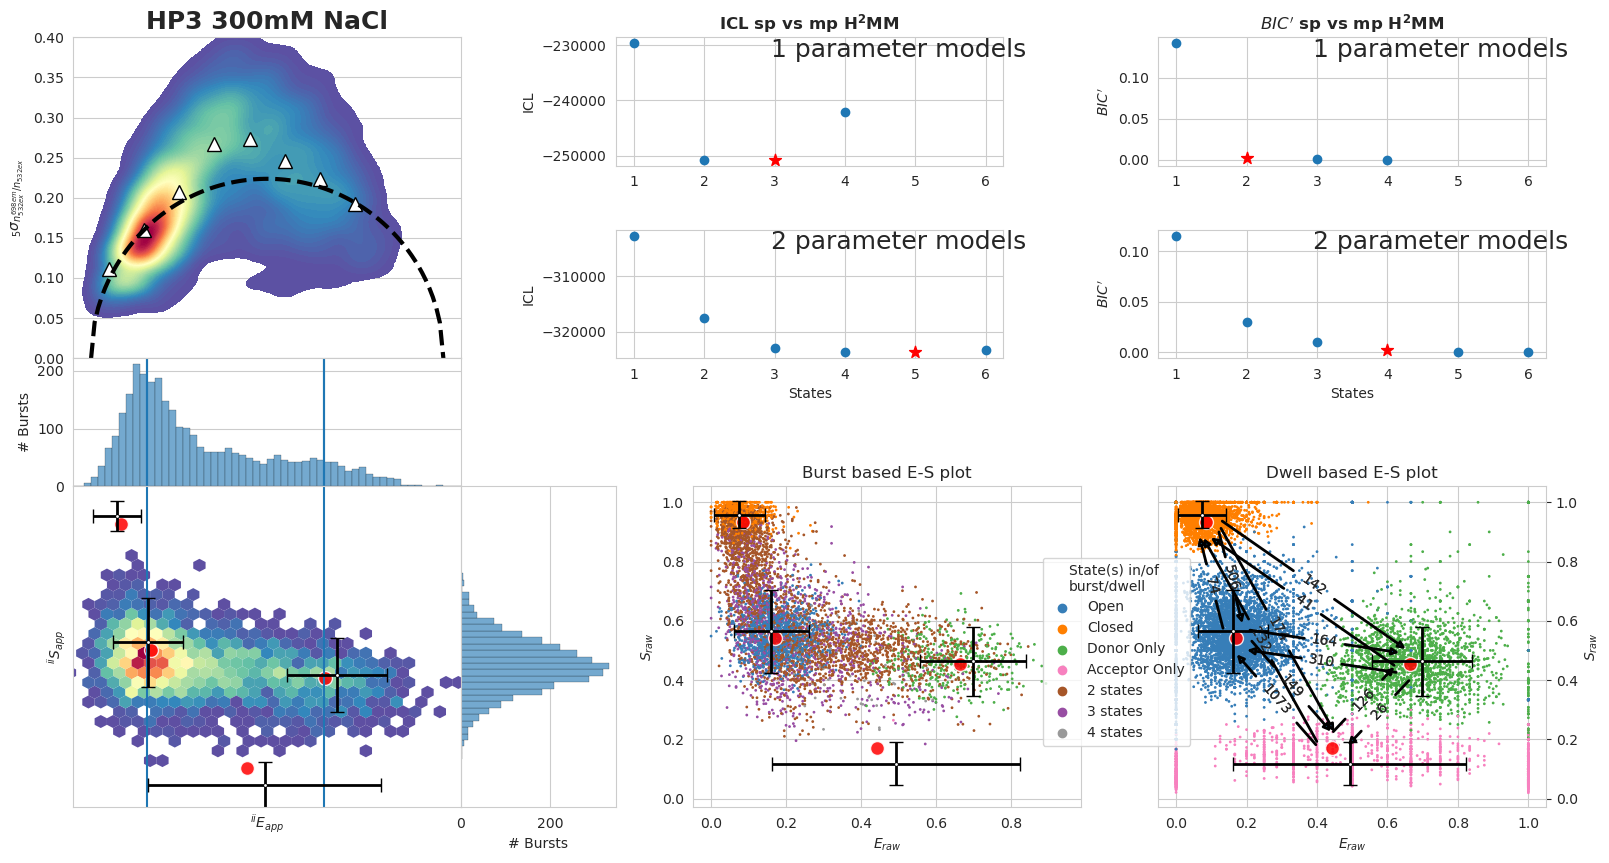

In [90]:
# # pull out the relevant variables, makes the cell act like a function
# data = d_da
# ph_times = ph_time_da_3
# ph_indexes = ph_index_da_3
# h_mod = h_mod_da_3
# h_mod2 = h_mod_da_2
# result2 = result_da_2
# result3 = result_da_3
# mod_sel = model_da_3
# mod_sel2 = model_da_2
# # Non data settings
# state_names = state_names_da
# fname = filename.split('.hdf5')[0]
# plot_sel = 'Donor Active'
# fplot_sel = 'DA'
# burst_marker_size = 5
# barwidth = 0.02
# plot_t = plot_title



# # now the automated stuff
# # build a "burst class" variable to name each type of burst by the states present
# hmod = h_mod[mod_sel]
# burst_class = []
# for i in range(hmod.nstate):
#     burst_class.append(state_names[i])
# if hmod.nstate > 3:
#     for i in range(2,hmod.nstate+1):
#         burst_class.append(str(i) + ' states')
# elif hmod.nstate == 3:
#     for i in range(hmod.nstate-1):
#         for j in range(i+1,hmod.nstate):
#             burst_class.append(state_names[i] + ' and ' + state_names[j])
# elif hmod.nstate == 2:
#     burst_class.append('Dynamics')
# else:
#     burst_class.append('All states')

# # extract some values from the given variables
# clk_p = data.clk_p
# paths = result3[mod_sel][1]
# brst_type = result3[mod_sel][4]
# ph_counts = result3[mod_sel][9]
# icl_2 = np.array([icl[0] for icl in result2])
# icl_3 = np.array([icl[0] for icl in result3])
# icl2_states = np.array([model.nstate for model in h_mod2])
# icl3_states = np.array([model.nstate for model in h_mod])
# plot_ttle = plot_t + ' ' + plot_sel

# # get needed bursts for photon stick plot
# ph_time = (ph_times[brst] - ph_times[brst][0]) * 1000 * clk_p
# ph_index = ph_indexes[brst]
# path = paths[brst]

# # Get the BVA and ES values calculated
# E_vals, std_vals, std_vals1, bn_vals = BVA(data, 5, 20, 40)
# trans, ES_vals = get_ES(hmod,clk_p)
# trasn2, ES_vals2 = get_ES(h_mod2[mod_sel2],clk_p)
# dwell_E, dwell_S, E_av, S_av, E_err, S_err, E_std, S_std = ES_error(ph_counts)

# # get the selected burst trajectory for photon stickplot
# E_path = np.zeros(path.shape,dtype=float)
# S_path = np.zeros(path.shape,dtype=float)
# EB_path = np.zeros(path.shape,dtype=float)
# SB_path = 0.5*np.ones(path.shape,dtype=float)
# ph_tm = (ph_time - ph_time[0])*clk_p*1000
# EB_color = []
# SB_color = []
# for i in range(path.size):
#     E_path[i] = ES_vals[path[i],0]
#     S_path[i] = ES_vals[path[i],1]
#     if ph_index[i] == 0:
#         EB_path[i] = -0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[2]) # change to clr[2] to make green, the more traditional color
#         SB_color.append(clr[2])
#     elif ph_index[i] == 1:
#         EB_path[i] = 0.5
#         SB_path[i] = 0.5
#         EB_color.append(clr[7]) # change to clr[7] to make red, the more traditional color
#         SB_color.append(clr[7])
#     else:
#         EB_path[i] = 0.0
#         SB_path[i] = -0.5
#         EB_color.append(clr[6])
#         SB_color.append(clr[5])

# # make burst based E and S plots
# E1 = [(index == 1).sum()/(index < 2).sum() for index in ph_indexes]
# S1 = [(index < 2).sum()/index.size for index in ph_indexes]
# # make a list of colors for the scatterplot identifying each burst by number of transitions
# bc = []
# for i in range(brst_type.size):
#     idstr = bin(brst_type[i])[2:]
#     cnt = idstr.count('1')
#     if cnt == 1:
#         bc.append(clr[len(idstr)-1])
#     else:
#         if hmod.nstate > 3:
#             bc.append(clr[cnt+hmod.nstate-2])
#         elif hmod.nstate == 3:
#             if idstr == '11':
#                 bc.append(clr[3])
#             elif idstr == '101':
#                 bc.append(clr[4])
#             elif idstr == '110':
#                 bc.append(clr[5])
#             else:
#                 bc.append(clr[6])
#         elif hmod.nstate == 2:
#             bc.append(clr[2])
        
# # set up the figures subplots
# fig1 = plt.figure(figsize=(25,15))
# gs1 = gridspec.GridSpec(nrows=12,ncols=20,figure=fig1)
# plt.subplots_adjust(hspace=0, wspace=0)
# ax1 = []
# ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
# ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[0])) # 1D FRET histogram ax1[1]
# ax1.append(fig1.add_subplot(gs1[7:12,0:5],sharex=ax1[0])) # ES hexbin plot ax1[2]
# ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[2])) # S histogram ax1[3]
# ax1.append(fig1.add_subplot(gs1[0:2,7:12])) # 1pH2MM ICL ax1[4]
# ax1.append(fig1.add_subplot(gs1[3:5,7:12],sharex=ax1[4])) # 2pH2MM ICL ax1[5]
# ax1.append(fig1.add_subplot(gs1[0:2,14:19])) # 1pH2MM BIC' ax1[6]
# ax1.append(fig1.add_subplot(gs1[3:5,14:19],sharex=ax1[6])) # 2pH2MM BIC' ax1[7]
# ax1.append(fig1.add_subplot(gs1[7:12,8:13])) # Burst based E-S viterbi calssification ax1[8]
# ax1.append(fig1.add_subplot(gs1[7:12,14:19],sharey=ax1[8])) # Dwell based E-S viterbi classification ax1[9]

# # plotting the BVA plot
# im = sns.kdeplot(x=std_vals, y=E_vals,shade=True, cmap='Spectral_r', n_levels=plot_levels, thresh=0.05, gridsize=100, ax=ax1[0])
# ax1[0].scatter(bn_vals,std_vals1,marker='^',s=140,color='white',edgecolors='k',alpha=1)
# ax1[0].set_ylim([0,0.4])
# x_T=np.arange(0,1.01,0.01)
# y_T=np.sqrt((x_T*(1-x_T))/n)
# ax1[0].plot(x_T,y_T, lw=3, color='k', ls='--')
# ax1[0].set_ylabel(r'$\mathbf{\sigma_{E}^{*}}$',fontsize=18)

# # plotting the E and S histograms that surround the ES hexbin plot
# dplot(data,hist_fret,ax=ax1[1],pdf=False, weights=None, verbose=True)
# dplot(data,hist_burst_data, data_name='S',ax=ax1[3],vertical=True)
# dplot(data, hexbin_alex, ax=ax1[2])
# ax1[2].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[2].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# for i in range(h_mod2[mod_sel2].nstate):
#     ax1[1].axvline(ES_vals2[i])
#     ax1[2].axvline(ES_vals2[i])

# # set limits and labels on first column 
# ax1[0].set_yticks(np.arange(0.1,0.5,0.1))
# ax1[1].set_ylabel('# Bursts',fontsize=18,fontweight='bold')
# ax1[2].set_xlabel(r'$\mathbf{E_{raw}}$',fontsize=18,)
# ax1[2].set_ylabel(r'$\mathbf{S_{raw}}$',fontsize=18)
# ax1[2].set_yticks([0,0.2,0.4,0.6,0.8])
# ax1[0].set_xlim([0,1])
# ax1[0].set_title(plot_ttle,fontsize=18,fontweight='bold')
# ax1[0].tick_params(labelsize=16)
# ax1[1].tick_params(labelsize=16)
# ax1[2].tick_params(labelsize=16)
# ax1[3].tick_params(labelsize=16)
# ax1[2].set_ylim([0,1])
# ax1[0].text(-0.15,1.05,'a',fontsize=18,fontweight='bold',transform=ax1[0].transAxes)
# ax1[1].set_title(' ')
# ax1[2].set_title(' ')
# ax1[2].text(-0.15,1.0,'b',fontsize=18,fontweight='bold',transform=ax1[2].transAxes)
# ax1[3].set_title(' ')
# ax1[3].set_ylabel(' ')
# ax1[3].set_xlabel('# bursts',fontsize=18,fontweight='bold')
# plt.setp(ax1[3].get_yticklabels(), visible=False)

# # ICL plots
# icl_states = np.append(icl2_states,icl3_states)
# st_min, st_max = np.min(icl_states), np.max(icl_states)
# icl_min2, icl_min3 = icl2_states[np.argmin(icl_2)], icl3_states[np.argmin(icl_3)]
# for st, ic in zip(icl2_states, icl_2):
#     c = clr[7] if st == icl_min2 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_2[mod_sel2] else dict(marker='o',s=75)
#     ax1[4].scatter(st,ic,c=c,**pltkwargs)
# for st, ic in zip(icl3_states, icl_3):
#     c = clr[7] if st == icl_min3 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if ic == icl_3[mod_sel] else dict(marker='o',s=75)
#     ax1[5].scatter(st,ic,c=c,**pltkwargs)
# ax1[4].grid(axis='x')
# ax1[4].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[4].tick_params(labelsize=16)
# ax1[4].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[4].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[4].set_title("ICL sp vs mp H$^2$MM",fontsize=18,fontweight='bold')
# ax1[4].text(-0.15,1.1,'c',fontsize=18,fontweight='bold',transform=ax1[4].transAxes)
# ax1[4].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].grid(axis='x')
# ax1[5].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[5].tick_params(labelsize=16)
# ax1[5].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[5].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[5].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[5].set_xlabel("Number of States",fontsize=18,fontweight='bold')

# # plot BIC'
# bicp2, st_2 = calc_bicp(h_mod2), np.array([mod.nstate for mod in h_mod2])
# bsel2 = st_2[np.argwhere(bicp2 < bicp_min)[0][0]]
# bicp3, st_3 = calc_bicp(h_mod), np.array([mod.nstate for mod in h_mod])
# bsel3 = st_3[np.argwhere(bicp3 < bicp_min)[0][0]]
# for st, bic in zip(st_2,bicp2):
#     c = clr[7] if st == bsel2 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if bic == bicp2[mod_sel2] else dict(marker='o',s=75)
#     ax1[6].scatter(st,bic,c=c,**pltkwargs)
# for st, bic in zip(st_3,bicp3):
#     c = clr[7] if st == bsel3 else clr[0]
#     pltkwargs = dict(marker='*',s=125) if bic == bicp3[mod_sel] else dict(marker='o',s=75)
#     ax1[7].scatter(st,bic,c=c,**pltkwargs)
# ax1[6].axhline(bicp_min,c=clr[0],ls='-',lw=1)
# ax1[7].axhline(bicp_min,c=clr[0],ls='-',lw=1)
# ax1[6].grid(axis='x')
# ax1[6].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[6].tick_params(labelsize=16)
# ax1[6].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[6].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[6].set_title("BIC' sp vs mp H$^2$MM",fontsize=18,fontweight='bold')
# ax1[6].text(-0.05,1.05,'d',fontsize=18,fontweight='bold',transform=ax1[6].transAxes)
# ax1[6].set_ylabel("BIC'",fontsize=18,fontweight='bold')
# ax1[7].grid(axis='x')
# ax1[7].set_xticks(np.arange(st_min,st_max+1,1))
# ax1[7].tick_params(labelsize=16)
# ax1[7].ticklabel_format(axis='y',style='sci',scilimits=(0,0))
# ax1[7].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
# ax1[7].set_ylabel("ICL",fontsize=18,fontweight='bold')
# ax1[7].set_xlabel("Number of States",fontsize=18,fontweight='bold')

# leg =  [Line2D([0],[0],marker='o',color=clr[i],label=b_class,markerfacecolor=clr[i],markersize=10,ls='None') 
#         for i, b_class in enumerate(burst_class)]
# ax1[8].legend(handles=leg,title='State(s) in/of \nburst/dwell',bbox_to_anchor=(1.0,1.0))
# ax1[8].scatter(E1,S1,c=bc,s=burst_marker_size)
# ax1[8].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[8].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[8].set_title('Burst Based E-S',fontsize=18,fontweight='bold')
# ax1[8].set_ylim([0,1])
# ax1[8].text(-0.15,1.05,'e',fontsize=18, fontweight='bold',transform=ax1[8].transAxes)
# ax1[8].set_xlabel(r'$\mathbf{E_{raw}}$',fontsize=18)
# ax1[8].set_ylabel(r'$\mathbf{S_{raw}}$',fontsize=18)

# for i in range(hmod.nstate):
#     ax1[9].scatter(dwell_E[i],dwell_S[i],c=clr[i],s=burst_marker_size)
# ax1[9].plot(ES_vals[:,0],ES_vals[:,1],color='r',marker='o', mew=1, mec='white',lw=0,ms=10,alpha=0.8)
# ax1[9].errorbar(E_av,S_av,xerr=E_std,yerr=S_std,color='k',lw=0,ms=2,marker='.',elinewidth=2,capsize=5,mec='white',mew=1)
# ax1[9].set_title('Dwell Based E-S',fontsize=18,fontweight='bold')
# ax1[9].text(-0.15,1.05,'f',fontsize=18, fontweight='bold',transform=ax1[9].transAxes)
# ax1[9].set_xlabel(r'$\mathbf{E_{raw}}$',fontsize=18)
# ax1[9].set_ylabel(r'$\mathbf{S_{raw}}$',fontsize=18)
# ax1[9].yaxis.set_ticks_position("right")
# ax1[9].yaxis.set_label_position("right")
# for i in range(ES_vals.shape[0]-1):
#     for j in range(i+1,ES_vals.shape[0]):
#         place_arrow(ax1[9],ES_vals[i,0],ES_vals[i,1],ES_vals[j,0],ES_vals[j,1],trans[i,j],trans[j,i])
# # fig1.savefig('figures/'+fname+fplot_sel+'_summary_type3.pdf',format='pdf',bbox_inches='tight')

d = ddc
gate = g_dcfret
modsel2 = sel_dc_2
modsel3 = sel_dc_3

state_names, state_order = name_order_states(d['statepaths3'][modsel3])
dcmap, bcmap, nlist = bhm.plot.make_bstate_cmap(state_names, clr, order=state_order)
# set up the figures subplots
fig1 = plt.figure(figsize=(20,10))
gs1 = fig1.add_gridspec(12,20, hspace=0.0, wspace=0.0)
ax1 = list()
ax1.append(fig1.add_subplot(gs1[0:5,0:5])) # BVA plot ax1[0]
ax1.append(fig1.add_subplot(gs1[5:7,0:5],sharex=ax1[0])) # 1D FRET histogram ax1[1]
ax1.append(fig1.add_subplot(gs1[7:12,0:5],sharex=ax1[0])) # ES hexbin plot ax1[2]
ax1.append(fig1.add_subplot(gs1[7:12:,5:7],sharey=ax1[2])) # S histogram ax1[3]
ax1.append(fig1.add_subplot(gs1[0:2,7:12])) # 1pH2MM ICL ax1[4]
ax1.append(fig1.add_subplot(gs1[3:5,7:12],sharex=ax1[4])) # 2pH2MM ICL ax1[5]
ax1.append(fig1.add_subplot(gs1[0:2,14:19])) # 1pH2MM BIC' ax1[6]
ax1.append(fig1.add_subplot(gs1[3:5,14:19],sharex=ax1[6])) # 2pH2MM BIC' ax1[7]
ax1.append(fig1.add_subplot(gs1[7:12,8:13])) # Burst based E-S viterbi calssification ax1[8]
ax1.append(fig1.add_subplot(gs1[7:12,14:19],sharey=ax1[8])) # Dwell based E-S viterbi classification ax1[9]


# plot BVA
ax1[0].set_title(plot_title, fontsize=18,fontweight='bold')
smf.plot.plot_meaninterval(data, d['E_raw'], d['BVA5'], gate=gate, marker='^', 
                           color='white', ms=10, mew=1, mec='k', lw=0, 
                           bins=np.linspace(0,1,11), ax=ax1[0])
smf.plot.kdeplot(data, d['E_raw'], d['BVA5'], cmap='Spectral_r', gate=gate, 
                 thresh=0.01,plot_style='contourf', levels=plot_levels, ax=ax1[0])
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_T*(1-x_T))/n)
ax1[0].plot(x_bva,y_bva, lw=3, color='k', ls='--')
ax1[0].set_ylim([0,0.4])
ax1[0].set_xlim([0, 1.0])


# plot burst ES
ax1[2].set_xticks([])
ax1[3].set_yticks([])
smf.plot.hexbin(data, d['E_bg'], d['S_bg'], gate=gate, ax=ax1[2], cmap='Spectral_r', **smf.fretfactory.ALEXdefaults['hexbin'])
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])
smf.plot.hist_bar(data, d['E_bg'], ax=ax1[1], gate=gate, xlabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
bhm.plot.hist_model(d['E_raw'], d['statepaths2'][modsel2], data, ax=ax1[2])
smf.plot.hist_bar(data, d['S_bg'], ax=ax1[3], gate=gate, orientation='horizontal', ylabel=False,
                  **smf.fretfactory.ALEXdefaults['histbar',('bins','ratio_bins')])
ax1[2].set_xlim([-0.05, 1.05])
ax1[2].set_ylim([0.05, 1.05])

# ICL plots
bhm.plot.scatter_ICL(data, d['statepaths2'], ax=ax1[4], title=False, xlabel=False)
bhm.plot.scatter_ICL(data, d['statepaths3'], ax=ax1[5], title=False)
ax1[4].set_title(r'ICL sp vs mp $\mathbf{H^{2}MM}$', fontweight='bold')
ax1[4].set_ylabel('ICL')
ax1[5].set_ylabel('ICL')
ax1[4].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
ax1[5].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)

# BIC plots
bhm.plot.scatter_BICp(data, d['statepaths2'], ax=ax1[6], title=False, xlabel=False)
bhm.plot.scatter_BICp(data, d['statepaths3'], ax=ax1[7], title=False)
ax1[6].set_title(r'$BIC^{\prime}$ sp vs mp $\mathbf{H^{2}MM}$', fontweight='bold')
ax1[6].set_ylabel(r'$BIC^{\prime}$')
ax1[7].set_ylabel(r'$BIC^{\prime}$')
ax1[6].annotate('1 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)
ax1[7].annotate('2 parameter models',(0.4,0.85),xycoords='axes fraction',fontsize=18)

# Burst based H2MM scatter plot
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], gate=g_da, ax=ax1[8], 
                 point_func=smf.plot.colorcategory, point_cols=dbs['dwells3'][modsel3]['Bstates'], 
                 point_kwargs={'cmap':bcmap}, s=1.0)
leg = bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order, ax=ax1[9])
ax1[9].legend(handles=leg, title='State(s) in/of \nburst/dwell', bbox_to_anchor=(0.1,0.8))
ax1[8].set_title("Burst based E-S plot")

# Dwell based H2MM scatterplot
smf.plot.scatter(data, dbs['dwells3'][modsel3]['E_raw'], dbs['dwells3'][modsel3]['S_raw'], 
                 point_func=smf.plot.colorcategory, ax=ax1[9], point_cols=dbs['dwells3'][modsel3]['State'], 
                 point_kwargs={'cmap':dcmap}, s=1.0)
bhm.plot.hist_model(d['E_bg'], d['statepaths2'][modsel2], data, ax=ax1[1])
ax1[9].set_title("Dwell based E-S plot")

ax1[9].yaxis.set_ticks_position('right')
ax1[9].yaxis.set_label_position('right')

# overlay model parameters over scatter plots
for i in [2, 8, 9]:
    bhm.plot.scatter_model(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data, ax=ax1[i],
                       color='r',marker='o', lw=1.0, ec='white', s=100.0, alpha=0.85)
    smf.plot.errorbars(data, d['dwells3'][modsel3]['E_raw'], d['dwells3'][modsel3]['S_raw'],
                       d['dwells3'][modsel3]['State'], ax=ax1[i], color='k', lw=0, ms=2, marker='.',
                       elinewidth=2, capsize=5, mec='white', mew=1, xlabel=False, ylabel=False)
bhm.plot.scatter_model_trans_arrows(d['E_raw'], d['S_raw'], d['statepaths3'][modsel3], data=data, 
                                    ax=ax1[9], arrowprops={'ec':'k', 'lw':2});

**mpH<sup>2</sup>MM results for DNA hairpin at 300 mM NaCl, DCBS burst selection.** a) Burst variance analysis (BVA), the standard deviation of $E_{raw}$ values of bursts is displayed versus their $E_{raw}$ values. Bursts with standard deviations higher than expected solely from shot noise (semicircle), are ones that include dynamic heterogeneity, such as within-burst FRET dynamics. Triangles indicate the average of standard deviation values per $PR$ bin. b) 2D histogram of $E_{raw}$ and $S_{raw}$ (E-S plots, colloquially) of bursts. The $E_{raw}$ and $S_{raw}$ values of sub-populations derived from mpH<sup>2</sup>MM are marked by red circles, and the standard deviation (SD) of these values, derived from the *Viterbi* dwell time analysis, are marked by black crosses. Vertical blue bars indicated $E_{raw}$ derived from spH<sup>2</sup>MM. c) Comparison of values of the integrated complete likelihood ($ICL$) of spH<sup>2</sup>MM (top panel) and mpH<sup>2</sup>MM (bottom panel) of optimized models with different numbers of states. The ideal state-model is marked in red. d) Comparison of values of the modified Bayesian Information Criterion ($BIC'$) for spH<sup>2</sup>MM (top pannel) and mpH<sup>2</sup>MM of optimized models with different numbers of states. e,f) E-S scatter plots of data processed by the *Viterbi* algorithm. mpH<sup>2</sup>MM sub-populations and *Viterbi* -derived standard deviations (SD) are overlayed as red circles and black crosses, respectively. e,f) E-S scatter plot of bursts (e) or dwells within bursts (f), color coded by which states are present in the bursts (e) or according to the state of the dwell (f), according to *Viterbi* algorithm. Numbers beside arrows indicate transition rates (in $s^{-1}$) between respective states.

<a id='savetocsv'></a>
### Writing the results to .csv file

In [91]:
# file_name = 'csv_results/' + filename.split('.hdf5')[0] + '_da_models.csv'
# h_mod2 = h_mod_da_2
# h_mod3 = h_mod_da_3
# res_2 = result_da_2
# res_3 = result_da_3
# data = d_da

# assert len(h_mod2) == len(res_2)
# assert len(h_mod3) == len(res_3)
# max_state3 = np.max([model.nstate for model in h_mod3])
# max_state2 = np.max([model.nstate for model in h_mod2])
# max_state = np.max([max_state2, max_state3])


# with open(file_name,'w') as f:
#     for mod, res in zip(h_mod2,res_2):
#         f.write("single parameter %d model,\nloglik, BIC, ICL,\n%f, %f, %f,\n" % 
#                 (mod.nstate,mod.loglik,mod.bic,res[0]))
#         data_f = ES_summary(mod,res,data)
#         data_f.to_csv(f)
#     for mod, res in zip(h_mod3,res_3):
#         f.write("mulit parameter %d model,\nloglik, BIC, ICL,\n%f, %f, %f,\n" % 
#                 (mod.nstate,mod.loglik,mod.bic,res[0]))
#         data_f = ES_summary(mod,res,data)
#         data_f.to_csv(f)


# file_name = 'csv_results/' + filename.split('.hdf5')[0] + '_fret_models.csv'
# h_mod2 = h_mod_fret_2
# h_mod3 = h_mod_fret_3
# res_2 = result_fret_2
# res_3 = result_fret_3
# data = d_da

# assert len(h_mod2) == len(res_2)
# assert len(h_mod3) == len(res_3)
# max_state3 = np.max([model.nstate for model in h_mod3])
# max_state2 = np.max([model.nstate for model in h_mod2])
# max_state = np.max([max_state2, max_state3])


# with open(file_name,'w') as f:
#     for mod, res in zip(h_mod2,res_2):
#         f.write("single parameter %d model,\nloglik, BIC, ICL,\n%f, %f, %f,\n" % 
#                 (mod.nstate,mod.loglik,mod.bic,res[0]))
#         data_f = ES_summary(mod,res,data)
#         data_f.to_csv(f)
#     for mod, res in zip(h_mod3,res_3):
#         f.write("mulit parameter %d model,\nloglik, BIC, ICL,\n%f, %f, %f,\n" % 
#                 (mod.nstate,mod.loglik,mod.bic,res[0]))
#         data_f = ES_summary(mod,res,data)
#         data_f.to_csv(f)


Let's see how long this notebook has been running:

In [92]:
plot_time = time.perf_counter()
printtime(h2mm_time,plot_time,'Plotting took: ')
printtime(begin,plot_time,'The whole analysis up to this point has taken: ')

Plotting took:  0h 2m 24.7284s to run
The whole analysis up to this point has taken:  1h 64m 23.8269s to run


<a id='E-tau'></a>
# E-$\tau$ Analysis

In [93]:
# def mean_nanotimes(indexes,nanotimes,min_cnt,time_thresh):
#     # some checks to make sure the values are valid
#     if len(indexes) != len(nanotimes):
#         raise ValueError("Mismatch in length of indexes and nanotimes arrays")
#     mx = 0
#     for idx, nano in zip(indexes,nanotimes):
#         mx_idx = np.max(idx).astype(int)
#         mx = mx_idx if mx_idx > mx else mx
#         if idx.size != nano.size:
#             raise ValueError("Different numbers of photons in index and nanotime bursts")
#     mx += 1 # add 1 so it represents the number of streams, instead of maximum value of index
#     if mx != time_thresh.size:
#         raise ValueError("Mismatch between time_thresh array and number of indexes")
#     mean_nanotimes = np.zeros((len(indexes),time_thresh.size),dtype=int)
#     valid_mean = np.zeros((len(indexes),time_thresh.size),dtype=bool)
#     for i, (idx, nano) in enumerate(zip(indexes,nanotimes)):
#         for j in range(mx):
#             mask = (idx == j) & (nano > time_thresh[j])
#             if mask.sum() >= min_cnt:
#                 valid_mean[i,j] = True
#                 mean_nanotimes[i,j] = np.mean(nano[mask]-time_thresh[j])
#             else:
#                 valid_mean[i,j] = False
#                 mean_nanotimes[i,j] = np.mean(nano[mask]-time_thresh[j]) if mask.sum() > 0 else -1
#     return mean_nanotimes, valid_mean

Sort nanotimes, and generate mean burst $\tau$ values.

#### Calculate leakage and direct excitation so E-$\tau$ plots are properly adjusted

In [94]:
# d_DO = Sel(d_all, select_bursts.S, S1=0.8)
# d_DO = Sel(d_DO, select_bursts.E, E2=0.2)
g_do = g_all & smf.make_geq_gate(dbs['S_bg'], 0.8) & smf.make_lt_gate(dbs['E_bg'], 0.2)

# d_AO = Sel(d_all, select_bursts.S, S2=0.1)
g_ao = g_all & smf.make_lt_gate(dbs['S_bg'], 0.1)

# dir_ex = np.mean(d_DO.E) / (1 - np.mean(d_DO.E))
E_do_mean = np.mean(data.get_column(dbs['E_bg'], gate=g_do))
alpha = E_do_mean / (1 - E_do_mean)
# leakage = np.mean(d_AO.S) / (1 - np.mean(d_AO.S))
S_ao_mean = np.mean(data.get_column(dbs['S_bg'], gate=g_ao))
delta = S_ao_mean / (1 - S_ao_mean)

# d.dir_ex, d_DO.dir_ex, d_AO.dir_ex, d_da.dir_ex, d_fret.dir_ex = dir_ex, dir_ex, dir_ex, dir_ex, dir_ex
# d.leakage, d_DO.leakage, d_AO.leakage, d_da.leakage, d_fret.leakage = leakage, leakage, leakage, leakage, leakage
smf.fretfactory.make_correction_factors(update=dbs, alpha=alpha, delta=delta)
smf.fretfactory.make_correction_factors(update=ddc, alpha=alpha, delta=delta);
# d_DO = Sel(d_all, select_bursts.S, S1=0.8)
# d_DO = Sel(d_DO, select_bursts.E, E2=0.2)
# d_AO = Sel(d_all, select_bursts.S, S2=0.1)

# ph_index_DO, ph_times_DO, ph_nanotime_DO = data_sort(d_DO,nchan=3)
# ph_index_AO, ph_times_AO, ph_nanotime_AO = data_sort(d_AO,nchan=3)

# nt_scale = d.nanotimes_params[0]['tcspc_unit'] * 1e9
# nt_thresh = (np.array(nt_th_da_3)/nt_scale).astype(int)

# mean_nti_DO, DO_valid = mean_nanotimes(ph_index_DO,ph_nanotime_DO,5,nt_thresh)
# mean_nti_AO, AO_valid = mean_nanotimes(ph_index_AO,ph_nanotime_AO,5,nt_thresh)
# mean_nti_da, da_valid = mean_nanotimes(ph_index_da_3,ph_nanotime_da_3,5,nt_thresh)
# mean_nti_fret, fret_valid = mean_nanotimes(ph_index_fret_3,ph_nanotime_fret_3,5,nt_thresh)

# mean_nt_DO = nt_scale * mean_nti_DO
# mean_nt_AO = nt_scale * mean_nti_AO
# mean_nt_da = nt_scale * mean_nti_da
# mean_nt_fret = nt_scale * mean_nti_fret

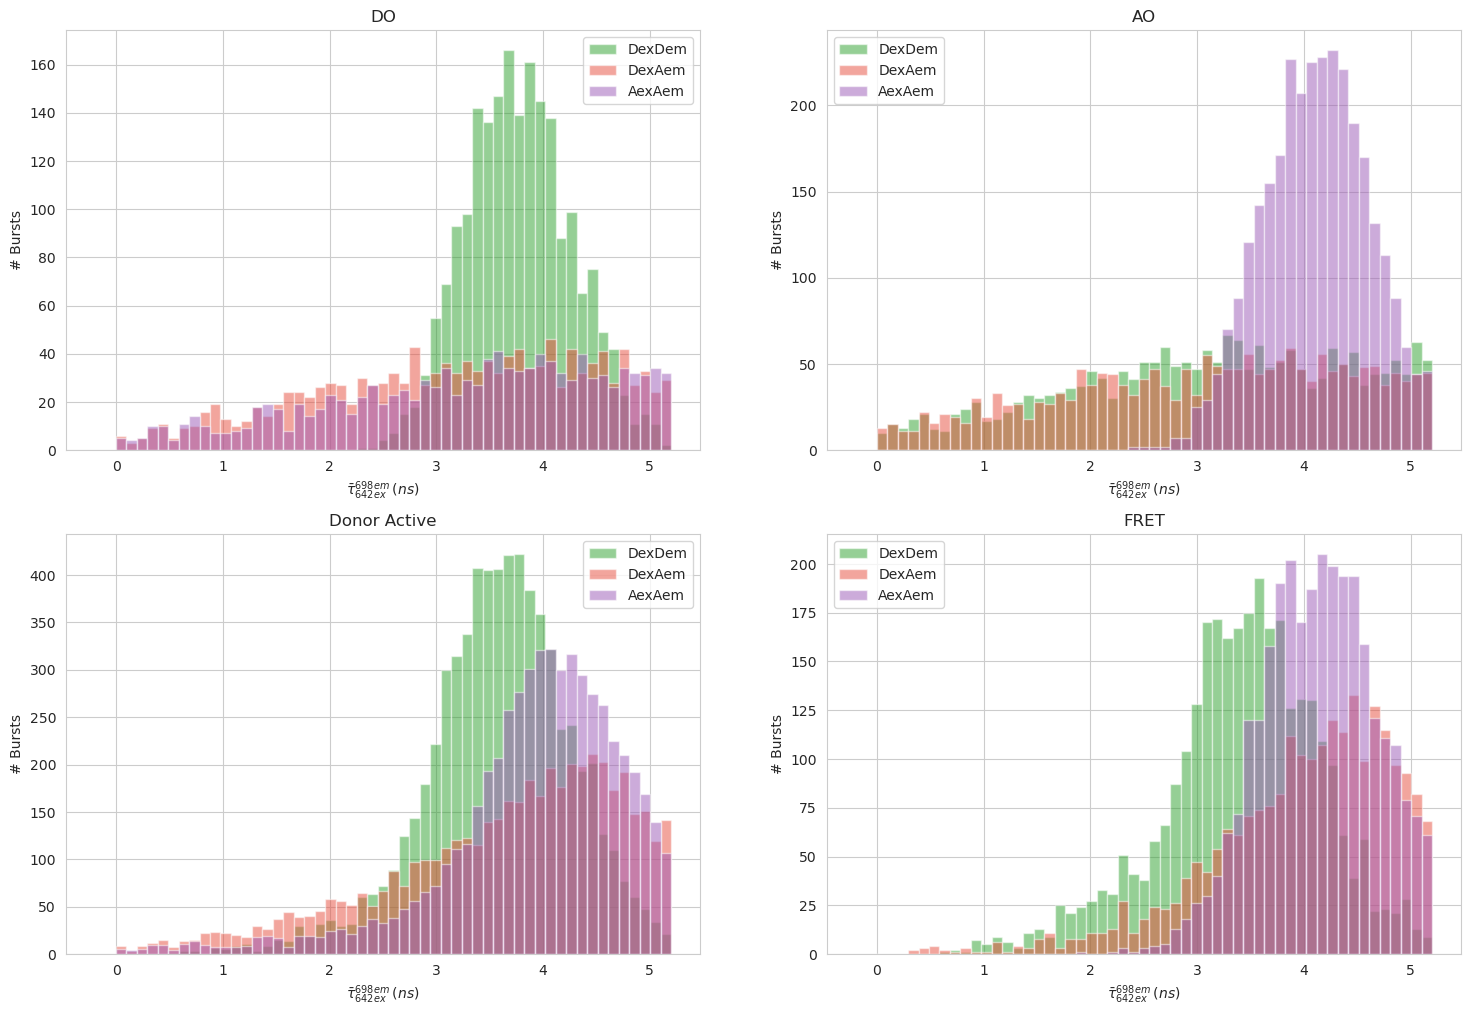

In [95]:
# lbl = ['DexDem','DexAem','AexAem']
# ttl = [["DO","AO"],["Donor Active","FRET"]]
# mean_nt = [[mean_nt_DO,mean_nt_AO],[mean_nt_da,mean_nt_fret]]
# valid_nt = [[DO_valid,AO_valid],[da_valid,fret_valid]]
# d_list = [[d_DO,d_AO],[d_da,d_fret]]
# fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(18,12))
# hist_params = {'bins':55, 'range':[-0.2,5.2], 'alpha':0.5}
# for i in range(2):
#     for j in range(2):
#         for k in range(3):
#             ax[i][j].hist(mean_nt[i][j][valid_nt[i][j][:,k],k],label=lbl[k],**hist_params)
#             ax[i][j].legend()
#             ax[i][j].set_title(ttl[i][j])
#             ax[i][j].set_xlabel("tauD")
# DO_mean_lifetime = np.mean(mean_nt_DO)

fig, ax = plt.subplots(2, 2, figsize=(18,12))
hist_params = {'bins':np.linspace(-0.2,5.2, 56), 'alpha':0.5}
for ij, (d, gate, title) in enumerate([(dbs, g_do, 'DO'), (dbs, g_ao, 'AO'),(dbs, g_da, "Donor Active"), (ddc, g_dcfret, "FRET")]):
    i, j = divmod(ij, 2)
    ax[i,j].set_title(title)
    for sdct in smf.fretfactory.ALEXdefaults['stream_colors', ('stream', 'streams'), ('label', 'stream_labels')][1:]:
        colnm = smf.Column(d['bursts'], 'nanomean', sdct['stream'])
        smf.plot.hist_bar(data, colnm, gate=gate, ax=ax[i,j], color=sdct['color'], label=sdct['label'], rescale=-9, include_unit=True, **hist_params)
    ax[i,j].legend()
donor_lifetime = np.nanmean(data.get_column(smf.Column(dbs['bursts'], 'nanomean', smf.PhSel('0ex0em')), gate=g_do))

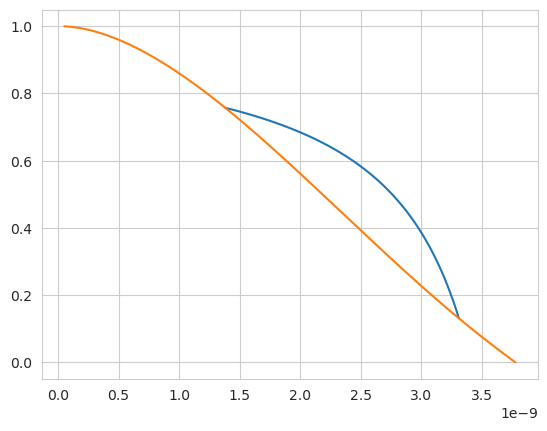

In [96]:
# Definition of normal distribution and Gaussian chain distribution
pdf_norm = lambda x, mean, sigma: np.exp(-(x-mean)**2/(2*sigma**2))/np.sqrt(2*np.pi*sigma**2)
pdf_mix = lambda x, m1, s1, m2, s2, x1: 0.5 * (x1 * pdf_norm(x, m1, s1) + (1-x1) * pdf_norm(x, m2, s1))

rda2fret = lambda rda, r0: 1./(1+(rda/r0)**6.)
rda2tau = lambda rda, tauD0, r0: (1-rda2fret(rda, r0))*tauD0
tau2taux = lambda x, tau: np.dot(x,tau) / np.sum(x)
fret2avfret = lambda x, fret: np.dot(x, fret) / np.sum(x)
tau2tauf = lambda x, tau: np.dot(x,tau**2) / tau2taux(x,tau) / np.sum(x)

# tauD0 = DO_mean_lifetime
tauD0 = donor_lifetime
r0 = 65
sigma = 10
rda = np.linspace(0, 250, 250)
fret_efficiency = rda2fret(rda, r0)
tau = rda2tau(rda, tauD0, r0)

# Calculation of a static FRET line
av_fret = list()
tau_f = list()
scan_range = np.linspace(5, 250, 500)
for m_rda in scan_range:
    x = pdf_norm(rda,m_rda, sigma)
    tau_f.append(tau2tauf(x, tau))
    av_fret.append(fret2avfret(x, fret_efficiency))
static_fret = np.array(av_fret)
static_tau = np.array(tau_f)

# Calculation of a dynamic FRET line
m1 = 52
m2 = 92
s1 = s2 = sigma
av_fret = list()
tau_f = list()
scan_range = np.linspace(0, 1, 100)
for x1 in scan_range:
    x = pdf_mix(rda, m1, s1, m2, s2, x1)
    tau_f.append(tau2tauf(x, tau))
    av_fret.append(fret2avfret(x, fret_efficiency))
dynamic_fret = np.array(av_fret)
dynamic_tau = np.array(tau_f)

plt.plot(dynamic_tau, dynamic_fret)
plt.plot(static_tau, static_fret)

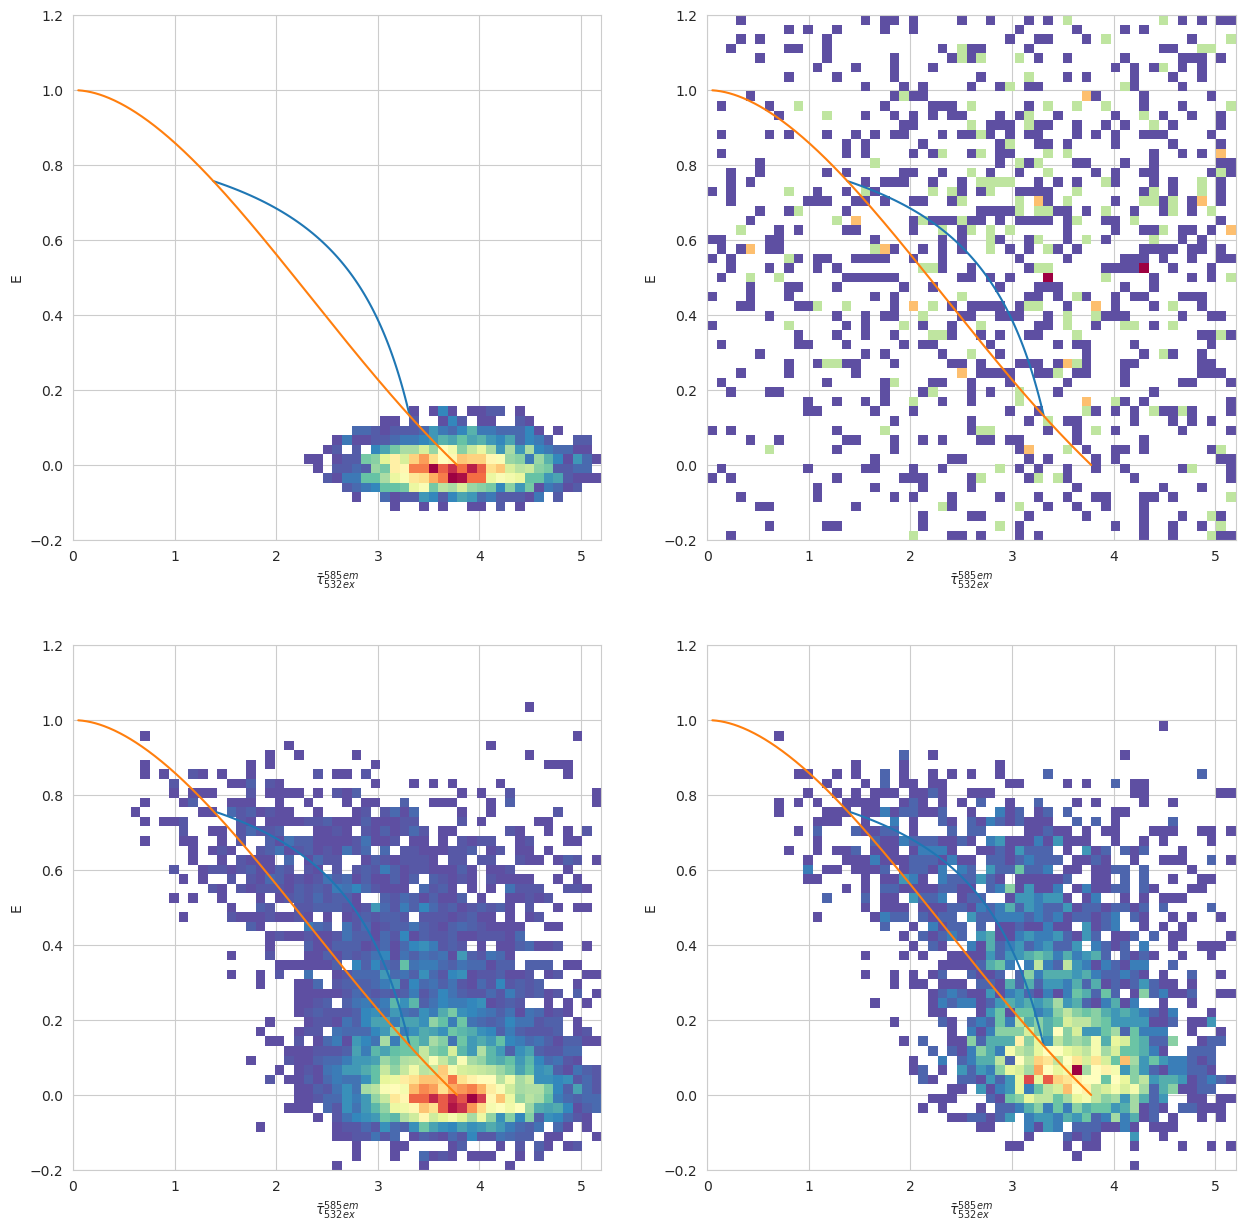

In [97]:
# hist_params = dict(bins=(55,55),range=[[0.0,5.2],[-0.2,1.2]],cmap='Spectral_r',cmin=1)

# fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(15,15))
# for i in range(2):
#     for j in range(2):
#         ax[i][j].hist2d(mean_nt[i][j][valid_nt[i][j][:,0],0],d_list[i][j].E[0][valid_nt[i][j][:,0]],**hist_params)
#         ax[i][j].plot(dynamic_tau,dynamic_fret)
#         ax[i][j].plot(static_tau,static_fret)
#         ax[i][j].set_xlabel("tauD")
#         ax[i][j].set_ylabel("E")
#         ax[i][j].set_title(ttl[i][j])

hist_params = hist_params = dict(bins=(55,55),range=[[0.0,5.2],[-0.2,1.2]],cmap='Spectral_r',cmin=1, rescale=(-9, 1))

fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(15,15))
for ij, (d, gate, title) in enumerate([(dbs, g_do, 'DO'), (dbs, g_ao, 'AO'), (dbs, g_da, "Donor Active"), (ddc, g_dcfret, "FRET")]):
    i, j = divmod(ij, 2)
    colnm = smf.Column(d['bursts'], 'nanomean', smf.PhSel('0ex0em'))
    smf.plot.hist2d(data, colnm, d['E'], gate=gate, ax=ax[i,j], **hist_params)
    ax[i][j].plot(dynamic_tau*1e9, dynamic_fret)
    ax[i][j].plot(static_tau*1e9, static_fret)

Above the $E-\tau_{D}$ plots for all burst selections are presented. The primary purpose of this is to detect any "red-flags" in the data. The top row is the donor and acceptor only populations used to calcuate correction factors. The donor only selection should be a single population centered at long $\tau_{D}$ and low $E$, while the acceptor only population should contain almost no bursts, as these bursts should only contain background D<sub>ex</sub> photons. The Donor Active and FRET selections are true tests for dynamics, however, as the Donor active selection contains donor only bursts, it is less usefull, and therefore the significant plot is the FRET selection. Bursts folowing the red line are indicative on no dynamics, while those follwoing the blue are indicative of dynamics occuring.

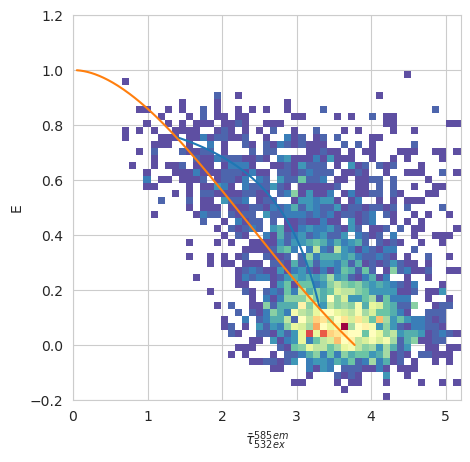

In [98]:
# fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(5,5))
# ax.hist2d(mean_nt[1][1][valid_nt[1][1][:,0],0],d_list[1][1].E[0][valid_nt[1][1][:,0]],**hist_params)
# ax.plot(dynamic_tau,dynamic_fret)
# ax.plot(static_tau,static_fret)
# ax.set_xlabel("tauD")
# ax.set_ylabel("E")
# ax.set_title("tauD vs E plot")

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(5,5))
colnm = smf.Column(ddc['bursts'], 'nanomean', smf.PhSel('0ex0em'))
smf.plot.hist2d(data, colnm, ddc['E'], gate=g_dcfret, ax=ax, **hist_params)
ax.plot(dynamic_tau*1e9, dynamic_fret)
ax.plot(static_tau*1e9, static_fret)

In [99]:
fin = time.perf_counter()
printtime(plot_time,fin,'Additional analysis (background corrections, E-tau) took: ')
printtime(begin,fin,'This notebook took:')

Additional analysis (background corrections, E-tau) took:  0h 0m 14.0124s to run
This notebook took: 1h 64m 37.8393s to run


With the features added in smfBursts that aid in reproducibility, we should:
1. get the citations
2. print the parameter descriptions

In [100]:
smf.print_citations()
print("-"*80)
print("ACBS burst selection")
print(dbs['bursts'].regate(g_da).description)
print("-"*80)
print("DCBS burst selection")
print(ddc['bursts'].regate(g_dcfret).description)

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Laurence, T. A., Kong, X., Jager, M. & Weiss, S. Probing structural
    heterogeneities and fluctuations of nucleic acids and denatured proteins.
    Proceedings of the National Academy of Sciences 102, 17348–17353 (2005).
4. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
5. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
6. Fries, J. R., Brand, L., Egg

All done!